# 11 — PRE/POST encoding-space controls: early/middle/late

This notebook tests whether route-position / encoding-time structure emerges after Island navigation, while controlling for pre-existing image differences using the PRE viewing run.

The key idea is to compare early/middle/late contrasts at POST against the same image-labelled contrasts at PRE:

$$
(\beta_{\mathrm{post,Ta}} - \beta_{\mathrm{post,Tb}})
-
(\beta_{\mathrm{pre,Ta}} - \beta_{\mathrm{pre,Tb}}).
$$

PRE acts as a within-subject image baseline. Positive effects therefore indicate route-position differences that became stronger after the Island task, rather than differences already present before encoding.

Here:

```text
early  = checkpoints 1–5
middle = checkpoints 6–10
late   = checkpoints 11–16
```

In [1]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nilearn.image import load_img
from nilearn.plotting import plot_design_matrix

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_pre_post_encoding_space_subject_events,
    build_pre_post_encoding_space_event_qc,
    make_pre_post_encoding_space_events,
)
from island_glm.contrasts import (
    make_pre_post_encoding_space_contrasts,
    contrast_specs_to_table,
)
from island_glm.first_level import run_pre_post_encoding_space_first_level_subject
from island_glm.second_level import (
    first_level_map_path,
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "pre_post_encoding_space_early_middle_late_control_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

RUN_FIRST_LEVEL = True
OVERWRITE_FIRST_LEVEL = False

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True

paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])
print("dirs keys:", sorted(dirs.keys()))

Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm
dirs keys: ['cluster_tables', 'events', 'figures', 'first_level', 'first_level_designs', 'first_level_figures', 'first_level_maps', 'interactive', 'out', 'restart', 'second_level', 'second_level_maps', 'tables', 'thresholded_maps']


## Load common inputs from Notebook 00

Notebook 00 defines the final subject list, viewing item labels, filename parsing, episode labels, checkpoint labels, and the common mean T1w anatomical background.


In [2]:
# ============================================================
# 2. Load common inputs and mean T1w background
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

assert "mean_anat" in manifest, (
    "Mean anatomical background missing from manifest. "
    "Rerun Notebook 00 after adding the mean T1w section."
)

mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
assert mean_t1w_path.exists(), f"Missing mean T1w file: {mean_t1w_path}"
mean_t1w_img = load_img(str(mean_t1w_path))

print("\nLoaded mean T1w anatomical background:")
print(mean_t1w_path)
print("Mean T1w shape:", mean_t1w_img.shape)

display(subject_table)
display(viewing_item_labels.head())

required_columns = {"subject", "phase", "onset", "duration", "old_new", "episode"}
missing_columns = required_columns.difference(viewing_item_labels.columns)
assert not missing_columns, f"Missing expected columns in viewing_item_labels: {missing_columns}"


Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}

Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Mean T1w shape: (193, 229, 193)


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early


## Design

This is a two-run PRE/POST viewing GLM.

For each subject, the PRE run is labelled according to the future Island route-position assignment of each old image. At PRE, these labels have no route/episodic meaning yet, so they provide an image-level baseline. The POST run uses the same early/middle/late labels after Island navigation.

Regressors:

```text
pre_oldEarly, pre_oldMiddle, pre_oldLate, pre_new
post_oldEarly, post_oldMiddle, post_oldLate, post_new
```

This lets us ask whether route-position differences are stronger at POST than PRE.

## Contrasts

The central contrasts are POST–PRE interactions:

$$
(\beta_{\mathrm{post,Ta}} - \beta_{\mathrm{post,Tb}})
-
(\beta_{\mathrm{pre,Ta}} - \beta_{\mathrm{pre,Tb}}).
$$

These test whether a pairwise route-position / encoding-space difference emerges after Island navigation, while controlling for pre-existing stimulus/image differences at PRE.

We also include old-new POST–PRE controls:

$$
(\beta_{\mathrm{post,Ta}} - \beta_{\mathrm{post,new}})
-
(\beta_{\mathrm{pre,Ta}} - \beta_{\mathrm{pre,new}}).
$$

In [3]:
# ============================================================
# 3. Define contrasts and save contrast table
# ============================================================

contrast_specs = make_pre_post_encoding_space_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)
print("Number of contrasts:", len(contrast_specs))

,contrast,priority,formula,interpretation,post_oldEarly,post_new,pre_oldEarly,pre_new,post_oldMiddle,pre_oldMiddle,post_oldLate,pre_oldLate
0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",Old images from the early route segment show a stronger old-new effect at POST than PRE.,1.000000,-1.0,-1.000000,1.0,0.000000,0.000000,0.000000,0.000000
1,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldMiddle}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,new}}) $$",Old images from the middle route segment show a stronger old-new effect at POST than PRE.,0.000000,-1.0,0.000000,1.0,1.000000,-1.000000,0.000000,0.000000
2,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",Old images from the late route segment show a stronger old-new effect at POST than PRE.,0.000000,-1.0,0.000000,1.0,0.000000,0.000000,1.000000,-1.000000
3,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,"$$ \frac{1}{3}(\beta_{\mathrm{post,oldEarly}}+\beta_{\mathrm{post,oldMiddle}}+\beta_{\mathrm{post,oldLate}})-\beta_{\mathrm{post,new}} - \left[\frac{1}{3}(\beta_{\mathrm{pre,ol...",Average old-new effect across early/middle/late route positions is stronger at POST than PRE.,0.333333,-1.0,-0.333333,1.0,0.333333,-0.333333,0.333333,-0.333333
4,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldMiddle}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldMiddle}}) $$","The early > middle route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",1.000000,0.0,-1.000000,0.0,-1.000000,1.000000,0.000000,0.000000
5,middle_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldMiddle}}-\beta_{\mathrm{post,oldEarly}}) - (\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldEarly}}) $$","The middle > early route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",-1.000000,0.0,1.000000,0.0,1.000000,-1.000000,0.000000,0.000000
6,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$","The early > late route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",1.000000,0.0,-1.000000,0.0,0.000000,0.000000,-1.000000,1.000000
7,late_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,oldEarly}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,oldEarly}}) $$","The late > early route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",-1.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,-1.000000
8,middle_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldMiddle}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldLate}}) $$","The middle > late route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",0.000000,0.0,0.000000,0.0,1.000000,-1.000000,-1.000000,1.000000
9,late_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,oldMiddle}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,oldMiddle}}) $$","The late > middle route-position difference is stronger at POST than PRE, controlling for pre-existing image differences.",0.000000,0.0,0.000000,0.0,-1.000000,1.000000,1.000000,-1.000000


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_contrast_definitions.csv
Number of contrasts: 22


## Event relabelling

We create clean PRE and POST event tables per subject with four BIDS-compatible columns:

```text
onset, duration, trial_type, modulation
```

Trial types are:

```text
pre_oldEarly / pre_oldMiddle / pre_oldLate / pre_new
post_oldEarly / post_oldMiddle / post_oldLate / post_new
```

The early/middle/late labels come from the checkpoint thirds prepared in Notebook 00.

In [4]:
# ============================================================
# 4. Create PRE/POST encoding-space event files and event-count QC
# ============================================================

for subject in subjects:
    save_pre_post_encoding_space_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
        phases=("pre", "post"),
    )

event_qc, all_events_long = build_pre_post_encoding_space_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
    phases=("pre", "post"),
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="	", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("Event counts by phase and trial type:")
display(event_qc.head(20))

summary_cols = [col for col in event_qc.columns if col.startswith("n_pre_") or col.startswith("n_post_")]
display(event_qc[summary_cols].describe())

Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/all_subjects_pre_post_encoding_space_early_middle_late_control_glm_events_long.tsv
Event counts by phase and trial type:


,subject,phase,n_events,events_path,n_pre_oldEarly,n_pre_oldMiddle,n_pre_oldLate,n_pre_new,n_pre_other,n_post_oldEarly,n_post_oldMiddle,n_post_oldLate,n_post_new,n_post_other
0,sub-P10,pre,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P10_pre_task-view...,90.0,90.0,108.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN
1,sub-P10,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P10_post_task-vie...,NaN,NaN,NaN,NaN,NaN,90.0,90.0,108.0,96.0,0.0
2,sub-P12,pre,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P12_pre_task-view...,90.0,90.0,108.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN
3,sub-P12,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P12_post_task-vie...,NaN,NaN,NaN,NaN,NaN,90.0,90.0,108.0,96.0,0.0
4,sub-P13,pre,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P13_pre_task-view...,90.0,90.0,108.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN
5,sub-P13,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P13_post_task-vie...,NaN,NaN,NaN,NaN,NaN,90.0,90.0,108.0,96.0,0.0
6,sub-P14,pre,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P14_pre_task-view...,90.0,90.0,108.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN
7,sub-P14,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P14_post_task-vie...,NaN,NaN,NaN,NaN,NaN,90.0,90.0,108.0,96.0,0.0
8,sub-P15,pre,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P15_pre_task-view...,90.0,90.0,108.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN
9,sub-P15,post,384,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_pre_post_encoding_space_early_middle_late_control_glm/sub-P15_post_task-vie...,NaN,NaN,NaN,NaN,NaN,90.0,90.0,108.0,96.0,0.0


,n_pre_oldEarly,n_pre_oldMiddle,n_pre_oldLate,n_pre_new,n_pre_other,n_post_oldEarly,n_post_oldMiddle,n_post_oldLate,n_post_new,n_post_other
count,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0,27.0
mean,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0
25%,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0
50%,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0
75%,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0
max,90.0,90.0,108.0,96.0,0.0,90.0,90.0,108.0,96.0,0.0


## Single-subject design preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This cell does **not** save first-level contrast maps.


In [11]:
# ============================================================
# 5. Single-subject design and contrast preview
# ============================================================

subject_qc_preview, contrast_qc_preview = run_pre_post_encoding_space_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=True,
)

preview_subject_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
)
preview_contrast_qc_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"
)

subject_qc_preview.to_csv(preview_subject_qc_path, index=False)
contrast_qc_preview.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(subject_qc_preview)

print("Contrast-vector preview:")
display(contrast_qc_preview)

assert not contrast_qc_preview.groupby("contrast")["is_null_vector"].all().any()

print("Saved preview QC:")
print(preview_subject_qc_path)
print(preview_contrast_qc_path)

[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 1 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 1 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 0 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 0 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")


Subject QC preview:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P15,1.3,1986,1995,384,384,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,65,65,True,True,False,70,70,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...


Contrast-vector preview:


,subject,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,sub-P15,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,1,70,2,pre_new;pre_oldEarly,1.0;-1.0,post_oldEarly;post_new,False
1,sub-P15,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,2,70,2,post_new;post_oldEarly,-1.0;1.0,pre_oldEarly;pre_new,False
2,sub-P15,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,1,70,2,pre_new;pre_oldMiddle,1.0;-1.0,post_oldMiddle;post_new,False
3,sub-P15,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,2,70,2,post_new;post_oldMiddle,-1.0;1.0,pre_oldMiddle;pre_new,False
4,sub-P15,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,1,70,2,pre_new;pre_oldLate,1.0;-1.0,post_oldLate;post_new,False
5,sub-P15,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,2,70,2,post_new;post_oldLate,-1.0;1.0,pre_oldLate;pre_new,False
6,sub-P15,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,1,70,4,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,1.0;-0.3333333333333333;-0.3333333333333333;-0.3333333333333333,post_oldEarly;post_oldMiddle;post_oldLate;post_new,False
7,sub-P15,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,2,70,4,post_new;post_oldEarly;post_oldLate;post_oldMiddle,-1.0;0.3333333333333333;0.3333333333333333;0.3333333333333333,pre_oldEarly;pre_oldMiddle;pre_oldLate;pre_new,False
8,sub-P15,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,1,70,2,pre_oldEarly;pre_oldMiddle,-1.0;1.0,post_oldEarly;post_oldMiddle,False
9,sub-P15,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,2,70,2,post_oldEarly;post_oldMiddle,1.0;-1.0,pre_oldEarly;pre_oldMiddle,False


Saved preview QC:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_sub-P15_design_preview_subject_qc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_sub-P15_contrast_vector_preview_qc.csv


## Restart-safe first-level GLM

The first-level GLM is the slow part. This notebook is configured so that:

- `RUN_FIRST_LEVEL=True` fits first-level models and saves maps immediately;
- `RUN_FIRST_LEVEL=False` loads/verifies existing maps;
- `OVERWRITE_FIRST_LEVEL=False` runs only missing or incomplete subjects.

After a successful first run, keep `RUN_FIRST_LEVEL=False`.


In [5]:
# ============================================================
# 6. Run, recover, or load first-level GLM results
# ============================================================

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"


def safe_read_csv(path, empty_columns=None):
    empty_columns = empty_columns or []
    if not Path(path).exists():
        return pd.DataFrame(columns=empty_columns)
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        print(f"Warning: empty CSV detected, replacing with empty table: {path}")
        return pd.DataFrame(columns=empty_columns)


def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
        effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


def recover_first_level_qc_from_saved_maps(subjects, contrast_specs, dirs, smoothing_label):
    recovered_qc_rows = []
    recovered_contrast_rows = []

    for subject in subjects:
        subject_all_maps_exist = True
        for contrast_name in contrast_specs.keys():
            z_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="z")
            effect_path = first_level_map_path(dirs, subject, contrast_name, smoothing_label, map_type="effect")

            z_exists = z_path.exists()
            effect_exists = effect_path.exists()
            if not z_exists or not effect_exists:
                subject_all_maps_exist = False

            recovered_contrast_rows.append({
                "subject": subject,
                "contrast": contrast_name,
                "z_map_path": str(z_path),
                "effect_map_path": str(effect_path),
                "z_map_exists": z_exists,
                "effect_map_exists": effect_exists,
                "recovered_from_saved_maps": True,
            })

        recovered_qc_rows.append({
            "subject": subject,
            "all_expected_first_level_maps_exist": subject_all_maps_exist,
            "recovered_from_saved_maps": True,
        })

    first_level_qc = pd.DataFrame(recovered_qc_rows)
    first_level_contrast_qc = pd.DataFrame(recovered_contrast_rows)

    failed_subjects = first_level_qc.loc[
        ~first_level_qc["all_expected_first_level_maps_exist"],
        ["subject"],
    ].copy()

    if len(failed_subjects) > 0:
        failed_subjects["error_type"] = "MissingFirstLevelMaps"
        failed_subjects["error_message"] = "At least one expected first-level z/effect map is missing."
    else:
        failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])

    return first_level_qc, first_level_contrast_qc, failed_subjects


existing_subjects = [
    subject
    for subject in subjects
    if subject_has_all_first_level_maps(subject, contrast_specs, dirs, SMOOTHING_LABEL)
]
missing_subjects = [subject for subject in subjects if subject not in existing_subjects]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))
if missing_subjects:
    print("Missing/incomplete:", missing_subjects)

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("OVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("OVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running PRE/POST encoding-space-control first-level GLM:", subject)
        try:
            subject_qc, contrast_qc = run_pre_post_encoding_space_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )
            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)
            print("Finished:", subject)
        except Exception as exc:
            failed_rows.append({
                "subject": subject,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = pd.concat(first_level_qc_rows, ignore_index=True) if first_level_qc_rows else pd.DataFrame()
    new_first_level_contrast_qc = pd.concat(first_level_contrast_qc_rows, ignore_index=True) if first_level_contrast_qc_rows else pd.DataFrame()
    failed_subjects = pd.DataFrame(failed_rows, columns=["subject", "error_type", "error_message"])

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = safe_read_csv(first_level_qc_path)
        first_level_qc = pd.concat([old_first_level_qc, new_first_level_qc], ignore_index=True)
        if "subject" in first_level_qc.columns:
            first_level_qc = first_level_qc.drop_duplicates(subset=["subject"], keep="last")
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = safe_read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat([old_first_level_contrast_qc, new_first_level_contrast_qc], ignore_index=True)
        dedup_cols = [col for col in ["subject", "contrast", "run"] if col in first_level_contrast_qc.columns]
        if dedup_cols:
            first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(subset=dedup_cols, keep="last")
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)

else:
    print("RUN_FIRST_LEVEL=False, loading or recovering existing first-level outputs.")
    if first_level_qc_path.exists() and first_level_contrast_qc_path.exists():
        first_level_qc = safe_read_csv(first_level_qc_path)
        first_level_contrast_qc = safe_read_csv(first_level_contrast_qc_path)
        failed_subjects = safe_read_csv(
            failed_subjects_path,
            empty_columns=["subject", "error_type", "error_message"],
        )
        if len(failed_subjects) == 0:
            failed_subjects = pd.DataFrame(columns=["subject", "error_type", "error_message"])
            failed_subjects.to_csv(failed_subjects_path, index=False)
    else:
        print("QC tables missing; recovering from saved first-level maps.")
        first_level_qc, first_level_contrast_qc, failed_subjects = recover_first_level_qc_from_saved_maps(
            subjects, contrast_specs, dirs, SMOOTHING_LABEL
        )
        first_level_qc.to_csv(first_level_qc_path, index=False)
        first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
        failed_subjects.to_csv(failed_subjects_path, index=False)

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
assert (map_qc["n_z_maps"] == len(subjects)).all(), (
    "Some first-level z-maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)
assert (map_qc["n_effect_maps"] == len(subjects)).all(), (
    "Some first-level effect maps are missing. Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False."
)

print("First-level ready.")
print("Failed subjects:", len(failed_subjects))
display(first_level_qc)
display(failed_subjects)
assert len(failed_subjects) == 0, "Some subjects failed. Inspect failed_subjects."

Existing complete first-level subjects: 27
Missing/incomplete first-level subjects: 0
OVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
1,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
2,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
3,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,27,27,27
4,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
5,middle_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
6,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
7,late_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
8,middle_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
9,late_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27


First-level ready.
Failed subjects: 0


,subject,all_expected_first_level_maps_exist,recovered_from_saved_maps,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P10,NaN,NaN,1.3,2026.0,1994.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,66.0,65.0,True,True,False,71.0,70.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
1,sub-P12,NaN,NaN,1.3,1996.0,1954.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,65.0,64.0,True,True,False,70.0,69.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
2,sub-P13,NaN,NaN,1.3,1952.0,1957.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,64.0,64.0,True,True,False,69.0,69.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
3,sub-P14,NaN,NaN,1.3,1967.0,1922.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,64.0,64.0,True,True,False,69.0,69.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
4,sub-P15,NaN,NaN,1.3,1986.0,1995.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,65.0,65.0,True,True,False,70.0,70.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
5,sub-P16,NaN,NaN,1.3,2024.0,1955.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,66.0,64.0,True,True,False,71.0,69.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;post_oldEarly;post_oldLate;post_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13...
6,sub-P17,NaN,NaN,1.3,1906.0,1946.0,384.0,384.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle,post_new;post_oldEarly;post_oldLate;post_oldMiddle,63.0,64.0,True,True,False,68.0,69.0,pre_new;pre_oldEarly;pre_oldLate;pre_oldMiddle;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine11;cosine12;cosine13;cos...,post_new;p

,subject,error_type,error_message


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.


In [6]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
1,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
2,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,27,27,27
3,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,27,27,27
4,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
5,middle_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
6,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
7,late_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
8,middle_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27
9,late_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero.


In [7]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")
        second_level_table = pd.read_csv(second_level_table_path)
    else:
        print("Running second-level GLM.")
        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )
        second_level_table.to_csv(second_level_table_path, index=False)
else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")
    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )
    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()


Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
1,middle_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldMiddle}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
2,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
3,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,"$$ \frac{1}{3}(\beta_{\mathrm{post,oldEarly}}+\beta_{\mathrm{post,oldMiddle}}+\beta_{\mathrm{post,oldLate}})-\beta_{\mathrm{post,new}} - \left[\frac{1}{3}(\beta_{\mathrm{pre,ol...",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
4,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldMiddle}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldMiddle}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
5,middle_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldMiddle}}-\beta_{\mathrm{post,oldEarly}}) - (\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldEarly}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,True,True
6,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,

Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save corrected threshold summaries and exploratory cluster tables. Visualizations use exploratory thresholds unless corrected maps survive FDR/Bonferroni.


In [8]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary.sort_values(["contrast", "threshold_label"]))

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.5338568687438965. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.5338568687438965. But, you have given threshold=inf.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: UserWarning: The given float value must not exceed 4.5338568687438965. But, you have given threshold=4.943085175231748.


Threshold summary:


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:133: UserWarning: No clusters found with stat higher than 3.0
  table = get_clusters_table(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:231: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_tables, ignore_index=True)


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
27,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,1,5.108189,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
25,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$",fdr_q05_one_sided,fdr,0.050,False,5.108189,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
26,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$",fdr_q10_one_sided,fdr,0.100,False,5.108189,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
24,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldLate}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldLate}}) $$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,102,5.108189,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
19,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,oldMiddle}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,oldMiddle}}) $$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
...,...,...,...,...,...,...,...,...,...,...,...
44,pre_middle_gt_early,11_descriptive_pre_encoding_time_pairwise,"$$\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldEarly}}$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,161,3.968380,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
59,pre_middle_gt_late,11_descriptive_pre_encoding_time_pairwise,"$$\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldLate}}$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
57,pre_middle_gt_late,11_descriptive_pre_encoding_time_pairwise,"$$\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldLate}}$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...
58,pre_middle_gt_late,11_descriptive_pre_encoding_time_pairwise,"$$\beta_{\mathrm{pre,oldMiddle}}-\beta_{\mathrm{pre,oldLate}}$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/thresho...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
12,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_2.33,2.33,10,18,5.108189,1406.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
13,early_gt_late_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_3.00,3.00,10,2,5.108189,234.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
8,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_2.33,2.33,10,16,3.750186,921.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
9,early_gt_middle_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_3.00,3.00,10,1,3.750186,171.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,z_gt_2.33,2.33,10,15,4.533857,390.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
1,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,z_gt_3.00,3.00,10,0,NaN,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
6,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,z_gt_2.33,2.33,10,18,3.853590,750.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
7,encoding_time_old_gt_new_post_gt_pre,11_encoding_time_average_old_new_post_pre_control,z_gt_3.00,3.00,10,2,3.853590,250.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
14,late_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_2.33,2.33,10,21,4.053662,562.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...
15,late_gt_early_post_gt_pre,11_encoding_time_pairwise_post_pre_control,z_gt_3.00,3.00,10,2,4.053662,187.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/cluster...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_cluster_details_smoothed5mm.csv


## Atlas labels for exploratory peaks

The cluster table is labelled with Harvard-Oxford. These labels are useful for reporting, but exact anatomy should still be checked visually.


In [9]:
# ============================================================
# 10. Label cluster table with Harvard-Oxford atlas
# ============================================================

cluster_details_labeled = label_cluster_table(cluster_details)
cluster_details_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_labeled_{SMOOTHING_LABEL}.csv"
cluster_details_labeled.to_csv(cluster_details_labeled_path, index=False)

display(cluster_details_labeled.head(80))
print("Saved:", cluster_details_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,-8.5,3.0,-10.5,4.533857,156.0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Left Cerebral Cortex,2
1,2,41.5,-7.0,-20.5,4.215716,203.0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
2,3,21.5,5.5,37.0,3.580748,171.0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
3,4,4.0,-12.0,-18.0,3.564852,312.0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Background,0
4,5,-28.5,-24.5,32.0,3.482060,187.0,early_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldEarly}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldEarly}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,21,-11.0,-27.0,-35.5,3.062855,281.0,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Brain-Stem,8
76,22,49.0,-54.5,52.0,3.022217,515.0,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Angular Gyrus,21,Right Cerebral Cortex,13
77,22a,49.0,-62.0,47.0,2.832884,NaN,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,"Lateral Occipital Cortex, superior division",22,Right Cerebral Cortex,13
78,23,-6.0,-62.0,-33.0,2.857726,218.0,late_gt_new_post_gt_pre,11_encoding_time_old_new_post_pre_control,"$$ (\beta_{\mathrm{post,oldLate}}-\beta_{\mathrm{post,new}}) - (\beta_{\mathrm{pre,oldLate}}-\beta_{\mathrm{pre,new}}) $$",z_gt_2.33,2.33,10,Background,0,Background,0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_cluster_details_labeled_smoothed5mm.csv


## Plot PRE/POST encoding-space-control contrasts on the common mean T1w background

Skipping missing contrast: encoding_space_old_gt_new_post_gt_pre


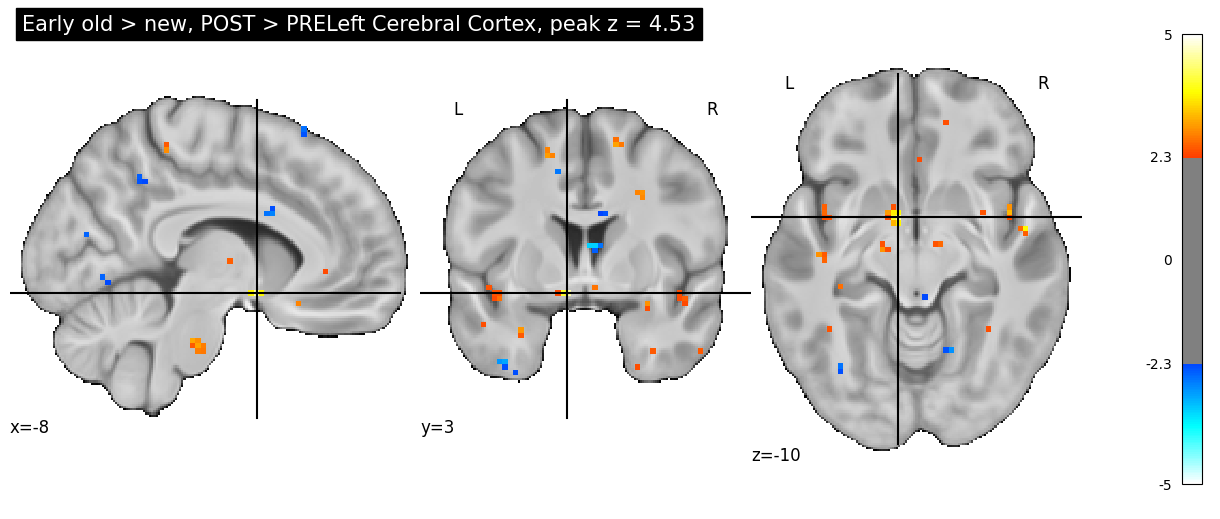

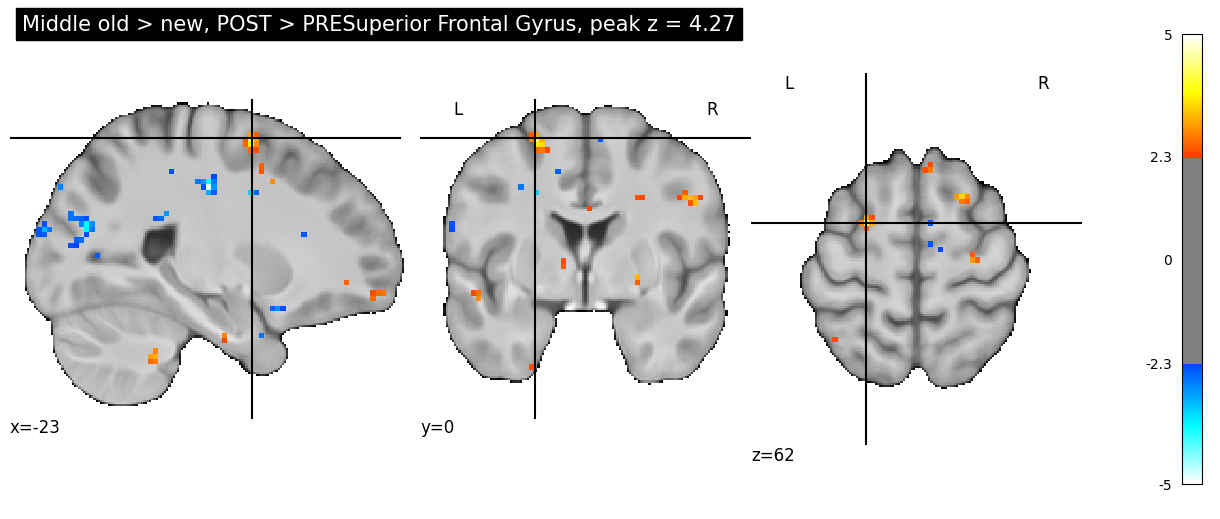

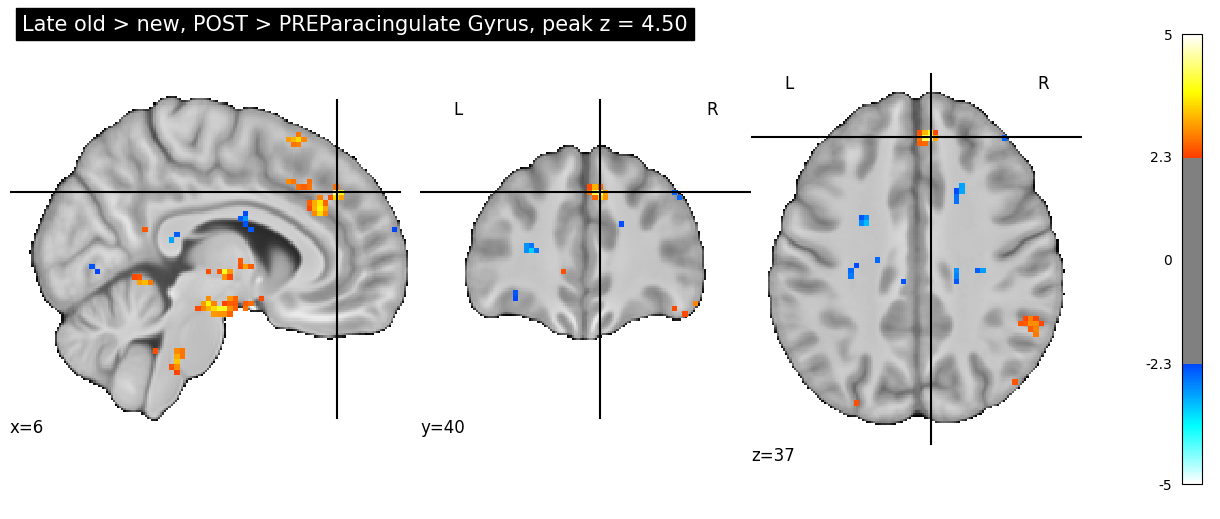

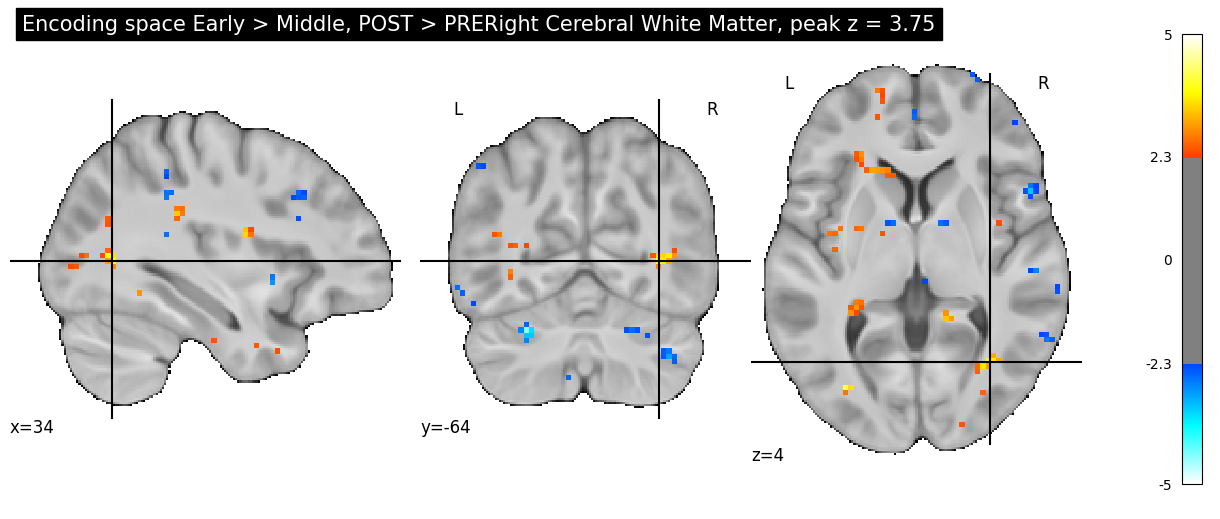

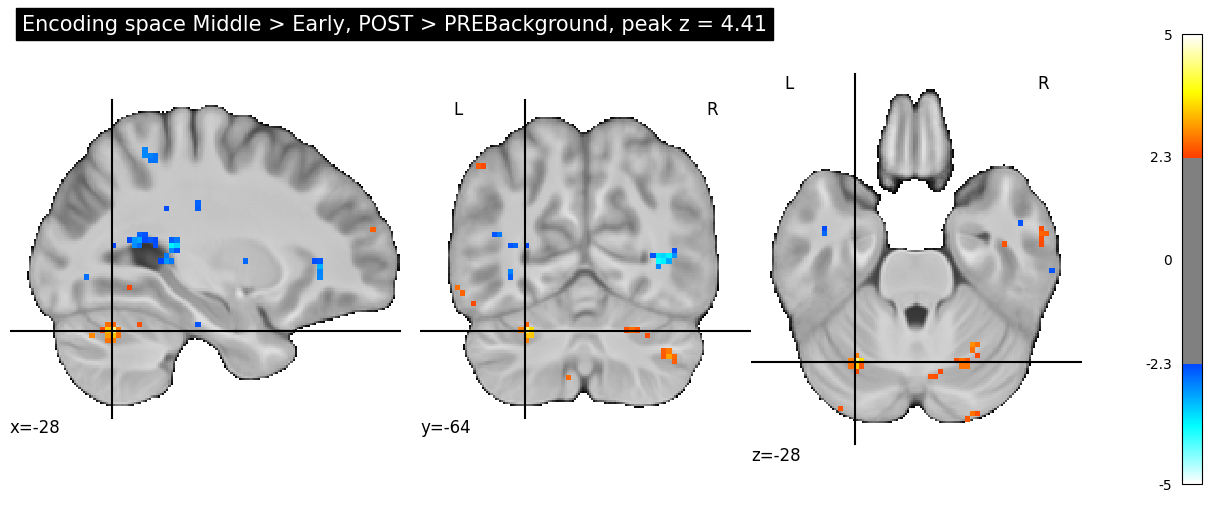

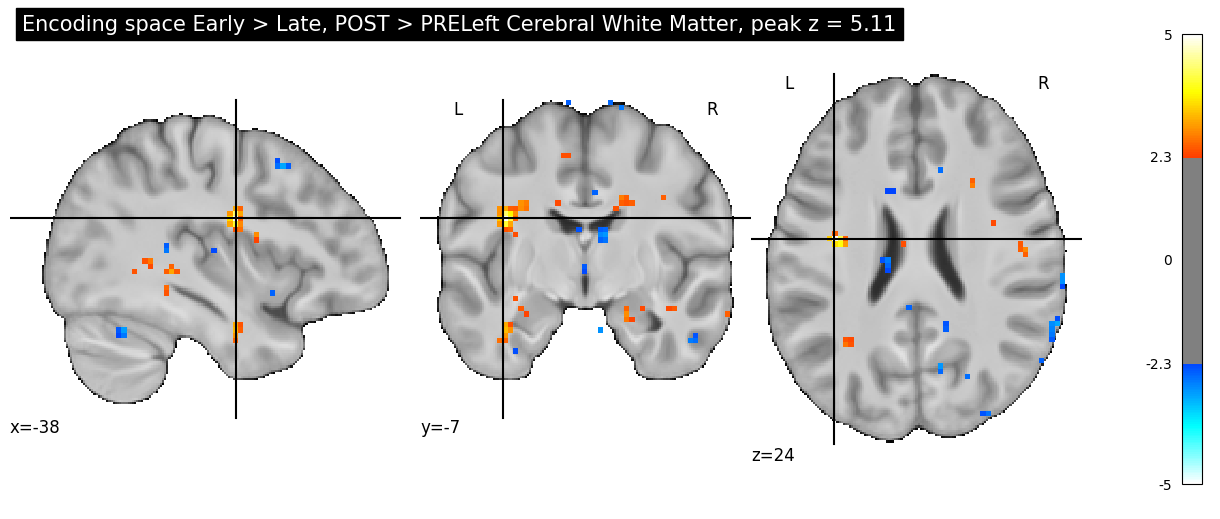

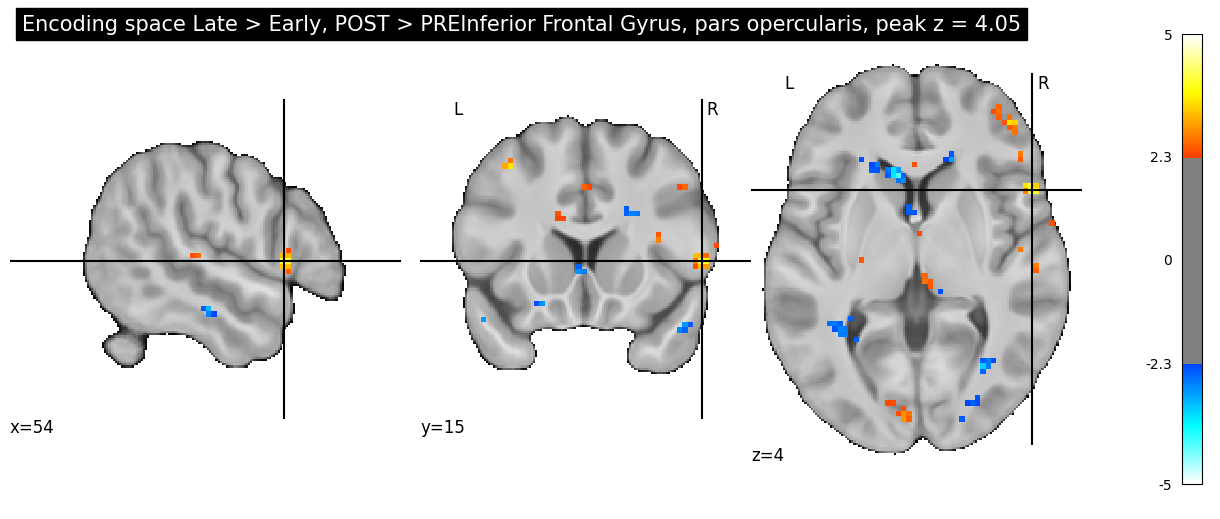

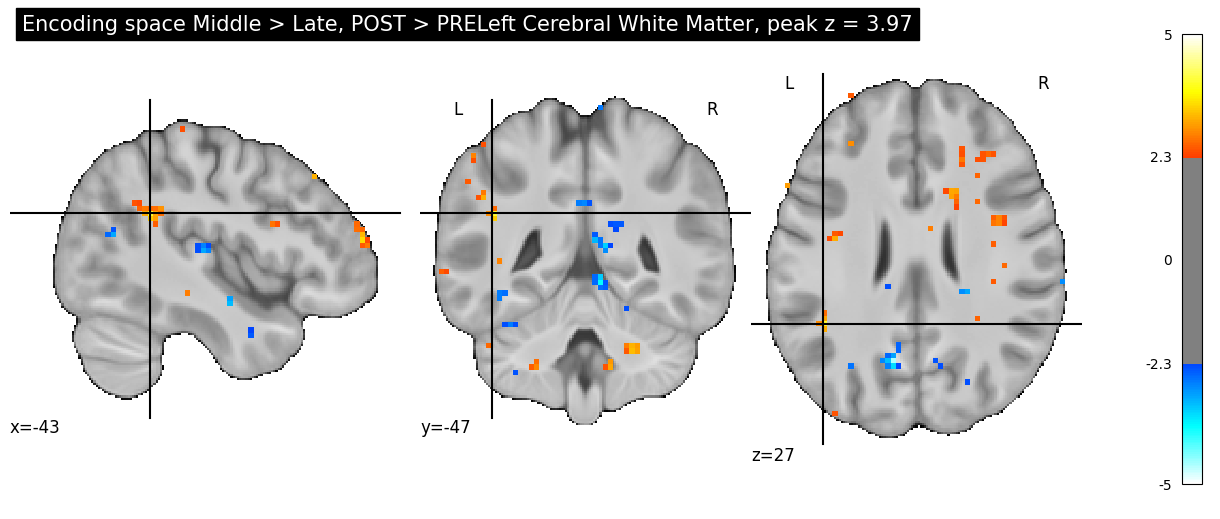

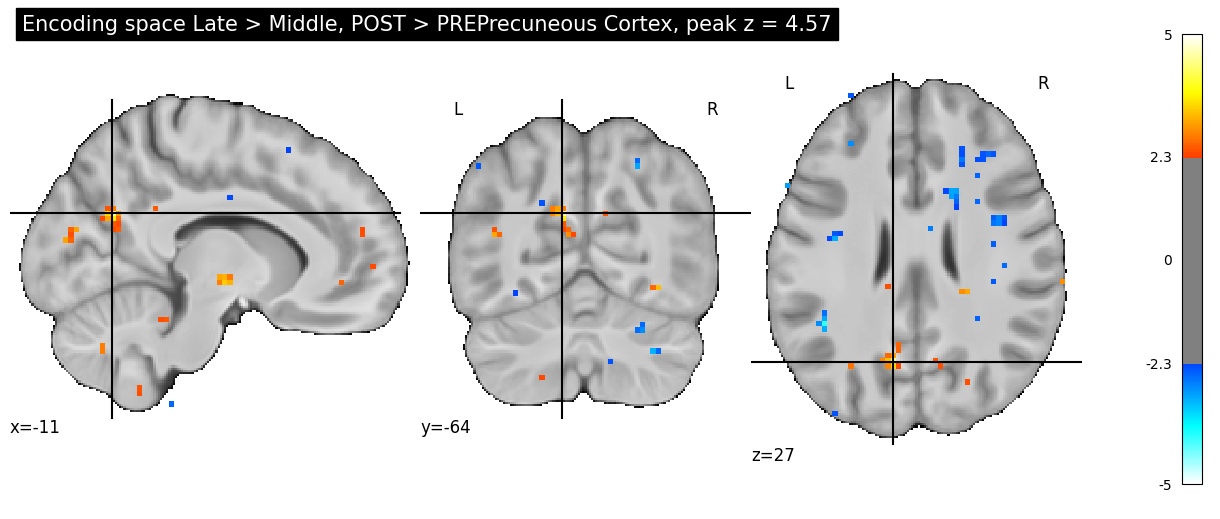

,contrast,figure_path,cut_x,cut_y,cut_z
0,early_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-8.5,3.0,-10.5
1,middle_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-23.5,0.5,62.0
2,late_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,6.5,40.5,37.0
3,early_gt_middle_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,34.0,-64.5,4.5
4,middle_gt_early_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-28.5,-64.5,-28.0
5,early_gt_late_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-38.5,-7.0,24.5
6,late_gt_early_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,54.0,15.5,4.5
7,middle_gt_late_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-43.5,-47.0,27.0
8,late_gt_middle_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/pre_post_encoding_space_early...,-11.0,-64.5,27.0


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_main_plot_index_smoothed5mm.csv


In [10]:
# ============================================================
# 11. Plot PRE/POST encoding-space-control contrasts on mean T1w background
# ============================================================

main_contrasts = [
    "encoding_space_old_gt_new_post_gt_pre",
    "early_gt_new_post_gt_pre",
    "middle_gt_new_post_gt_pre",
    "late_gt_new_post_gt_pre",
    "early_gt_middle_post_gt_pre",
    "middle_gt_early_post_gt_pre",
    "early_gt_late_post_gt_pre",
    "late_gt_early_post_gt_pre",
    "middle_gt_late_post_gt_pre",
    "late_gt_middle_post_gt_pre",
]

plot_title_map = {
    "encoding_space_old_gt_new_post_gt_pre": "Encoding-space old > new, POST > PRE",
    "early_gt_new_post_gt_pre": "Early old > new, POST > PRE",
    "middle_gt_new_post_gt_pre": "Middle old > new, POST > PRE",
    "late_gt_new_post_gt_pre": "Late old > new, POST > PRE",
    "early_gt_middle_post_gt_pre": "Encoding space Early > Middle, POST > PRE",
    "middle_gt_early_post_gt_pre": "Encoding space Middle > Early, POST > PRE",
    "early_gt_late_post_gt_pre": "Encoding space Early > Late, POST > PRE",
    "late_gt_early_post_gt_pre": "Encoding space Late > Early, POST > PRE",
    "middle_gt_late_post_gt_pre": "Encoding space Middle > Late, POST > PRE",
    "late_gt_middle_post_gt_pre": "Encoding space Late > Middle, POST > PRE",
}

plot_rows = []

for contrast_name in main_contrasts:
    if contrast_name not in set(second_level_table["contrast"]):
        print("Skipping missing contrast:", contrast_name)
        continue

    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]

    table = cluster_details_labeled.query(
        "contrast == @contrast_name and threshold_label == 'z_gt_2.33'"
    ).copy()

    if len(table) > 0:
        top = table.sort_values("Peak Stat", ascending=False).iloc[0]
        cut_coords = (float(top["X"]), float(top["Y"]), float(top["Z"]))
        atlas_label = top.get("harvard_oxford_cortical_label", "")
        if atlas_label == "Background":
            atlas_label = top.get("harvard_oxford_subcortical_label", "Background")
        title = (
            f"{plot_title_map[contrast_name]}"
            f"{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
        )
    else:
        cut_coords = (0, 0, 0)
        title = plot_title_map[contrast_name]

    fig_path = dirs["figures"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_zgt2p33.png"

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "cut_x": cut_coords[0],
        "cut_y": cut_coords[1],
        "cut_z": cut_coords[2],
    })

plot_index = pd.DataFrame(plot_rows)
plot_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_main_plot_index_{SMOOTHING_LABEL}.csv"
plot_index.to_csv(plot_index_path, index=False)
display(plot_index)
print("Saved:", plot_index_path)

## Optional interactive views

In [11]:
# ============================================================
# 12. Save optional interactive views
# ============================================================

interactive_rows = []

for contrast_name in main_contrasts:
    if contrast_name not in set(second_level_table["contrast"]):
        print("Skipping missing contrast:", contrast_name)
        continue

    z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
    html_path = dirs["interactive"] / f"{ANALYSIS_NAME}_{contrast_name}_{SMOOTHING_LABEL}_interactive.html"
    view = make_interactive_view(z_map_path, threshold=2.33, title=plot_title_map[contrast_name])
    view.save_as_html(str(html_path))
    interactive_rows.append({"contrast": contrast_name, "interactive_html_path": str(html_path)})

interactive_index = pd.DataFrame(interactive_rows)
interactive_index_path = dirs["tables"] / f"{ANALYSIS_NAME}_interactive_index_{SMOOTHING_LABEL}.csv"
interactive_index.to_csv(interactive_index_path, index=False)

display(interactive_index)
print("Saved:", interactive_index_path)

Skipping missing contrast: encoding_space_old_gt_new_post_gt_pre


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWa

,contrast,interactive_html_path
0,early_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
1,middle_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
2,late_gt_new_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
3,early_gt_middle_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
4,middle_gt_early_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
5,early_gt_late_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
6,late_gt_early_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
7,middle_gt_late_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...
8,late_gt_middle_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/pre_post_encoding_s...


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/pre_post_encoding_space_early_middle_late_control_glm_interactive_index_smoothed5mm.csv


## ROI visualization with hippocampus/amygdala masks

For each main encoding-space POST–PRE contrast, this cell creates:

- an ROI-masked interactive HTML view showing only suprathreshold activity inside the group consensus hippoAmyg mask;
- a static whole-brain z-map with the hippoAmyg ROI contour overlaid;
- a table counting suprathreshold positive/negative voxels inside the ROI.

ROI root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
Saving ROI figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays
Saving ROI interactive views to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views
Loaded 54 unilateral ROI masks.
Saved group consensus ROI mask:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/group_consensus_hippoAmyg_threshold-0.50_mask.nii.gz
Skipping missing contrast: encoding_space_old_gt_new_post_gt_pre


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


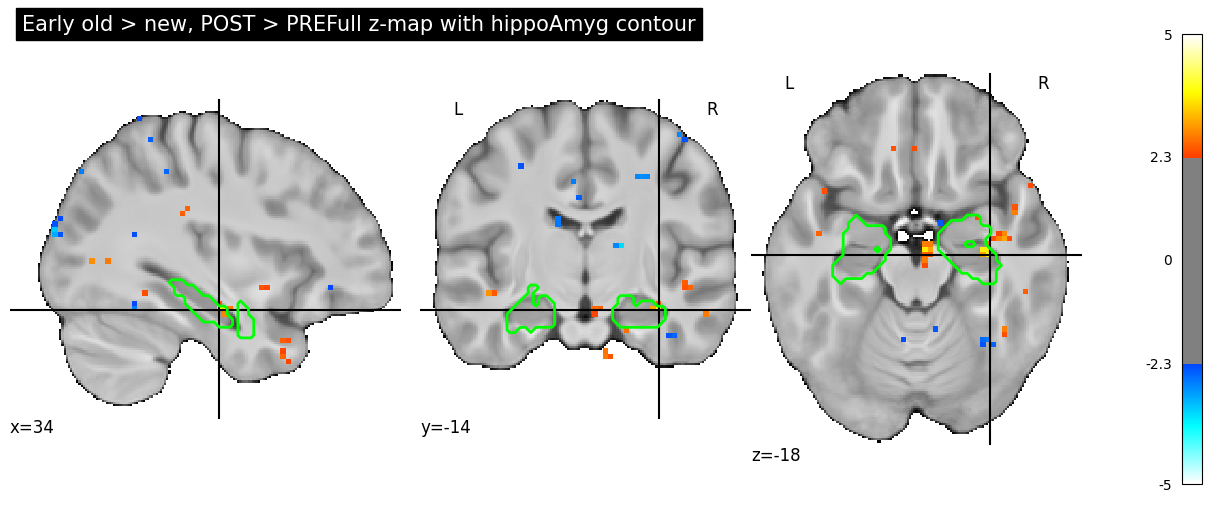

Contrast: early_gt_new_post_gt_pre
Title: Early old > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/early_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/early_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 15, 'negative_suprathreshold_voxels_inside_roi': 3, 'max_z_inside_roi': 3.7803285121917725, 'min_z_inside_roi': -2.9022185802459717, 'contrast': 'early_gt_new_post_gt_pre', 'display_title': 'Early old > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


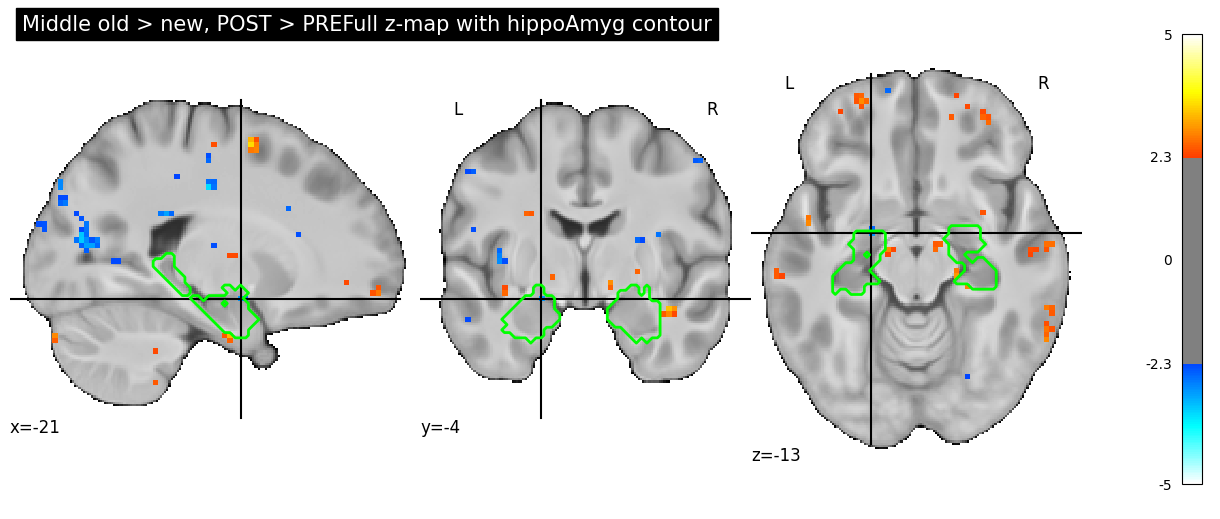

Contrast: middle_gt_new_post_gt_pre
Title: Middle old > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/middle_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/middle_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 3, 'negative_suprathreshold_voxels_inside_roi': 3, 'max_z_inside_roi': 2.4400224685668945, 'min_z_inside_roi': -2.9349002838134766, 'contrast': 'middle_gt_new_post_gt_pre', 'display_title': 'Middle old > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_enc

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


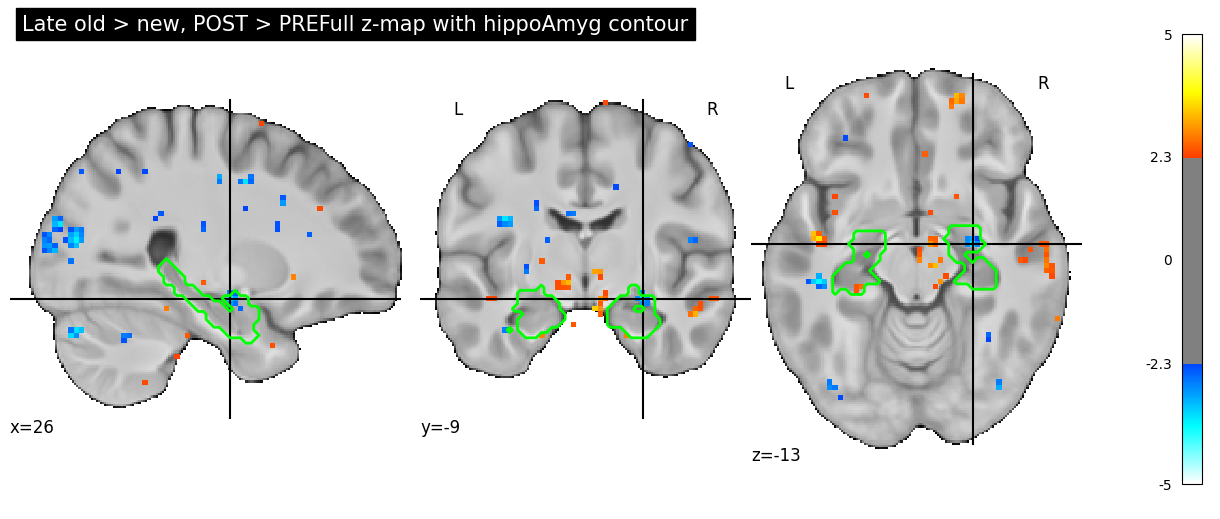

Contrast: late_gt_new_post_gt_pre
Title: Late old > new, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/late_gt_new_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/late_gt_new_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 7, 'negative_suprathreshold_voxels_inside_roi': 26, 'max_z_inside_roi': 2.95357608795166, 'min_z_inside_roi': -3.494072675704956, 'contrast': 'late_gt_new_post_gt_pre', 'display_title': 'Late old > new, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_ea

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


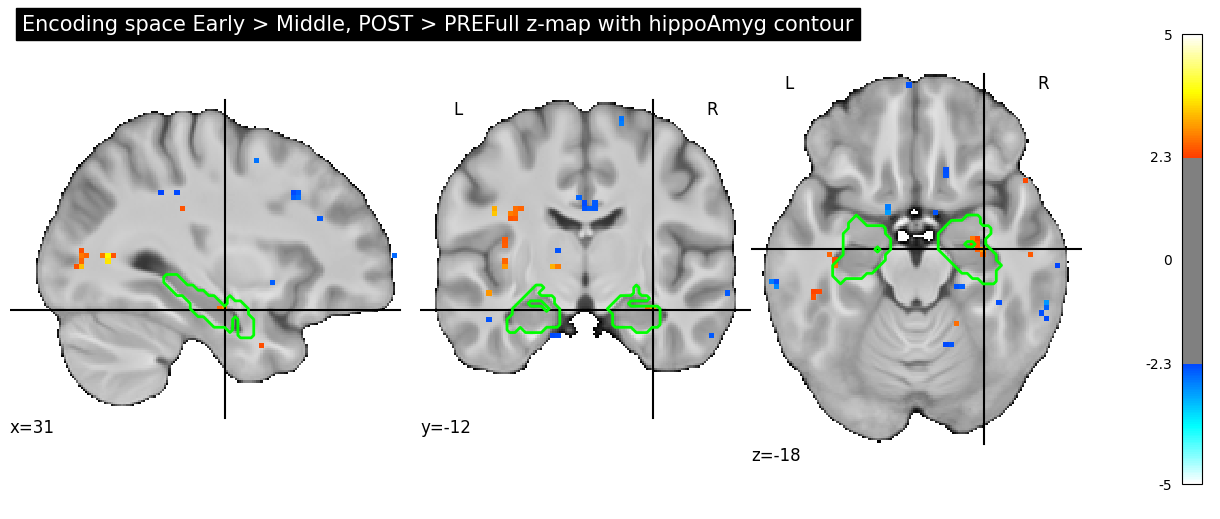

Contrast: early_gt_middle_post_gt_pre
Title: Encoding space Early > Middle, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/early_gt_middle_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/early_gt_middle_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 9, 'negative_suprathreshold_voxels_inside_roi': 6, 'max_z_inside_roi': 2.973987102508545, 'min_z_inside_roi': -2.926198959350586, 'contrast': 'early_gt_middle_post_gt_pre', 'display_title': 'Encoding space Early > Middle, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


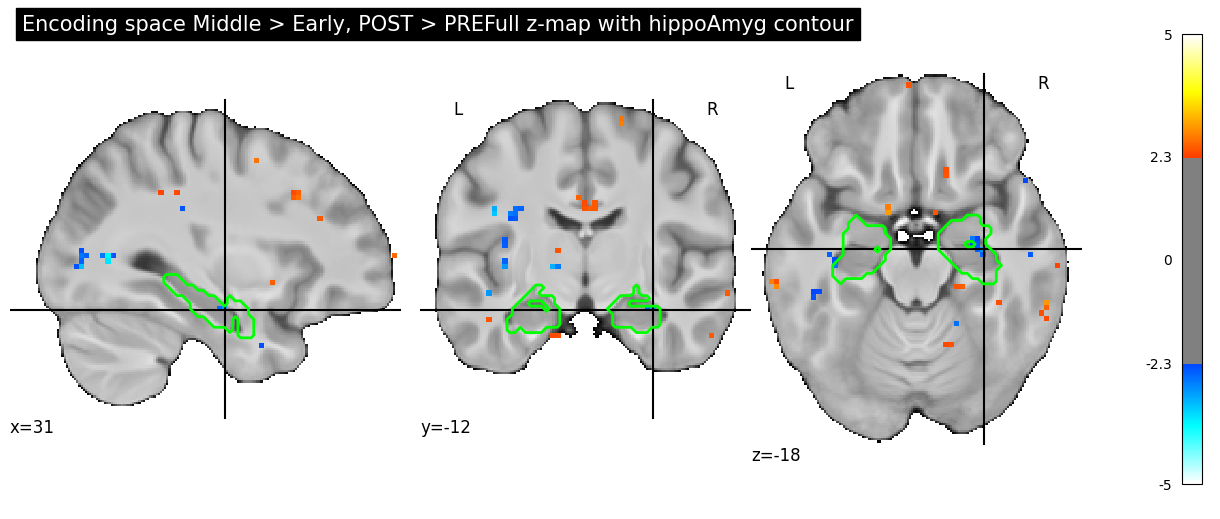

Contrast: middle_gt_early_post_gt_pre
Title: Encoding space Middle > Early, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/middle_gt_early_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/middle_gt_early_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 6, 'negative_suprathreshold_voxels_inside_roi': 9, 'max_z_inside_roi': 2.926198959350586, 'min_z_inside_roi': -2.973987102508545, 'contrast': 'middle_gt_early_post_gt_pre', 'display_title': 'Encoding space Middle > Early, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


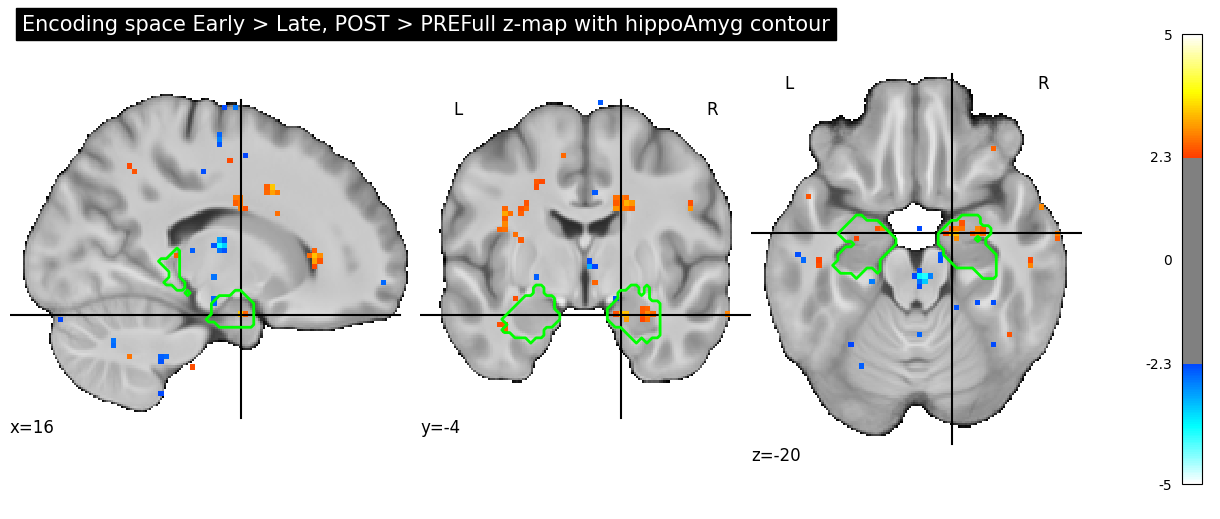

Contrast: early_gt_late_post_gt_pre
Title: Encoding space Early > Late, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/early_gt_late_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/early_gt_late_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 49, 'negative_suprathreshold_voxels_inside_roi': 2, 'max_z_inside_roi': 3.3174915313720703, 'min_z_inside_roi': -2.68381929397583, 'contrast': 'early_gt_late_post_gt_pre', 'display_title': 'Encoding space Early > Late, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/proce

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


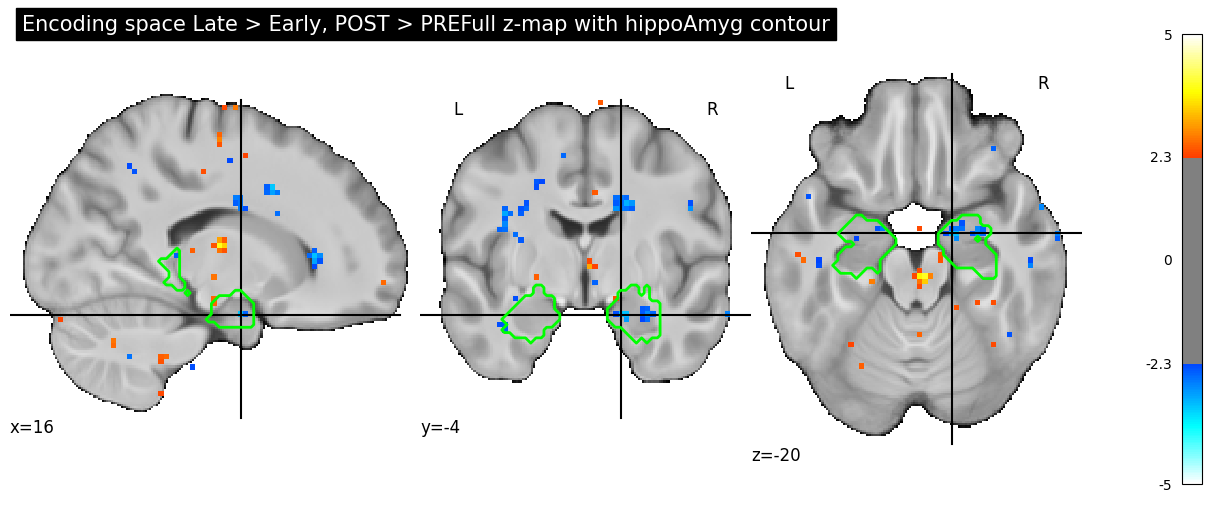

Contrast: late_gt_early_post_gt_pre
Title: Encoding space Late > Early, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/late_gt_early_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/late_gt_early_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 2, 'negative_suprathreshold_voxels_inside_roi': 49, 'max_z_inside_roi': 2.68381929397583, 'min_z_inside_roi': -3.3174915313720703, 'contrast': 'late_gt_early_post_gt_pre', 'display_title': 'Encoding space Late > Early, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/proce

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


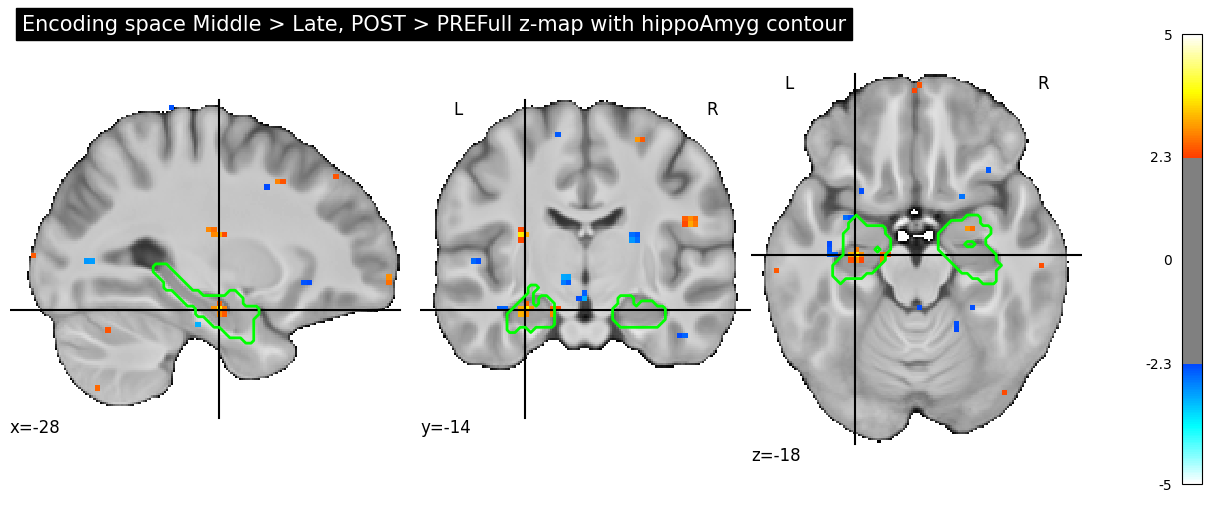

Contrast: middle_gt_late_post_gt_pre
Title: Encoding space Middle > Late, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/middle_gt_late_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/middle_gt_late_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 24, 'negative_suprathreshold_voxels_inside_roi': 6, 'max_z_inside_roi': 3.709643602371216, 'min_z_inside_roi': -2.570500612258911, 'contrast': 'middle_gt_late_post_gt_pre', 'display_title': 'Encoding space Middle > Late, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


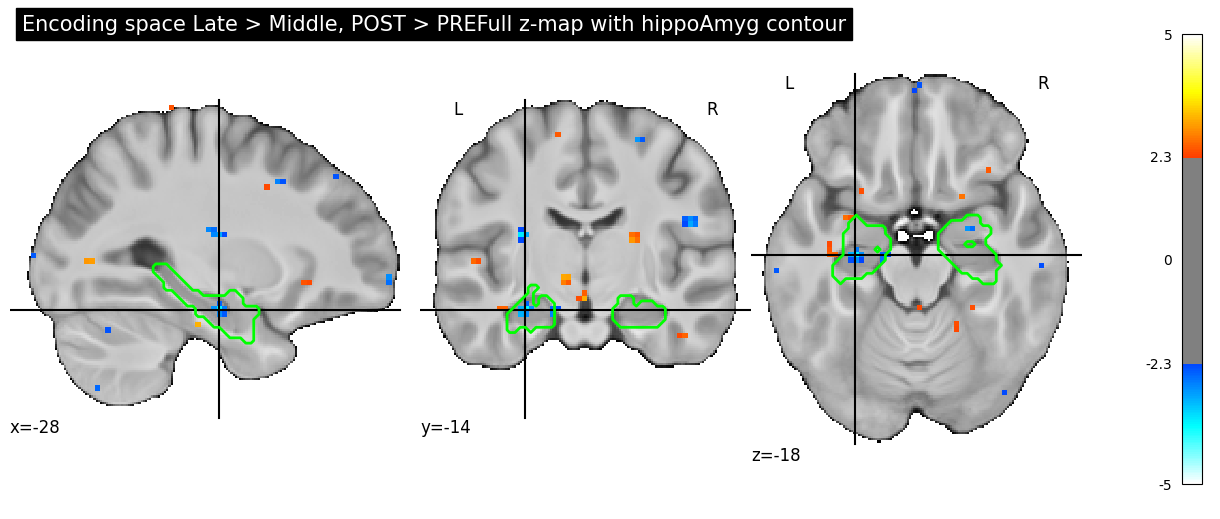

Contrast: late_gt_middle_post_gt_pre
Title: Encoding space Late > Middle, POST > PRE
Saved ROI-masked interactive HTML: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/interactive_views/roi_masked_views/late_gt_middle_post_gt_pre_hippoAmyg_masked_interactive.html
Saved contour overlay PNG: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/roi_mask_overlays/late_gt_middle_post_gt_pre_hippoAmyg_contour_overlay.png
ROI stats: {'roi_voxels': 1544, 'positive_suprathreshold_voxels_inside_roi': 6, 'negative_suprathreshold_voxels_inside_roi': 24, 'max_z_inside_roi': 2.570500612258911, 'min_z_inside_roi': -3.709643602371216, 'contrast': 'late_gt_middle_post_gt_pre', 'display_title': 'Encoding space Late > Middle, POST > PRE', 'z_map_path': '/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data

,roi_voxels,positive_suprathreshold_voxels_inside_roi,negative_suprathreshold_voxels_inside_roi,max_z_inside_roi,min_z_inside_roi,contrast,display_title,z_map_path,roi_masked_z_map_path
0,1544,15,3,3.780329,-2.902219,early_gt_new_post_gt_pre,"Early old > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/early_gt_new_post_...
1,1544,3,3,2.440022,-2.934900,middle_gt_new_post_gt_pre,"Middle old > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/middle_gt_new_post...
2,1544,7,26,2.953576,-3.494073,late_gt_new_post_gt_pre,"Late old > new, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/late_gt_new_post_g...
3,1544,9,6,2.973987,-2.926199,early_gt_middle_post_gt_pre,"Encoding space Early > Middle, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/early_gt_middle_po...
4,1544,6,9,2.926199,-2.973987,middle_gt_early_post_gt_pre,"Encoding space Middle > Early, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/middle_gt_early_po...
5,1544,49,2,3.317492,-2.683819,early_gt_late_post_gt_pre,"Encoding space Early > Late, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/early_gt_late_post...
6,1544,2,49,2.683819,-3.317492,late_gt_early_post_gt_pre,"Encoding space Late > Early, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/late_gt_early_post...
7,1544,24,6,3.709644,-2.570501,middle_gt_late_post_gt_pre,"Encoding space Middle > Late, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/middle_gt_late_pos...
8,1544,6,24,2.570501,-3.709644,late_gt_middle_post_gt_pre,"Encoding space Late > Middle, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/pr

Saved ROI overlap table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_overlap/pre_post_encoding_space_early_middle_late_control_glm_hippoAmyg_overlap_stats_zgt2.33.csv


In [12]:
# ============================================================
# 13. ROI visualization: hippocampus/amygdala mask overlays
# ============================================================

import nibabel as nib
from nilearn.image import resample_to_img, math_img, mean_img
from nilearn.plotting import plot_stat_map, view_img

ROI_NAME = "hippoAmyg"
ROI_ROOT = paths.data_dir / "rois" / "hippoAmyg_02022024"

ROI_THRESHOLD = 0.50
STAT_THRESHOLD = 2.33
VMAX = 5.0

roi_fig_dir = dirs["figures"] / "roi_mask_overlays"
roi_fig_dir.mkdir(parents=True, exist_ok=True)

roi_html_dir = dirs["interactive"] / "roi_masked_views"
roi_html_dir.mkdir(parents=True, exist_ok=True)

roi_table_dir = dirs["tables"] / "roi_overlap"
roi_table_dir.mkdir(parents=True, exist_ok=True)

print("ROI root:", ROI_ROOT)
print("Saving ROI figures to:", roi_fig_dir)
print("Saving ROI interactive views to:", roi_html_dir)

roi_imgs = []
missing_roi_rows = []

for subject in subjects:
    left_mask = (
        ROI_ROOT / subject / "ses-01" / "anat" /
        f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz"
    )
    right_mask = (
        ROI_ROOT / subject / "ses-01" / "anat" /
        f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz"
    )

    if left_mask.exists():
        roi_imgs.append(load_img(str(left_mask)))
    else:
        missing_roi_rows.append({"subject": subject, "hemi": "L", "missing_mask_path": str(left_mask)})

    if right_mask.exists():
        roi_imgs.append(load_img(str(right_mask)))
    else:
        missing_roi_rows.append({"subject": subject, "hemi": "R", "missing_mask_path": str(right_mask)})

print(f"Loaded {len(roi_imgs)} unilateral ROI masks.")

if missing_roi_rows:
    display(pd.DataFrame(missing_roi_rows))

assert len(roi_imgs) > 0, "No ROI masks found. Check ROI_ROOT."

roi_mean_img = mean_img(roi_imgs)
roi_group_mask_img = math_img(f"img >= {ROI_THRESHOLD}", img=roi_mean_img)

roi_group_mask_path = roi_table_dir / f"group_consensus_{ROI_NAME}_threshold-{ROI_THRESHOLD:.2f}_mask.nii.gz"
roi_group_mask_img.to_filename(str(roi_group_mask_path))

print("Saved group consensus ROI mask:")
print(roi_group_mask_path)


def compute_roi_overlap_stats(z_img, roi_mask_img, threshold=2.33):
    roi_resampled = resample_to_img(
        roi_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    roi_data = roi_resampled.get_fdata() > 0

    pos_supra = z_data > threshold
    neg_supra = z_data < -threshold

    pos_inside = pos_supra & roi_data
    neg_inside = neg_supra & roi_data

    if roi_data.sum() == 0:
        max_z_inside = np.nan
        min_z_inside = np.nan
    else:
        max_z_inside = float(np.nanmax(np.where(roi_data, z_data, np.nan)))
        min_z_inside = float(np.nanmin(np.where(roi_data, z_data, np.nan)))

    return {
        "roi_voxels": int(roi_data.sum()),
        "positive_suprathreshold_voxels_inside_roi": int(pos_inside.sum()),
        "negative_suprathreshold_voxels_inside_roi": int(neg_inside.sum()),
        "max_z_inside_roi": max_z_inside,
        "min_z_inside_roi": min_z_inside,
    }

roi_overlap_rows = []

for contrast_name in main_contrasts:
    if contrast_name not in set(second_level_table["contrast"]):
        print("Skipping missing contrast:", contrast_name)
        continue

    row = second_level_table.loc[second_level_table["contrast"] == contrast_name].iloc[0]
    z_map_path = Path(row["z_map_path"])
    z_img = load_img(str(z_map_path))

    roi_resampled = resample_to_img(
        roi_group_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_roi_img = math_img("z * (roi > 0)", z=z_img, roi=roi_resampled)

    z_roi_path = roi_table_dir / f"{contrast_name}_{ROI_NAME}_masked_zmap.nii.gz"
    z_roi_img.to_filename(str(z_roi_path))

    stats = compute_roi_overlap_stats(
        z_img=z_img,
        roi_mask_img=roi_group_mask_img,
        threshold=STAT_THRESHOLD,
    )

    stats["contrast"] = contrast_name
    stats["display_title"] = plot_title_map.get(contrast_name, contrast_name)
    stats["z_map_path"] = str(z_map_path)
    stats["roi_masked_z_map_path"] = str(z_roi_path)
    roi_overlap_rows.append(stats)

    html_path = roi_html_dir / f"{contrast_name}_{ROI_NAME}_masked_interactive.html"

    view = view_img(
        z_roi_img,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        threshold=STAT_THRESHOLD,
        vmax=VMAX,
        cmap="cold_hot",
        title=(
            f"{plot_title_map.get(contrast_name, contrast_name)} — "
            f"activity inside {ROI_NAME} ROI"
        ),
    )
    view.save_as_html(str(html_path))

    z_roi_data = z_roi_img.get_fdata()

    if np.any(np.abs(z_roi_data) > STAT_THRESHOLD):
        max_idx = np.unravel_index(np.nanargmax(np.abs(z_roi_data)), z_roi_data.shape)
        cut_coords = nib.affines.apply_affine(z_roi_img.affine, max_idx)
    else:
        cut_coords = (-28, -24, -14)

    fig = plt.figure(figsize=(12, 5))

    display_obj = plot_stat_map(
        z_img,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        threshold=STAT_THRESHOLD,
        vmax=VMAX,
        cmap="cold_hot",
        display_mode="ortho",
        cut_coords=cut_coords,
        black_bg=False,
        title=(
            f"{plot_title_map.get(contrast_name, contrast_name)}"
            f"Full z-map with {ROI_NAME} contour"
        ),
        figure=fig,
        dim=-0.2,
    )

    display_obj.add_contours(
        roi_resampled,
        levels=[0.5],
        colors="lime",
        linewidths=2.0,
    )

    contour_fig_path = roi_fig_dir / f"{contrast_name}_{ROI_NAME}_contour_overlay.png"
    fig.savefig(contour_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("=" * 80)
    print("Contrast:", contrast_name)
    print("Title:", plot_title_map.get(contrast_name, contrast_name))
    print("Saved ROI-masked interactive HTML:", html_path)
    print("Saved contour overlay PNG:", contour_fig_path)
    print("ROI stats:", stats)

roi_overlap_table = pd.DataFrame(roi_overlap_rows)
roi_overlap_table_path = roi_table_dir / f"{ANALYSIS_NAME}_{ROI_NAME}_overlap_stats_zgt{STAT_THRESHOLD:.2f}.csv"
roi_overlap_table.to_csv(roi_overlap_table_path, index=False)

display(roi_overlap_table)

print("Saved ROI overlap table:")
print(roi_overlap_table_path)

In [13]:
# ============================================================
# Spatial early/middle/late analysis: ROI setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, resample_to_img, mean_img, math_img, new_img_like
from nilearn import plotting
from scipy.stats import norm
from scipy import ndimage
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

ROI_NAME = "hippoAmyg"
ROI_ROOT = paths.data_dir / "rois" / "hippoAmyg_02022024"

ROI_THRESHOLD = 0.50
DISPLAY_THRESHOLDS = [2.33, 3.00]
SVC_ALPHA = 0.05

roi_table_dir = dirs["tables"] / "roi_spatial_early_middle_late"
roi_table_dir.mkdir(parents=True, exist_ok=True)

svc_dir = dirs["tables"] / "svc_spatial_early_middle_late"
svc_dir.mkdir(parents=True, exist_ok=True)

spatial_fig_dir = dirs["figures"] / "spatial_early_middle_late_results"
spatial_fig_dir.mkdir(parents=True, exist_ok=True)

print("ROI root:", ROI_ROOT)
print("ROI tables:", roi_table_dir)
print("SVC tables:", svc_dir)
print("Figures:", spatial_fig_dir)

# ------------------------------------------------------------
# Candidate spatial contrasts
# ------------------------------------------------------------
# Keep only contrasts that actually exist in second_level_table.

available_contrasts = set(second_level_table["contrast"].tolist())

candidate_spatial_contrasts = [
    # Main spatial/route-position pairwise contrasts
    "early_gt_middle_post_gt_pre",
    "middle_gt_early_post_gt_pre",
    "middle_gt_late_post_gt_pre",
    "late_gt_middle_post_gt_pre",
    "early_gt_late_post_gt_pre",
    "late_gt_early_post_gt_pre",

    # Old/new controls by route position, if present
    "early_gt_new_post_gt_pre",
    "middle_gt_new_post_gt_pre",
    "late_gt_new_post_gt_pre",

    # Average old > new, if present
    "encoding_space_old_gt_new_post_gt_pre",
    "old_gt_new_post_gt_pre",
]

spatial_contrasts = [
    c for c in candidate_spatial_contrasts
    if c in available_contrasts
]

# If naming differs slightly, also collect every contrast containing early/middle/late and post_gt_pre
auto_spatial_contrasts = [
    c for c in second_level_table["contrast"].tolist()
    if (
        "post_gt_pre" in c
        and any(token in c for token in ["early", "middle", "late"])
    )
]

for c in auto_spatial_contrasts:
    if c not in spatial_contrasts:
        spatial_contrasts.append(c)

print("Spatial contrasts found:")
for c in spatial_contrasts:
    print(" -", c)

assert len(spatial_contrasts) > 0, (
    "No early/middle/late POST > PRE contrasts found. "
    "Check contrast names in second_level_table."
)

# ------------------------------------------------------------
# Build group-consensus left, right, and bilateral hippoAmyg masks
# ------------------------------------------------------------

left_roi_imgs = []
right_roi_imgs = []
missing_roi_rows = []

for subject in subjects:
    left_mask = (
        ROI_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-L_label-hippoAmyg.nii.gz"
    )

    right_mask = (
        ROI_ROOT
        / subject
        / "ses-01"
        / "anat"
        / f"{subject}_ses-01_space-MNI152NLin2009cAsym_hemi-R_label-hippoAmyg.nii.gz"
    )

    if left_mask.exists():
        left_roi_imgs.append(load_img(str(left_mask)))
    else:
        missing_roi_rows.append({
            "subject": subject,
            "hemi": "L",
            "missing_mask_path": str(left_mask),
        })

    if right_mask.exists():
        right_roi_imgs.append(load_img(str(right_mask)))
    else:
        missing_roi_rows.append({
            "subject": subject,
            "hemi": "R",
            "missing_mask_path": str(right_mask),
        })

print(f"Loaded {len(left_roi_imgs)} left ROI masks.")
print(f"Loaded {len(right_roi_imgs)} right ROI masks.")

if missing_roi_rows:
    missing_roi_table = pd.DataFrame(missing_roi_rows)
    display(missing_roi_table)

assert len(left_roi_imgs) > 0, "No left ROI masks found."
assert len(right_roi_imgs) > 0, "No right ROI masks found."

left_roi_mean_img = mean_img(left_roi_imgs)
right_roi_mean_img = mean_img(right_roi_imgs)

left_roi_group_mask_img = math_img(
    f"img >= {ROI_THRESHOLD}",
    img=left_roi_mean_img,
)

right_roi_group_mask_img = math_img(
    f"img >= {ROI_THRESHOLD}",
    img=right_roi_mean_img,
)

bilateral_roi_group_mask_img = math_img(
    "(left > 0) | (right > 0)",
    left=left_roi_group_mask_img,
    right=right_roi_group_mask_img,
)

roi_masks = {
    "left": left_roi_group_mask_img,
    "right": right_roi_group_mask_img,
    "bilateral": bilateral_roi_group_mask_img,
}

# Save masks
for roi_name, roi_img in roi_masks.items():
    roi_path = (
        roi_table_dir
        / f"group_consensus_{roi_name}_{ROI_NAME}_threshold-{ROI_THRESHOLD:.2f}_mask.nii.gz"
    )
    roi_img.to_filename(str(roi_path))
    print(f"Saved {roi_name} ROI:", roi_path)

ROI root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/rois/hippoAmyg_02022024
ROI tables: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_spatial_early_middle_late
SVC tables: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/svc_spatial_early_middle_late
Figures: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/spatial_early_middle_late_results
Spatial contrasts found:
 - early_gt_middle_post_gt_pre
 - middle_gt_early_post_gt_pre
 - middle_gt_late_post_gt_pre
 - late_gt_middle_post_gt_pre
 - early_gt_late_post_gt_pre
 - late_gt_early_post_gt_pre
 - early_gt_new_post_gt_pre
 - middle_gt_new_post_gt_pre
 - late_gt_new_post_gt_pre
Loaded 27 left ROI masks.
Loaded 27 righ

In [14]:
# ============================================================
# Spatial analysis: extract peaks inside left/right/bilateral ROIs
# ============================================================

def classify_hemisphere(x_coord):
    if x_coord < 0:
        return "left"
    elif x_coord > 0:
        return "right"
    return "midline"


def classify_long_axis(y_coord):
    # Same heuristic as before.
    # y < -21 = posterior hippocampus; y >= -21 = anterior hippocampus.
    if y_coord < -21:
        return "posterior hippocampus"
    return "anterior hippocampus"


def get_voxel_volume_mm3(img):
    zooms = img.header.get_zooms()[:3]
    return float(np.prod(zooms))


def get_cluster_extent_for_peak(z_data, mask_data, peak_ijk, threshold, direction="positive", voxel_volume_mm3=1.0):
    """
    Compute cluster size containing the peak within the ROI mask.
    Cluster is defined at the given threshold and constrained to the ROI.
    """

    if direction == "positive":
        supra = (z_data > threshold) & mask_data
    elif direction == "negative":
        supra = (z_data < -threshold) & mask_data
    else:
        supra = (np.abs(z_data) > threshold) & mask_data

    if not supra[tuple(peak_ijk)]:
        return 0, 0.0

    structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
    labeled, n_clusters = ndimage.label(supra, structure=structure)

    peak_label = labeled[tuple(peak_ijk)]

    if peak_label == 0:
        return 0, 0.0

    n_voxels = int(np.sum(labeled == peak_label))
    extent_mm3 = float(n_voxels * voxel_volume_mm3)

    return n_voxels, extent_mm3


def extract_roi_peak_and_cluster(
    z_img,
    roi_mask_img,
    contrast_name,
    roi_name,
    direction="positive",
    threshold=2.33,
):
    """
    Extract max positive or max negative peak inside ROI,
    and compute cluster extent at threshold.
    """

    roi_resampled = resample_to_img(
        roi_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    mask_data = roi_resampled.get_fdata() > 0

    n_roi_voxels = int(mask_data.sum())
    voxel_volume_mm3 = get_voxel_volume_mm3(z_img)

    if n_roi_voxels == 0:
        return None

    z_inside = z_data[mask_data]

    if direction == "positive":
        peak_value = float(np.nanmax(z_inside))
        peak_mask = (z_data == peak_value) & mask_data
    elif direction == "negative":
        peak_value = float(np.nanmin(z_inside))
        peak_mask = (z_data == peak_value) & mask_data
    else:
        abs_inside = np.abs(z_inside)
        peak_abs = float(np.nanmax(abs_inside))
        peak_mask = (np.abs(z_data) == peak_abs) & mask_data
        peak_value = float(z_data[peak_mask][0])

    peak_ijk = np.array(np.where(peak_mask)).T[0]
    peak_xyz = nib.affines.apply_affine(z_img.affine, peak_ijk)

    # Cluster extent for this direction and threshold
    cluster_voxels, cluster_mm3 = get_cluster_extent_for_peak(
        z_data=z_data,
        mask_data=mask_data,
        peak_ijk=peak_ijk,
        threshold=threshold,
        direction=direction,
        voxel_volume_mm3=voxel_volume_mm3,
    )

    if direction == "positive":
        n_supra = int(np.sum((z_data > threshold) & mask_data))
    elif direction == "negative":
        n_supra = int(np.sum((z_data < -threshold) & mask_data))
    else:
        n_supra = int(np.sum((np.abs(z_data) > threshold) & mask_data))

    return {
        "contrast": contrast_name,
        "roi": roi_name,
        "direction": direction,
        "threshold": threshold,
        "n_roi_voxels": n_roi_voxels,
        "voxel_volume_mm3": voxel_volume_mm3,
        "peak_x": float(peak_xyz[0]),
        "peak_y": float(peak_xyz[1]),
        "peak_z_coord": float(peak_xyz[2]),
        "peak_z_stat": peak_value,
        "peak_hemisphere_from_x": classify_hemisphere(float(peak_xyz[0])),
        "peak_long_axis_zone": classify_long_axis(float(peak_xyz[1])),
        "n_suprathreshold_voxels_in_roi": n_supra,
        "peak_cluster_voxels_in_roi": cluster_voxels,
        "peak_cluster_extent_mm3_in_roi": cluster_mm3,
    }


roi_peak_rows = []

for contrast_name in spatial_contrasts:
    z_map_path = Path(
        second_level_table.loc[
            second_level_table["contrast"] == contrast_name,
            "z_map_path",
        ].iloc[0]
    )

    z_img = load_img(str(z_map_path))

    for roi_name, roi_img in roi_masks.items():
        for direction in ["positive", "negative"]:
            for threshold in DISPLAY_THRESHOLDS:
                result = extract_roi_peak_and_cluster(
                    z_img=z_img,
                    roi_mask_img=roi_img,
                    contrast_name=contrast_name,
                    roi_name=roi_name,
                    direction=direction,
                    threshold=threshold,
                )

                if result is not None:
                    result["z_map_path"] = str(z_map_path)
                    roi_peak_rows.append(result)

roi_peak_table = pd.DataFrame(roi_peak_rows)

roi_peak_table_path = (
    roi_table_dir
    / f"{ANALYSIS_NAME}_spatial_early_middle_late_roi_peak_table.csv"
)

roi_peak_table.to_csv(roi_peak_table_path, index=False)

display(roi_peak_table)

print("Saved ROI peak table:")
print(roi_peak_table_path)

# ------------------------------------------------------------
# Clean summary: positive peaks only, z > 2.33 or z > 3.0
# ------------------------------------------------------------

roi_peak_positive_summary = (
    roi_peak_table
    .query("direction == 'positive'")
    .sort_values(["threshold", "peak_z_stat"], ascending=[True, False])
    .reset_index(drop=True)
)

display(roi_peak_positive_summary)

positive_summary_path = (
    roi_table_dir
    / f"{ANALYSIS_NAME}_spatial_early_middle_late_positive_roi_peak_summary.csv"
)

roi_peak_positive_summary.to_csv(positive_summary_path, index=False)

print("Saved positive ROI peak summary:")
print(positive_summary_path)

,contrast,roi,direction,threshold,n_roi_voxels,voxel_volume_mm3,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_hemisphere_from_x,peak_long_axis_zone,n_suprathreshold_voxels_in_roi,peak_cluster_voxels_in_roi,peak_cluster_extent_mm3_in_roi,z_map_path
0,early_gt_middle_post_gt_pre,left,positive,2.33,770,15.625,-38.5,-19.5,-18.0,2.665055,left,anterior hippocampus,2,1,15.625,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
1,early_gt_middle_post_gt_pre,left,positive,3.00,770,15.625,-38.5,-19.5,-18.0,2.665055,left,anterior hippocampus,0,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
2,early_gt_middle_post_gt_pre,left,negative,2.33,770,15.625,-16.0,-14.5,-20.5,-2.765940,left,anterior hippocampus,2,2,31.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
3,early_gt_middle_post_gt_pre,left,negative,3.00,770,15.625,-16.0,-14.5,-20.5,-2.765940,left,anterior hippocampus,0,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
4,early_gt_middle_post_gt_pre,right,positive,2.33,774,15.625,31.5,-12.0,-18.0,2.973987,right,anterior hippocampus,7,7,109.375,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,late_gt_new_post_gt_pre,right,negative,3.00,774,15.625,26.5,-9.5,-13.0,-3.494073,right,anterior hippocampus,3,2,31.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
104,late_gt_new_post_gt_pre,bilateral,positive,2.33,1544,15.625,-21.0,-34.5,-5.5,2.953576,left,posterior hippocampus,7,4,62.500,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
105,late_gt_new_post_gt_pre,bilateral,positive,3.00,1544,15.625,-21.0,-34.5,-5.5,2.953576,left,posterior hippocampus,0,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
106,late_gt_new_post_gt_pre,bilateral,negative,2.33,1544,15.625,26.5,-9.5,-13.0,-3.494073,right,anterior hippocampus,26,10,156.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...


Saved ROI peak table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_spatial_early_middle_late/pre_post_encoding_space_early_middle_late_control_glm_spatial_early_middle_late_roi_peak_table.csv


,contrast,roi,direction,threshold,n_roi_voxels,voxel_volume_mm3,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_hemisphere_from_x,peak_long_axis_zone,n_suprathreshold_voxels_in_roi,peak_cluster_voxels_in_roi,peak_cluster_extent_mm3_in_roi,z_map_path
0,early_gt_new_post_gt_pre,right,positive,2.33,774,15.625,34.0,-14.5,-18.0,3.780329,right,anterior hippocampus,9,5,78.125,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
1,early_gt_new_post_gt_pre,bilateral,positive,2.33,1544,15.625,34.0,-14.5,-18.0,3.780329,right,anterior hippocampus,15,5,78.125,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
2,middle_gt_late_post_gt_pre,left,positive,2.33,770,15.625,-28.5,-14.5,-18.0,3.709644,left,anterior hippocampus,19,11,171.875,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
3,middle_gt_late_post_gt_pre,bilateral,positive,2.33,1544,15.625,-28.5,-14.5,-18.0,3.709644,left,anterior hippocampus,24,11,171.875,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
4,early_gt_late_post_gt_pre,right,positive,2.33,774,15.625,16.5,-4.5,-20.5,3.317492,right,anterior hippocampus,36,15,234.375,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
5,early_gt_late_post_gt_pre,bilateral,positive,2.33,1544,15.625,16.5,-4.5,-20.5,3.317492,right,anterior hippocampus,49,15,234.375,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
6,early_gt_late_post_gt_pre,left,positive,2.33,770,15.625,-38.5,-7.0,-25.5,3.123880,left,anterior hippocampus,13,2,31.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
7,early_gt_middle_post_gt_pre,right,positive,2.33,774,15.625,31.5,-12.0,-18.0,2.973987,right,anterior hippocampus,7,7,109.375,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
8,early_gt_middle_post_gt_pre,bilateral,positive,2.33,1544,15.625,31.5,-12.0,-18.0,2.973987,right,anterior hippocampus,9,7,109.375,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...
9,late_gt_new_post_gt_pre,left,positive,2.33,770,15.625,-21.0,-34.5,-5.5,2.953576,left,posterior hippocampus,7,4,62.500,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...


Saved positive ROI peak summary:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/roi_spatial_early_middle_late/pre_post_encoding_space_early_middle_late_control_glm_spatial_early_middle_late_positive_roi_peak_summary.csv


In [15]:
# ============================================================
# Spatial analysis: voxelwise SVC inside anatomical ROIs
# ============================================================

def run_voxelwise_svc_in_roi(
    z_map_path,
    roi_mask_img,
    contrast_name,
    roi_name,
    direction="positive",
):
    """
    Run voxelwise SVC inside a supplied anatomical ROI.
    Bonferroni and FDR are computed across all voxels in the ROI.
    """

    z_img = load_img(str(z_map_path))

    roi_resampled = resample_to_img(
        roi_mask_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    roi_data = roi_resampled.get_fdata() > 0

    assert roi_data.sum() > 0, f"{roi_name} ROI has zero voxels after resampling."

    z_inside = z_data[roi_data]
    n_voxels = int(roi_data.sum())

    if direction == "positive":
        score = z_inside.copy()
        peak_index = int(np.nanargmax(score))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))

    elif direction == "negative":
        score = -z_inside
        peak_index = int(np.nanargmax(score))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))

    elif direction == "two-sided":
        score = np.abs(z_inside)
        peak_index = int(np.nanargmax(score))
        peak_z = float(z_inside[peak_index])
        p_values = 2.0 * norm.sf(np.abs(z_inside))
        peak_p_unc = float(2.0 * norm.sf(abs(peak_z)))

    else:
        raise ValueError("direction must be 'positive', 'negative', or 'two-sided'.")

    reject_fdr, q_values, _, _ = multipletests(
        p_values,
        alpha=SVC_ALPHA,
        method="fdr_bh",
    )

    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))
    peak_q_fdr = float(q_values[peak_index])

    roi_indices = np.array(np.where(roi_data)).T
    peak_ijk = roi_indices[peak_index]
    peak_xyz = nib.affines.apply_affine(z_img.affine, peak_ijk)

    # Cluster sizes at z > 2.33 and z > 3.0
    voxel_volume_mm3 = get_voxel_volume_mm3(z_img)

    cluster_233_vox, cluster_233_mm3 = get_cluster_extent_for_peak(
        z_data=z_data,
        mask_data=roi_data,
        peak_ijk=peak_ijk,
        threshold=2.33,
        direction=direction,
        voxel_volume_mm3=voxel_volume_mm3,
    )

    cluster_300_vox, cluster_300_mm3 = get_cluster_extent_for_peak(
        z_data=z_data,
        mask_data=roi_data,
        peak_ijk=peak_ijk,
        threshold=3.00,
        direction=direction,
        voxel_volume_mm3=voxel_volume_mm3,
    )

    return {
        "contrast": contrast_name,
        "roi": roi_name,
        "direction": direction,
        "n_voxels_in_roi": n_voxels,
        "peak_x": float(peak_xyz[0]),
        "peak_y": float(peak_xyz[1]),
        "peak_z_coord": float(peak_xyz[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_roi": peak_p_bonf,
        "peak_q_fdr_within_roi": peak_q_fdr,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
        "n_voxels_bonf_p_lt_0_05": int(np.sum((p_values * n_voxels) < 0.05)),
        "peak_hemisphere_from_x": classify_hemisphere(float(peak_xyz[0])),
        "peak_long_axis_zone": classify_long_axis(float(peak_xyz[1])),
        "cluster_voxels_z_gt_2_33": cluster_233_vox,
        "cluster_extent_mm3_z_gt_2_33": cluster_233_mm3,
        "cluster_voxels_z_gt_3_00": cluster_300_vox,
        "cluster_extent_mm3_z_gt_3_00": cluster_300_mm3,
        "z_map_path": str(z_map_path),
    }


# ------------------------------------------------------------
# Run SVC for all spatial contrasts, left/right/bilateral
# ------------------------------------------------------------

svc_rows = []

for contrast_name in spatial_contrasts:
    z_map_path = Path(
        second_level_table.loc[
            second_level_table["contrast"] == contrast_name,
            "z_map_path",
        ].iloc[0]
    )

    for roi_name, roi_img in roi_masks.items():
        result = run_voxelwise_svc_in_roi(
            z_map_path=z_map_path,
            roi_mask_img=roi_img,
            contrast_name=contrast_name,
            roi_name=roi_name,
            direction="positive",
        )

        svc_rows.append(result)

spatial_svc_table = pd.DataFrame(svc_rows)

# Optional correction across all planned spatial SVC tests
spatial_svc_table["p_bonf_roi_x_all_spatial_tests"] = (
    spatial_svc_table["peak_p_uncorrected"]
    * spatial_svc_table["n_voxels_in_roi"]
    * len(spatial_svc_table)
).clip(upper=1.0)

_, q_across_all, _, _ = multipletests(
    spatial_svc_table["peak_p_bonferroni_within_roi"].values,
    alpha=0.05,
    method="fdr_bh",
)

spatial_svc_table["q_fdr_across_all_spatial_svc_tests"] = q_across_all

spatial_svc_table = spatial_svc_table.sort_values(
    ["peak_p_bonferroni_within_roi", "peak_q_fdr_within_roi"]
).reset_index(drop=True)

spatial_svc_table_path = (
    svc_dir
    / f"{ANALYSIS_NAME}_spatial_early_middle_late_voxelwise_svc_results.csv"
)

spatial_svc_table.to_csv(spatial_svc_table_path, index=False)

display(spatial_svc_table)

print("Saved spatial SVC table:")
print(spatial_svc_table_path)

,contrast,roi,direction,n_voxels_in_roi,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_p_uncorrected,peak_p_bonferroni_within_roi,peak_q_fdr_within_roi,n_voxels_p_unc_lt_0_001,n_voxels_fdr_q_lt_0_05,n_voxels_bonf_p_lt_0_05,peak_hemisphere_from_x,peak_long_axis_zone,cluster_voxels_z_gt_2_33,cluster_extent_mm3_z_gt_2_33,cluster_voxels_z_gt_3_00,cluster_extent_mm3_z_gt_3_00,z_map_path,p_bonf_roi_x_all_spatial_tests,q_fdr_across_all_spatial_svc_tests
0,early_gt_new_post_gt_pre,right,positive,774,34.0,-14.5,-18.0,3.780329,0.000078,0.060613,0.045921,3,3,0,right,anterior hippocampus,5,78.125,4,62.500,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
1,middle_gt_late_post_gt_pre,left,positive,770,-28.5,-14.5,-18.0,3.709644,0.000104,0.079907,0.079907,3,0,0,left,anterior hippocampus,11,171.875,3,46.875,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
2,early_gt_new_post_gt_pre,bilateral,positive,1544,34.0,-14.5,-18.0,3.780329,0.000078,0.120912,0.091605,3,0,0,right,anterior hippocampus,5,78.125,4,62.500,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
3,middle_gt_late_post_gt_pre,bilateral,positive,1544,-28.5,-14.5,-18.0,3.709644,0.000104,0.160230,0.160230,3,0,0,left,anterior hippocampus,11,171.875,3,46.875,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
4,early_gt_late_post_gt_pre,right,positive,774,16.5,-4.5,-20.5,3.317492,0.000454,0.351511,0.142272,3,0,0,right,anterior hippocampus,15,234.375,2,31.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
5,early_gt_late_post_gt_pre,left,positive,770,-38.5,-7.0,-25.5,3.123880,0.000892,0.687161,0.557595,1,0,0,left,anterior hippocampus,2,31.250,1,15.625,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
6,early_gt_late_post_gt_pre,bilateral,positive,1544,16.5,-4.5,-20.5,3.317492,0.000454,0.701205,0.283809,4,0,0,right,anterior hippocampus,15,234.375,2,31.250,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
7,early_gt_new_post_gt_pre,left,positive,770,-26.0,-39.5,4.5,2.819005,0.002409,1.000000,0.620456,0,0,0,left,posterior hippocampus,1,15.625,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
8,middle_gt_late_post_gt_pre,right,positive,774,24.0,-2.0,-18.0,2.937037,0.001657,1.000000,0.709700,0,0,0,right,anterior hippocampus,4,62.500,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0
9,late_gt_new_post_gt_pre,left,positive,770,-21.0,-34.5,-5.5,2.953576,0.001571,1.000000,0.805061,0,0,0,left,posterior hippocampus,4,62.500,0,0.000,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,1.0,1.0


Saved spatial SVC table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/svc_spatial_early_middle_late/pre_post_encoding_space_early_middle_late_control_glm_spatial_early_middle_late_voxelwise_svc_results.csv


In [16]:
# ============================================================
# Clean spatial SVC summary table
# ============================================================

def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")

def fmt_z(x):
    if pd.isna(x):
        return "—"
    return f"{float(x):.2f}"

def fmt_coord(row):
    return (
        f"({row['peak_x']:.0f}, "
        f"{row['peak_y']:.0f}, "
        f"{row['peak_z_coord']:.0f})"
    )

def spatial_label(contrast):
    label = contrast
    label = label.replace("_post_gt_pre", "")
    label = label.replace("_gt_", " > ")
    label = label.replace("_", " ")
    label = label.replace("early", "Early")
    label = label.replace("middle", "Middle")
    label = label.replace("late", "Late")
    label = label.replace("new", "new")
    return label

def svc_status(row):
    p_bonf = row["peak_p_bonferroni_within_roi"]
    q_fdr = row["peak_q_fdr_within_roi"]

    if p_bonf < 0.05 and q_fdr < 0.05:
        return "Passes Bonferroni + FDR"
    elif q_fdr < 0.05:
        return "Passes FDR only"
    elif p_bonf < 0.05:
        return "Passes Bonferroni only"
    else:
        return "Does not pass anatomical ROI SVC"

# Keep rows that are either strong or potentially relevant
spatial_svc_summary_source = spatial_svc_table[
    (
        spatial_svc_table["peak_z_stat"] >= 2.33
    )
    | (
        spatial_svc_table["peak_p_bonferroni_within_roi"] < 0.10
    )
    | (
        spatial_svc_table["peak_q_fdr_within_roi"] < 0.10
    )
].copy()

spatial_svc_summary_source = spatial_svc_summary_source.sort_values(
    ["peak_p_bonferroni_within_roi", "peak_z_stat"],
    ascending=[True, False],
)

spatial_svc_clean = pd.DataFrame({
    "Contrast": spatial_svc_summary_source["contrast"].apply(spatial_label),
    "ROI": spatial_svc_summary_source["roi"],
    "Peak MNI": spatial_svc_summary_source.apply(fmt_coord, axis=1),
    "Region": spatial_svc_summary_source["peak_long_axis_zone"],
    "z": spatial_svc_summary_source["peak_z_stat"].apply(fmt_z),
    "pSVC Bonf.": spatial_svc_summary_source["peak_p_bonferroni_within_roi"].apply(fmt_p),
    "qSVC FDR": spatial_svc_summary_source["peak_q_fdr_within_roi"].apply(fmt_p),
    "Cluster vox. z>2.33": spatial_svc_summary_source["cluster_voxels_z_gt_2_33"],
    "Cluster mm³ z>2.33": spatial_svc_summary_source["cluster_extent_mm3_z_gt_2_33"].round(1),
    "Anatomical ROI SVC result": spatial_svc_summary_source.apply(svc_status, axis=1),
})

display(spatial_svc_clean)

spatial_svc_clean_path = (
    svc_dir
    / f"{ANALYSIS_NAME}_spatial_early_middle_late_clean_svc_summary.csv"
)

spatial_svc_clean.to_csv(spatial_svc_clean_path, index=False)

print("Saved clean spatial SVC summary:")
print(spatial_svc_clean_path)

,Contrast,ROI,Peak MNI,Region,z,pSVC Bonf.,qSVC FDR,Cluster vox. z>2.33,Cluster mm³ z>2.33,Anatomical ROI SVC result
0,Early > new,right,"(34, -14, -18)",anterior hippocampus,3.78,.061,.046,5,78.1,Passes FDR only
1,Middle > Late,left,"(-28, -14, -18)",anterior hippocampus,3.71,.080,.080,11,171.9,Does not pass anatomical ROI SVC
2,Early > new,bilateral,"(34, -14, -18)",anterior hippocampus,3.78,.121,.092,5,78.1,Does not pass anatomical ROI SVC
3,Middle > Late,bilateral,"(-28, -14, -18)",anterior hippocampus,3.71,.160,.160,11,171.9,Does not pass anatomical ROI SVC
4,Early > Late,right,"(16, -4, -20)",anterior hippocampus,3.32,.352,.142,15,234.4,Does not pass anatomical ROI SVC
5,Early > Late,left,"(-38, -7, -26)",anterior hippocampus,3.12,.687,.558,2,31.2,Does not pass anatomical ROI SVC
6,Early > Late,bilateral,"(16, -4, -20)",anterior hippocampus,3.32,.701,.284,15,234.4,Does not pass anatomical ROI SVC
11,Early > Middle,right,"(32, -12, -18)",anterior hippocampus,2.97,1.000,.835,7,109.4,Does not pass anatomical ROI SVC
12,Early > Middle,bilateral,"(32, -12, -18)",anterior hippocampus,2.97,1.000,.866,7,109.4,Does not pass anatomical ROI SVC
9,Late > new,left,"(-21, -34, -6)",posterior hippocampus,2.95,1.000,.805,4,62.5,Does not pass anatomical ROI SVC


Saved clean spatial SVC summary:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/svc_spatial_early_middle_late/pre_post_encoding_space_early_middle_late_control_glm_spatial_early_middle_late_clean_svc_summary.csv


Best spatial hippocampal result:
Contrast: early_gt_new_post_gt_pre
ROI: right
Peak: (34.0, -14.5, -18.0)
z: 3.7803285121917725
pSVC Bonf: 0.06061254605254453
qSVC FDR: 0.04592129052748693
Region: anterior hippocampus


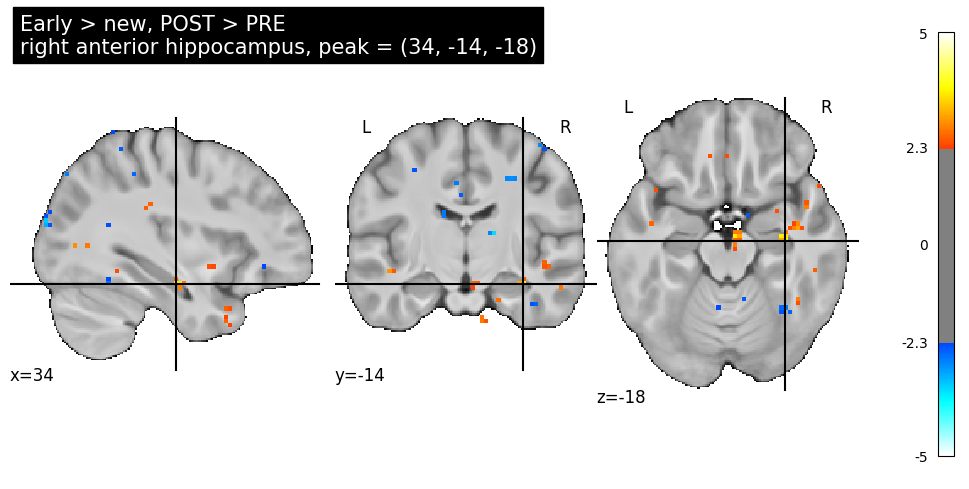

Saved best spatial figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/spatial_early_middle_late_results/pre_post_encoding_space_early_middle_late_control_glm_BEST_SPATIAL_early_gt_new_post_gt_pre_right_hippoAmyg_ortho.png


In [17]:
# ============================================================
# First clean spatial result figure: best hippocampal SVC peak
# ============================================================

# Pick best positive anatomical SVC result
best_row = spatial_svc_table.sort_values(
    ["peak_p_bonferroni_within_roi", "peak_z_stat"],
    ascending=[True, False],
).iloc[0]

best_contrast = best_row["contrast"]
best_peak = (
    float(best_row["peak_x"]),
    float(best_row["peak_y"]),
    float(best_row["peak_z_coord"]),
)

best_z = float(best_row["peak_z_stat"])
best_roi = best_row["roi"]
best_region = best_row["peak_long_axis_zone"]
best_p_svc = best_row["peak_p_bonferroni_within_roi"]
best_q_svc = best_row["peak_q_fdr_within_roi"]

print("Best spatial hippocampal result:")
print("Contrast:", best_contrast)
print("ROI:", best_roi)
print("Peak:", best_peak)
print("z:", best_z)
print("pSVC Bonf:", best_p_svc)
print("qSVC FDR:", best_q_svc)
print("Region:", best_region)

z_map_path = Path(
    second_level_table.loc[
        second_level_table["contrast"] == best_contrast,
        "z_map_path",
    ].iloc[0]
)

z_img = load_img(str(z_map_path))

bg_for_plot = mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None

fig = plt.figure(figsize=(9.5, 4.7), facecolor="white")

display_obj = plotting.plot_stat_map(
    z_img,
    bg_img=bg_for_plot,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    symmetric_cbar=True,
    display_mode="ortho",
    cut_coords=best_peak,
    black_bg=False,
    colorbar=True,
    annotate=True,
    draw_cross=True,
    dim=-0.2,
    figure=fig,
    title=(
        f"{spatial_label(best_contrast)}, POST > PRE\n"
        f"{best_roi} {best_region}, peak = "
        f"({best_peak[0]:.0f}, {best_peak[1]:.0f}, {best_peak[2]:.0f})"
    ),
)

spatial_best_fig_path = (
    spatial_fig_dir
    / f"{ANALYSIS_NAME}_BEST_SPATIAL_{best_contrast}_{best_roi}_hippoAmyg_ortho.png"
)

fig.savefig(
    spatial_best_fig_path,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved best spatial figure:")
print(spatial_best_fig_path)

## Literature-defined hippocampal SVC

To avoid circular inference from spheres centered on peaks observed in the present dataset, we test the encoding-position contrasts in independent 6 mm spheres centered on hippocampal coordinates reported in previous studies.

The main goal is to determine whether route-position / encoding-position effects appear in literature-defined hippocampal regions related to spatial distance, temporal distance, and event-structure representations.

Correction is performed voxelwise within each 6 mm literature-defined sphere. Figures display activation only within the selected literature-defined sphere.

Saving literature SVC tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position
Saving literature SVC figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position


,paper,roi_name,concept,x,y,z,priority
0,Deuker et al.,Deuker_temporal_right_medial_anterior_HPC,Temporal distance / close temporal relationships,26.0,-18.0,-22.0,temporal_event_map
1,Deuker et al.,Deuker_spatial_right_medial_anterior_HPC,Spatial distance / close spatial relationships,34.0,-17.0,-22.0,spatial_event_map
2,Deuker et al.,Deuker_combined_space_time_right_medial_anterior_HPC,Combined spatial and temporal proximity,32.0,-17.0,-22.0,space_time_event_map
3,Bellmund et al. 2022,Bellmund_same_sequence_left_anterior_HPC,"Constructed event-time relations, same sequence",-24.0,-13.0,-20.0,temporal_structure
4,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,31.0,-16.0,-21.0,temporal_structure
5,Bellmund et al. 2022,Bellmund_across_sequence_left_anterior_HPC_exploratory,"Across-sequence temporal relation, exploratory",-26.0,-19.0,-15.0,temporal_structure
6,Montagrin et al.,Montagrin_current_gt_remote_left_posterior_HPC,Current > remote goals,-30.0,-31.0,-14.5,temporal_goal_structure
7,Montagrin et al.,Montagrin_remote_gt_current_left_anterior_HPC,Remote > current goals,-15.0,-8.5,-14.5,temporal_goal_structure
8,Montagrin et al.,Montagrin_remote_gt_current_right_anterior_HPC,Remote > current goals,17.5,-21.0,-14.5,temporal_goal_structure
9,Viard et al.,Viard_left_posterior_HPC_autobiographical_period,"Autobiographical memory period, left posterior hippocampus",-30.0,-26.0,-12.0,autobiographical_memory



Testing 22 contrasts in 12 literature spheres:
 - early_gt_new_post_gt_pre
 - middle_gt_new_post_gt_pre
 - late_gt_new_post_gt_pre
 - encoding_time_old_gt_new_post_gt_pre
 - early_gt_middle_post_gt_pre
 - middle_gt_early_post_gt_pre
 - early_gt_late_post_gt_pre
 - late_gt_early_post_gt_pre
 - middle_gt_late_post_gt_pre
 - late_gt_middle_post_gt_pre
 - pre_early_gt_middle
 - pre_middle_gt_early
 - pre_early_gt_late
 - pre_late_gt_early
 - pre_middle_gt_late
 - pre_late_gt_middle
 - post_early_gt_middle
 - post_middle_gt_early
 - post_early_gt_late
 - post_late_gt_early
 - post_middle_gt_late
 - post_late_gt_middle

Sphere: Deuker et al. | Deuker_temporal_right_medial_anterior_HPC | center=(26.0, -18.0, -22.0)

Sphere: Deuker et al. | Deuker_spatial_right_medial_anterior_HPC | center=(34.0, -17.0, -22.0)

Sphere: Deuker et al. | Deuker_combined_space_time_right_medial_anterior_HPC | center=(32.0, -17.0, -22.0)

Sphere: Bellmund et al. 2022 | Bellmund_same_sequence_left_anterior_HPC | ce

,n_voxels_in_sphere,peak_x,peak_y,peak_z_coord,peak_z_stat,peak_distance_from_literature_center_mm,peak_p_uncorrected,peak_p_bonferroni_within_sphere,peak_q_fdr_within_sphere,nearest_center_x,nearest_center_y,nearest_center_z_coord,nearest_center_z_stat,nearest_center_p_uncorrected,n_voxels_p_unc_lt_0_001,n_voxels_bonf_p_lt_0_05,n_voxels_fdr_q_lt_0_05,paper,literature_roi,concept,priority,contrast,contrast_label,sphere_center_x,sphere_center_y,sphere_center_z,sphere_radius_mm,sphere_mask_path,z_map_path,peak_hemisphere_from_x,peak_long_axis_zone,p_bonf_sphere_x_contrasts_within_literature_roi,q_fdr_across_contrasts_within_literature_roi,p_bonf_all_literature_sphere_tests,q_fdr_all_literature_sphere_tests
0,56,34.0,-12.0,-18.0,3.968380,5.830952,0.000036,0.002026,0.002026,31.5,-17.0,-20.5,0.666972,0.252395,1,1,4,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,temporal_structure,pre_middle_gt_early,pre Middle > Early,31.0,-16.0,-21.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encodin...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,right,anterior hippocampus,0.044575,0.044575,0.534905,0.278534
1,55,34.0,-14.5,-18.0,3.780329,5.123475,0.000078,0.004307,0.004307,31.5,-17.0,-23.0,0.211506,0.416246,1,1,3,Deuker et al.,Deuker_combined_space_time_right_medial_anterior_HPC,Combined spatial and temporal proximity,space_time_event_map,early_gt_new_post_gt_pre,"Early > new, POST > PRE",32.0,-17.0,-22.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encodin...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,right,anterior hippocampus,0.094756,0.094756,1.000000,0.278534
2,56,34.0,-14.5,-18.0,3.780329,4.500000,0.000078,0.004385,0.003322,31.5,-17.0,-20.5,0.808406,0.209428,3,3,5,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,temporal_structure,early_gt_new_post_gt_pre,"Early > new, POST > PRE",31.0,-16.0,-21.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encodin...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,right,anterior hippocampus,0.096479,0.048239,1.000000,0.278534
3,61,34.0,-14.5,-18.0,3.780329,4.716991,0.000078,0.004777,0.004777,34.0,-17.0,-23.0,0.433944,0.332165,1,1,2,Deuker et al.,Deuker_spatial_right_medial_anterior_HPC,Spatial distance / close spatial relationships,spatial_event_map,early_gt_new_post_gt_pre,"Early > new, POST > PRE",34.0,-17.0,-22.0,6.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encodin...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/gr...,right,anterior hippocampus,0.105093,0.105093,1.000000,0.278534
4,56,-28.5,-14.5,-18.0,3.709644,5.147815,0.000104,0.005811,0.005811,-23.5,-12.0,-20.5,1.031845,0.151072,1,1,4,Bellmund et al. 2022,Bellmund_same_sequence_left_anterior_HPC,"Constructed event-time relations, same sequence",temporal_structure,middle_gt_late_post_gt_pre,"Middle > Late, POST > PRE",-24.0,-13.0,-20.0,6.0,/media/RCPNAS/


Surviving literature-sphere results:


,Paper,Literature sphere,Concept,Sphere center,Contrast,Peak in sphere,Region,z,pBonf sphere,qFDR sphere,Dist. mm
0,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,"(31, -16, -21)",pre Middle > Early,"(34, -12, -18)",anterior hippocampus,3.97,.002,.002,5.8
1,Deuker et al.,Deuker_combined_space_time_right_medial_anterior_HPC,Combined spatial and temporal proximity,"(32, -17, -22)","Early > new, POST > PRE","(34, -14, -18)",anterior hippocampus,3.78,.004,.004,5.1
2,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,"(31, -16, -21)","Early > new, POST > PRE","(34, -14, -18)",anterior hippocampus,3.78,.004,.003,4.5
3,Deuker et al.,Deuker_spatial_right_medial_anterior_HPC,Spatial distance / close spatial relationships,"(34, -17, -22)","Early > new, POST > PRE","(34, -14, -18)",anterior hippocampus,3.78,.005,.005,4.7
4,Bellmund et al. 2022,Bellmund_same_sequence_left_anterior_HPC,"Constructed event-time relations, same sequence","(-24, -13, -20)","Middle > Late, POST > PRE","(-28, -14, -18)",anterior hippocampus,3.71,.006,.006,5.1
5,Bellmund et al. 2022,Bellmund_across_sequence_left_anterior_HPC_exploratory,"Across-sequence temporal relation, exploratory","(-26, -19, -15)","Middle > Late, POST > PRE","(-28, -14, -18)",anterior hippocampus,3.71,.006,.006,6.0
6,Bellmund et al. 2022,Bellmund_same_sequence_left_anterior_HPC,"Constructed event-time relations, same sequence","(-24, -13, -20)",post Middle > Late,"(-28, -14, -18)",anterior hippocampus,3.51,.013,.013,5.1
7,Bellmund et al. 2022,Bellmund_across_sequence_left_anterior_HPC_exploratory,"Across-sequence temporal relation, exploratory","(-26, -19, -15)",post Middle > Late,"(-28, -14, -18)",anterior hippocampus,3.51,.014,.014,6.0
8,Bellmund et al. 2022,Bellmund_interaction_right_anterior_HPC,Temporal-distance representation differs for same vs different sequences,"(31, -16, -21)","Early > Late, POST > PRE","(34, -12, -18)",anterior hippocampus,3.29,.028,.028,5.8
9,Viard et al.,Viard_right_posterior_HPC_autobiographical_period,"Autobiographical memory period, right posterior hippocampus","(34, -38, -6)","Early > Late, POST > PRE","(34, -40, -0)",posterior hippocampus,2.99,.076,.044,5.7


Saved survivors:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/pre_post_encoding_space_early_middle_late_control_glm_SURVIVING_literature_defined_6mm_sphere_svc.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/pre_post_encoding_space_early_middle_late_control_glm_SURVIVING_literature_defined_6mm_sphere_svc_clean.csv


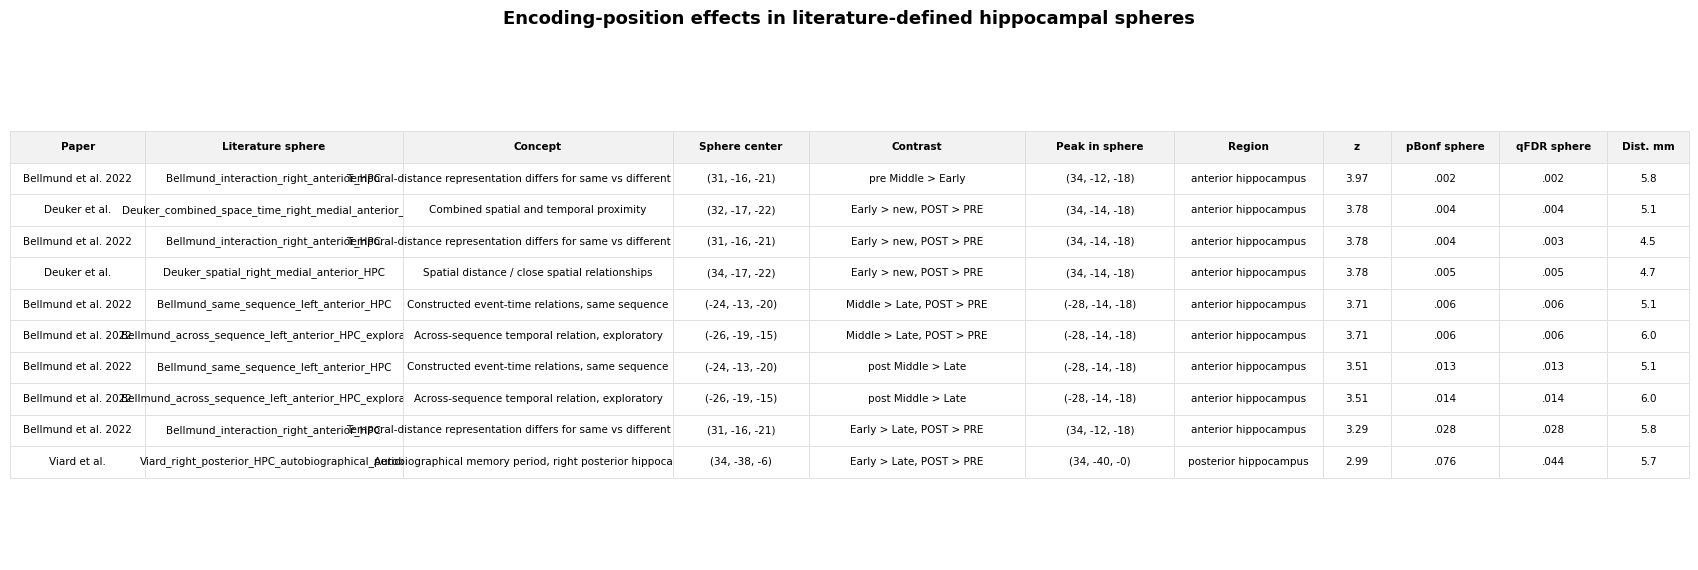

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/pre_post_encoding_space_early_middle_late_control_glm_SURVIVING_literature_defined_6mm_sphere_svc_table.png


In [18]:
# ============================================================
# Literature-defined 6 mm hippocampal sphere SVC
# Notebook 11: PRE/POST encoding-position early/middle/late GLM
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from nilearn import plotting
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

literature_svc_dir = (
    dirs["tables"]
    / "literature_6mm_spheres_encoding_position"
)
literature_svc_dir.mkdir(parents=True, exist_ok=True)

literature_fig_dir = (
    dirs["figures"]
    / "literature_6mm_spheres_encoding_position"
)
literature_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving literature SVC tables to:", literature_svc_dir)
print("Saving literature SVC figures to:", literature_fig_dir)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

LITERATURE_SPHERE_RADIUS_MM = 6.0
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

# ------------------------------------------------------------
# Literature coordinates
# ------------------------------------------------------------
# Same coordinate set used for Notebook 10, with Deuker/Bellmund particularly relevant here.
# Coordinates are MNI.

LITERATURE_CENTERS = [
    # Deuker et al. — directly relevant for spatial/temporal event maps
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_temporal_right_medial_anterior_HPC",
        "concept": "Temporal distance / close temporal relationships",
        "x": 26.0,
        "y": -18.0,
        "z": -22.0,
        "priority": "temporal_event_map",
    },
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_spatial_right_medial_anterior_HPC",
        "concept": "Spatial distance / close spatial relationships",
        "x": 34.0,
        "y": -17.0,
        "z": -22.0,
        "priority": "spatial_event_map",
    },
    {
        "paper": "Deuker et al.",
        "roi_name": "Deuker_combined_space_time_right_medial_anterior_HPC",
        "concept": "Combined spatial and temporal proximity",
        "x": 32.0,
        "y": -17.0,
        "z": -22.0,
        "priority": "space_time_event_map",
    },

    # Bellmund et al. 2022 — event-time / temporal structure
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_same_sequence_left_anterior_HPC",
        "concept": "Constructed event-time relations, same sequence",
        "x": -24.0,
        "y": -13.0,
        "z": -20.0,
        "priority": "temporal_structure",
    },
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_interaction_right_anterior_HPC",
        "concept": "Temporal-distance representation differs for same vs different sequences",
        "x": 31.0,
        "y": -16.0,
        "z": -21.0,
        "priority": "temporal_structure",
    },
    {
        "paper": "Bellmund et al. 2022",
        "roi_name": "Bellmund_across_sequence_left_anterior_HPC_exploratory",
        "concept": "Across-sequence temporal relation, exploratory",
        "x": -26.0,
        "y": -19.0,
        "z": -15.0,
        "priority": "temporal_structure",
    },

    # Montagrin et al. — temporal goal structure
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_current_gt_remote_left_posterior_HPC",
        "concept": "Current > remote goals",
        "x": -30.0,
        "y": -31.0,
        "z": -14.5,
        "priority": "temporal_goal_structure",
    },
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_remote_gt_current_left_anterior_HPC",
        "concept": "Remote > current goals",
        "x": -15.0,
        "y": -8.5,
        "z": -14.5,
        "priority": "temporal_goal_structure",
    },
    {
        "paper": "Montagrin et al.",
        "roi_name": "Montagrin_remote_gt_current_right_anterior_HPC",
        "concept": "Remote > current goals",
        "x": 17.5,
        "y": -21.0,
        "z": -14.5,
        "priority": "temporal_goal_structure",
    },

    # Viard et al. — autobiographical memory / posterior hippocampus
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_left_posterior_HPC_autobiographical_period",
        "concept": "Autobiographical memory period, left posterior hippocampus",
        "x": -30.0,
        "y": -26.0,
        "z": -12.0,
        "priority": "autobiographical_memory",
    },
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_right_posterior_HPC_autobiographical_period",
        "concept": "Autobiographical memory period, right posterior hippocampus",
        "x": 34.0,
        "y": -38.0,
        "z": -6.0,
        "priority": "autobiographical_memory",
    },
    {
        "paper": "Viard et al.",
        "roi_name": "Viard_right_posterior_HPC_autobiographical_period_secondary",
        "concept": "Autobiographical memory period, right posterior hippocampus secondary",
        "x": 14.0,
        "y": -38.0,
        "z": 2.0,
        "priority": "autobiographical_memory",
    },
]

literature_centers_df = pd.DataFrame(LITERATURE_CENTERS)
display(literature_centers_df)

# ------------------------------------------------------------
# Use all Notebook 11 contrasts
# ------------------------------------------------------------

assert "second_level_table" in globals(), "second_level_table not found. Run/load second-level maps first."
assert {"contrast", "z_map_path"}.issubset(second_level_table.columns), "second_level_table needs contrast and z_map_path columns."

all_contrasts_to_test = (
    second_level_table["contrast"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print(f"\nTesting {len(all_contrasts_to_test)} contrasts in {len(LITERATURE_CENTERS)} literature spheres:")
for c in all_contrasts_to_test:
    print(" -", c)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    """Create a binary MNI sphere mask on the grid of reference_img."""

    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def classify_hemisphere(x_coord):
    if x_coord < 0:
        return "left"
    if x_coord > 0:
        return "right"
    return "midline"


def classify_long_axis(y_coord):
    # Same rule as previous notebooks.
    if y_coord < -21:
        return "posterior hippocampus"
    return "anterior hippocampus"


def contrast_label(contrast):
    label = str(contrast)

    label = label.replace("_post_gt_pre", ", POST > PRE")
    label = label.replace("_pre", ", PRE")
    label = label.replace("_post", ", POST")

    label = label.replace("_gt_", " > ")
    label = label.replace("_", " ")

    label = label.replace("early", "Early")
    label = label.replace("middle", "Middle")
    label = label.replace("late", "Late")
    label = label.replace("new", "new")
    label = label.replace("encoding space old", "Old route-position images")
    return label


def run_sphere_svc(z_map_path, sphere_img, center_mni, direction="positive"):
    """Voxelwise Bonferroni/FDR SVC inside one fixed literature sphere."""

    z_img = load_img(str(z_map_path))

    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels after resampling."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be positive or negative.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))
    peak_q_fdr = float(q_values[peak_index])

    sphere_indices = np.array(np.where(sphere_data)).T
    sphere_xyz = nib.affines.apply_affine(z_img.affine, sphere_indices)

    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    center = np.array(center_mni, dtype=float)
    peak_distance_mm = float(np.linalg.norm(np.array(peak_mni) - center))

    # nearest voxel to literature center
    distances_to_center = np.linalg.norm(sphere_xyz - center, axis=1)
    nearest_index = int(np.argmin(distances_to_center))
    nearest_ijk = sphere_indices[nearest_index]
    nearest_mni = sphere_xyz[nearest_index]
    nearest_z = float(z_data[tuple(nearest_ijk)])
    nearest_p_unc = float(norm.sf(nearest_z)) if direction == "positive" else float(norm.sf(-nearest_z))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_distance_from_literature_center_mm": peak_distance_mm,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "nearest_center_x": float(nearest_mni[0]),
        "nearest_center_y": float(nearest_mni[1]),
        "nearest_center_z_coord": float(nearest_mni[2]),
        "nearest_center_z_stat": nearest_z,
        "nearest_center_p_uncorrected": nearest_p_unc,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_bonf_p_lt_0_05": int(np.sum((p_values * n_voxels) < 0.05)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)

# ------------------------------------------------------------
# Run literature SVC search
# ------------------------------------------------------------

reference_z_map_path = Path(
    second_level_table.loc[
        second_level_table["contrast"] == all_contrasts_to_test[0],
        "z_map_path",
    ].iloc[0]
)
reference_img = load_img(str(reference_z_map_path))

svc_rows = []

for center in LITERATURE_CENTERS:

    center_mni = (float(center["x"]), float(center["y"]), float(center["z"]))

    sphere_img = make_sphere_mask_img(
        reference_img=reference_img,
        center_mni=center_mni,
        radius_mm=LITERATURE_SPHERE_RADIUS_MM,
    )

    sphere_mask_path = (
        literature_svc_dir
        / f"{center['roi_name']}_radius-{LITERATURE_SPHERE_RADIUS_MM:.1f}mm_mask.nii.gz"
    )
    sphere_img.to_filename(str(sphere_mask_path))

    print(f"\nSphere: {center['paper']} | {center['roi_name']} | center={center_mni}")

    for contrast_name in all_contrasts_to_test:

        z_map_path = Path(
            second_level_table.loc[
                second_level_table["contrast"] == contrast_name,
                "z_map_path",
            ].iloc[0]
        )

        res = run_sphere_svc(
            z_map_path=z_map_path,
            sphere_img=sphere_img,
            center_mni=center_mni,
            direction="positive",
        )

        res.update({
            "paper": center["paper"],
            "literature_roi": center["roi_name"],
            "concept": center["concept"],
            "priority": center["priority"],
            "contrast": contrast_name,
            "contrast_label": contrast_label(contrast_name),
            "sphere_center_x": center["x"],
            "sphere_center_y": center["y"],
            "sphere_center_z": center["z"],
            "sphere_radius_mm": LITERATURE_SPHERE_RADIUS_MM,
            "sphere_mask_path": str(sphere_mask_path),
            "z_map_path": str(z_map_path),
            "peak_hemisphere_from_x": classify_hemisphere(res["peak_x"]),
            "peak_long_axis_zone": classify_long_axis(res["peak_y"]),
        })

        svc_rows.append(res)

encoding_literature_svc_table = pd.DataFrame(svc_rows)

# Optional corrections across contrasts and all tests are saved for transparency,
# but the main reporting criterion here is pBonf/qFDR within the 6 mm literature sphere.
encoding_literature_svc_table["p_bonf_sphere_x_contrasts_within_literature_roi"] = np.nan
encoding_literature_svc_table["q_fdr_across_contrasts_within_literature_roi"] = np.nan

for roi_name, idx in encoding_literature_svc_table.groupby("literature_roi").groups.items():
    idx = list(idx)
    n_tests = len(idx)

    encoding_literature_svc_table.loc[idx, "p_bonf_sphere_x_contrasts_within_literature_roi"] = (
        encoding_literature_svc_table.loc[idx, "peak_p_uncorrected"]
        * encoding_literature_svc_table.loc[idx, "n_voxels_in_sphere"]
        * n_tests
    ).clip(upper=1.0)

    _, qvals, _, _ = multipletests(
        encoding_literature_svc_table.loc[idx, "peak_p_bonferroni_within_sphere"].values,
        alpha=0.05,
        method="fdr_bh",
    )
    encoding_literature_svc_table.loc[idx, "q_fdr_across_contrasts_within_literature_roi"] = qvals

n_all_tests = len(encoding_literature_svc_table)

encoding_literature_svc_table["p_bonf_all_literature_sphere_tests"] = (
    encoding_literature_svc_table["peak_p_uncorrected"]
    * encoding_literature_svc_table["n_voxels_in_sphere"]
    * n_all_tests
).clip(upper=1.0)

_, q_all, _, _ = multipletests(
    encoding_literature_svc_table["peak_p_bonferroni_within_sphere"].values,
    alpha=0.05,
    method="fdr_bh",
)
encoding_literature_svc_table["q_fdr_all_literature_sphere_tests"] = q_all

encoding_literature_svc_table = encoding_literature_svc_table.sort_values(
    ["peak_p_bonferroni_within_sphere", "peak_z_stat"],
    ascending=[True, False],
).reset_index(drop=True)

full_svc_path = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_literature_defined_6mm_sphere_svc_ALL_contrasts.csv"
)
encoding_literature_svc_table.to_csv(full_svc_path, index=False)

print("\nSaved full literature SVC table:")
print(full_svc_path)

display(encoding_literature_svc_table.head(30))

# ------------------------------------------------------------
# Clean table: all results surviving within-sphere correction
# ------------------------------------------------------------

encoding_svc_survivors = encoding_literature_svc_table[
    (
        encoding_literature_svc_table["peak_p_bonferroni_within_sphere"] < 0.05
    )
    | (
        encoding_literature_svc_table["peak_q_fdr_within_sphere"] < 0.05
    )
].copy()

encoding_svc_survivors = encoding_svc_survivors.sort_values(
    ["peak_p_bonferroni_within_sphere", "peak_z_stat"],
    ascending=[True, False],
).reset_index(drop=True)

clean_rows = []

for _, row in encoding_svc_survivors.iterrows():
    clean_rows.append({
        "Paper": row["paper"],
        "Literature sphere": row["literature_roi"],
        "Concept": row["concept"],
        "Sphere center": fmt_coord(
            row["sphere_center_x"],
            row["sphere_center_y"],
            row["sphere_center_z"],
        ),
        "Contrast": row["contrast_label"],
        "Peak in sphere": fmt_coord(
            row["peak_x"],
            row["peak_y"],
            row["peak_z_coord"],
        ),
        "Region": row["peak_long_axis_zone"],
        "z": f"{row['peak_z_stat']:.2f}",
        "pBonf sphere": fmt_p(row["peak_p_bonferroni_within_sphere"]),
        "qFDR sphere": fmt_p(row["peak_q_fdr_within_sphere"]),
        "Dist. mm": f"{row['peak_distance_from_literature_center_mm']:.1f}",
    })

encoding_svc_survivors_clean = pd.DataFrame(clean_rows)

survivors_csv = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_SURVIVING_literature_defined_6mm_sphere_svc.csv"
)
encoding_svc_survivors.to_csv(survivors_csv, index=False)

survivors_clean_csv = (
    literature_svc_dir
    / f"{ANALYSIS_NAME}_SURVIVING_literature_defined_6mm_sphere_svc_clean.csv"
)
encoding_svc_survivors_clean.to_csv(survivors_clean_csv, index=False)

print("\nSurviving literature-sphere results:")
display(encoding_svc_survivors_clean)

print("Saved survivors:")
print(survivors_csv)
print(survivors_clean_csv)

if len(encoding_svc_survivors_clean) > 0:
    survivors_png = (
        literature_fig_dir
        / f"{ANALYSIS_NAME}_SURVIVING_literature_defined_6mm_sphere_svc_table.png"
    )

    save_clean_table_png(
        encoding_svc_survivors_clean,
        survivors_png,
        title="Encoding-position effects in literature-defined hippocampal spheres",
        fontsize=7.5,
        header_fontsize=7.5,
        scale_y=1.65,
        col_widths=[0.10, 0.19, 0.20, 0.10, 0.16, 0.11, 0.11, 0.05, 0.08, 0.08, 0.06],
        figsize=(17, max(3.2, 0.42 * len(encoding_svc_survivors_clean) + 1.6)),
    )
else:
    print("No within-sphere-corrected survivors found.")

Saving POST > PRE exploration tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_exploration
Saving POST > PRE exploration figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_exploration

POST > PRE contrasts found:
 - early_gt_new_post_gt_pre
 - middle_gt_new_post_gt_pre
 - late_gt_new_post_gt_pre
 - encoding_time_old_gt_new_post_gt_pre
 - early_gt_middle_post_gt_pre
 - middle_gt_early_post_gt_pre
 - early_gt_late_post_gt_pre
 - late_gt_early_post_gt_pre
 - middle_gt_late_post_gt_pre
 - late_gt_middle_post_gt_pre

TABLE 1 — POST > PRE effects close to current literature peaks


,Contrast,Peak,Region,z,qFDR sphere,pBonf sphere,Literature match,Papers,Concepts,Min dist. mm,Use
0,"Early > new, POST > PRE","(34, -14, -18)",right anterior hippocampus,3.78,.003–.005,.004–.005,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC,Bellmund et al. 2022 + Deuker et al.,Combined spatial and temporal proximity; Spatial distance / close spatial relationships; Temporal-distance representation differs for same vs different sequences,4.5,FDR-supported
1,"Middle > Late, POST > PRE","(-28, -14, -18)",left anterior hippocampus,3.71,.006–.006,.006–.006,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC,Bellmund et al. 2022,"Across-sequence temporal relation, exploratory; Constructed event-time relations, same sequence",5.1,FDR-supported
2,"Early > Late, POST > PRE","(34, -12, -18)",right anterior hippocampus,3.29,.028,.028,Bellmund interaction R anterior HPC,Bellmund et al. 2022,Temporal-distance representation differs for same vs different sequences,5.8,FDR-supported
3,"Early > Late, POST > PRE","(34, -40, -0)",right posterior hippocampus,2.99,.044,.076,Viard R posterior HPC,Viard et al.,"Autobiographical memory period, right posterior hippocampus",5.7,FDR-supported
4,"Old > new, POST > PRE","(-14, -12, -10)",left anterior hippocampus,3.01,.070,.074,Montagrin L anterior HPC,Montagrin et al.,Remote > current goals,5.5,Exploratory z≥3


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_literature_close_exploratory_summary.csv


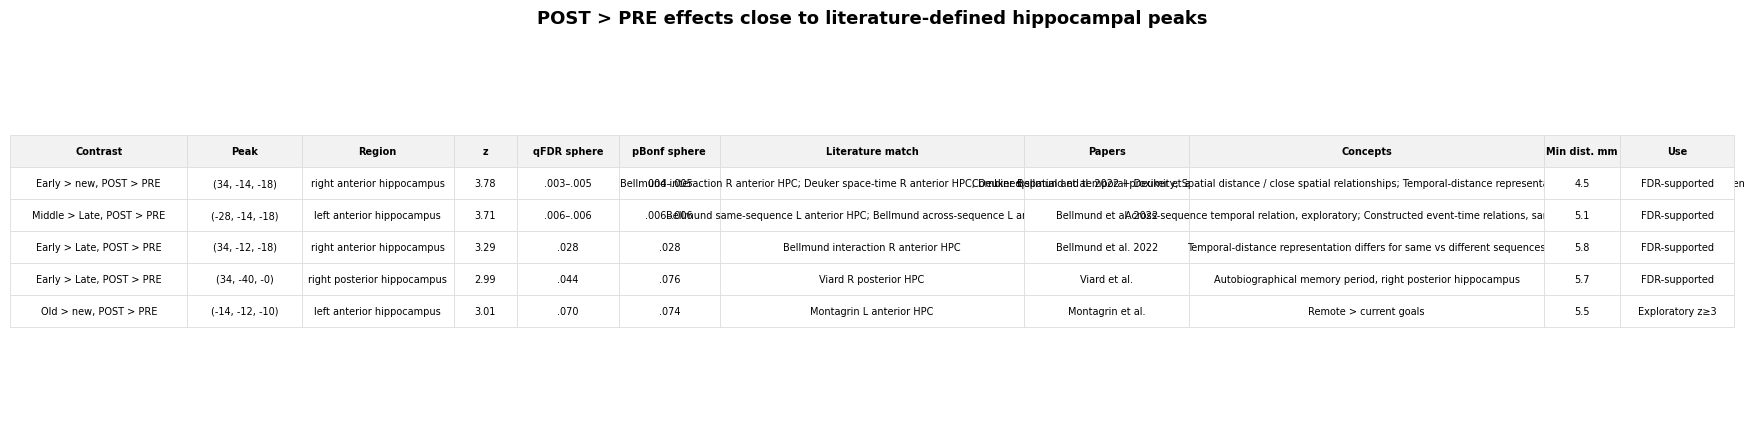

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_literature_close_exploratory_summary.png

Extracting whole-brain peaks for early_gt_new_post_gt_pre
z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/group_early_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz

Extracting whole-brain peaks for middle_gt_new_post_gt_pre
z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/group_middle_gt_new_post_gt_pre_smoothed5mm_zmap.nii.gz

Extracting whole-brain peaks for late_gt_new_post_gt_pre
z-map: /media/

,contrast,Contrast,Peak,x,y,z_coord,Peak z,Cluster size,Hemisphere,HPC axis heuristic,Nearest literature sphere,Nearest paper,Nearest center,Distance to nearest literature center mm,Close to current literature?
0,early_gt_new_post_gt_pre,"Early > new, POST > PRE","(-8, 3, -10)",-8.5,3.0,-10.5,4.533857,93.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",13.802174,False
1,early_gt_new_post_gt_pre,"Early > new, POST > PRE","(42, -7, -20)",41.5,-7.0,-20.5,4.215716,78.0,right,anterior,Deuker spatial R anterior HPC,Deuker et al.,"(34, -17, -22)",12.589678,False
2,early_gt_new_post_gt_pre,"Early > new, POST > PRE","(-14, 26, 2)",-13.5,25.5,2.0,3.263283,78.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",37.821951,False
3,early_gt_new_post_gt_pre,"Early > new, POST > PRE","(-28, 30, 7)",-28.5,30.5,7.0,3.203561,78.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",46.534933,False
4,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(-24, 0, 62)",-23.5,0.5,62.0,4.270018,93.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",77.495161,False
5,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(62, -40, -16)",61.5,-39.5,-15.5,3.997941,109.0,right,posterior,Viard R posterior HPC,Viard et al.,"(34, -38, -6)",29.133314,False
6,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(-36, -52, -0)",-36.0,-52.0,-0.5,3.700812,78.0,left,posterior,Montagrin L posterior HPC,Montagrin et al.,"(-30, -31, -14)",25.942244,False
7,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(29, 33, 27)",29.0,33.0,27.0,3.574114,140.0,right,anterior,Bellmund interaction R anterior HPC,Bellmund et al. 2022,"(31, -16, -21)",68.622154,False
8,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(9, -47, -46)",9.0,-47.0,-45.5,3.567663,109.0,right,posterior,Deuker temporal R anterior HPC,Deuker et al.,"(26, -18, -22)",41.015241,False
9,middle_gt_new_post_gt_pre,"Middle > new, POST > PRE","(19, 10, 64)",19.0,10.5,64.5,3.530870,93.0,right,anterior,Viard R posterior HPC secondary,Viard et al.,"(14, -38, 2)",79.268531,False


Saved all whole-brain peaks:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_wholebrain_peaks_z3.00_ALL.csv

TABLE 2 — Strong POST > PRE peaks NOT close to current literature peaks


,Contrast,Peak,Peak z,Cluster size,Hemisphere,HPC axis heuristic,Nearest literature sphere,Nearest paper,Nearest center,Distance to nearest literature center mm
0,"Early > Late, POST > PRE","(-38, -7, 24)",5.11,234,left,anterior,Viard L posterior HPC,Viard et al.,"(-30, -26, -12)",42.0
1,"Late > Middle, POST > PRE","(-11, -64, 27)",4.57,109,left,posterior,Viard R posterior HPC secondary,Viard et al.,"(14, -38, 2)",44.2
2,"Early > new, POST > PRE","(-8, 3, -10)",4.53,93.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",13.8
3,"Late > new, POST > PRE","(6, 40, 37)",4.50,125.0,right,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",74.3
4,"Middle > Early, POST > PRE","(-28, -64, -28)",4.41,78.0,left,posterior,Montagrin L posterior HPC,Montagrin et al.,"(-30, -31, -14)",36.1
5,"Middle > new, POST > PRE","(-24, 0, 62)",4.27,93.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",77.5
6,"Early > new, POST > PRE","(42, -7, -20)",4.22,78.0,right,anterior,Deuker spatial R anterior HPC,Deuker et al.,"(34, -17, -22)",12.6
7,"Early > Late, POST > PRE","(-8, 23, 4)",4.11,187,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",37.4
8,"Late > Middle, POST > PRE","(6, -50, -6)",4.09,203,right,posterior,Viard R posterior HPC secondary,Viard et al.,"(14, -38, 2)",15.6
9,"Late > Early, POST > PRE","(54, 16, 4)",4.05,187.0,right,anterior,Deuker spatial R anterior HPC,Deuker et al.,"(34, -17, -22)",46.5


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_strong_peaks_NOT_close_to_current_literature.csv


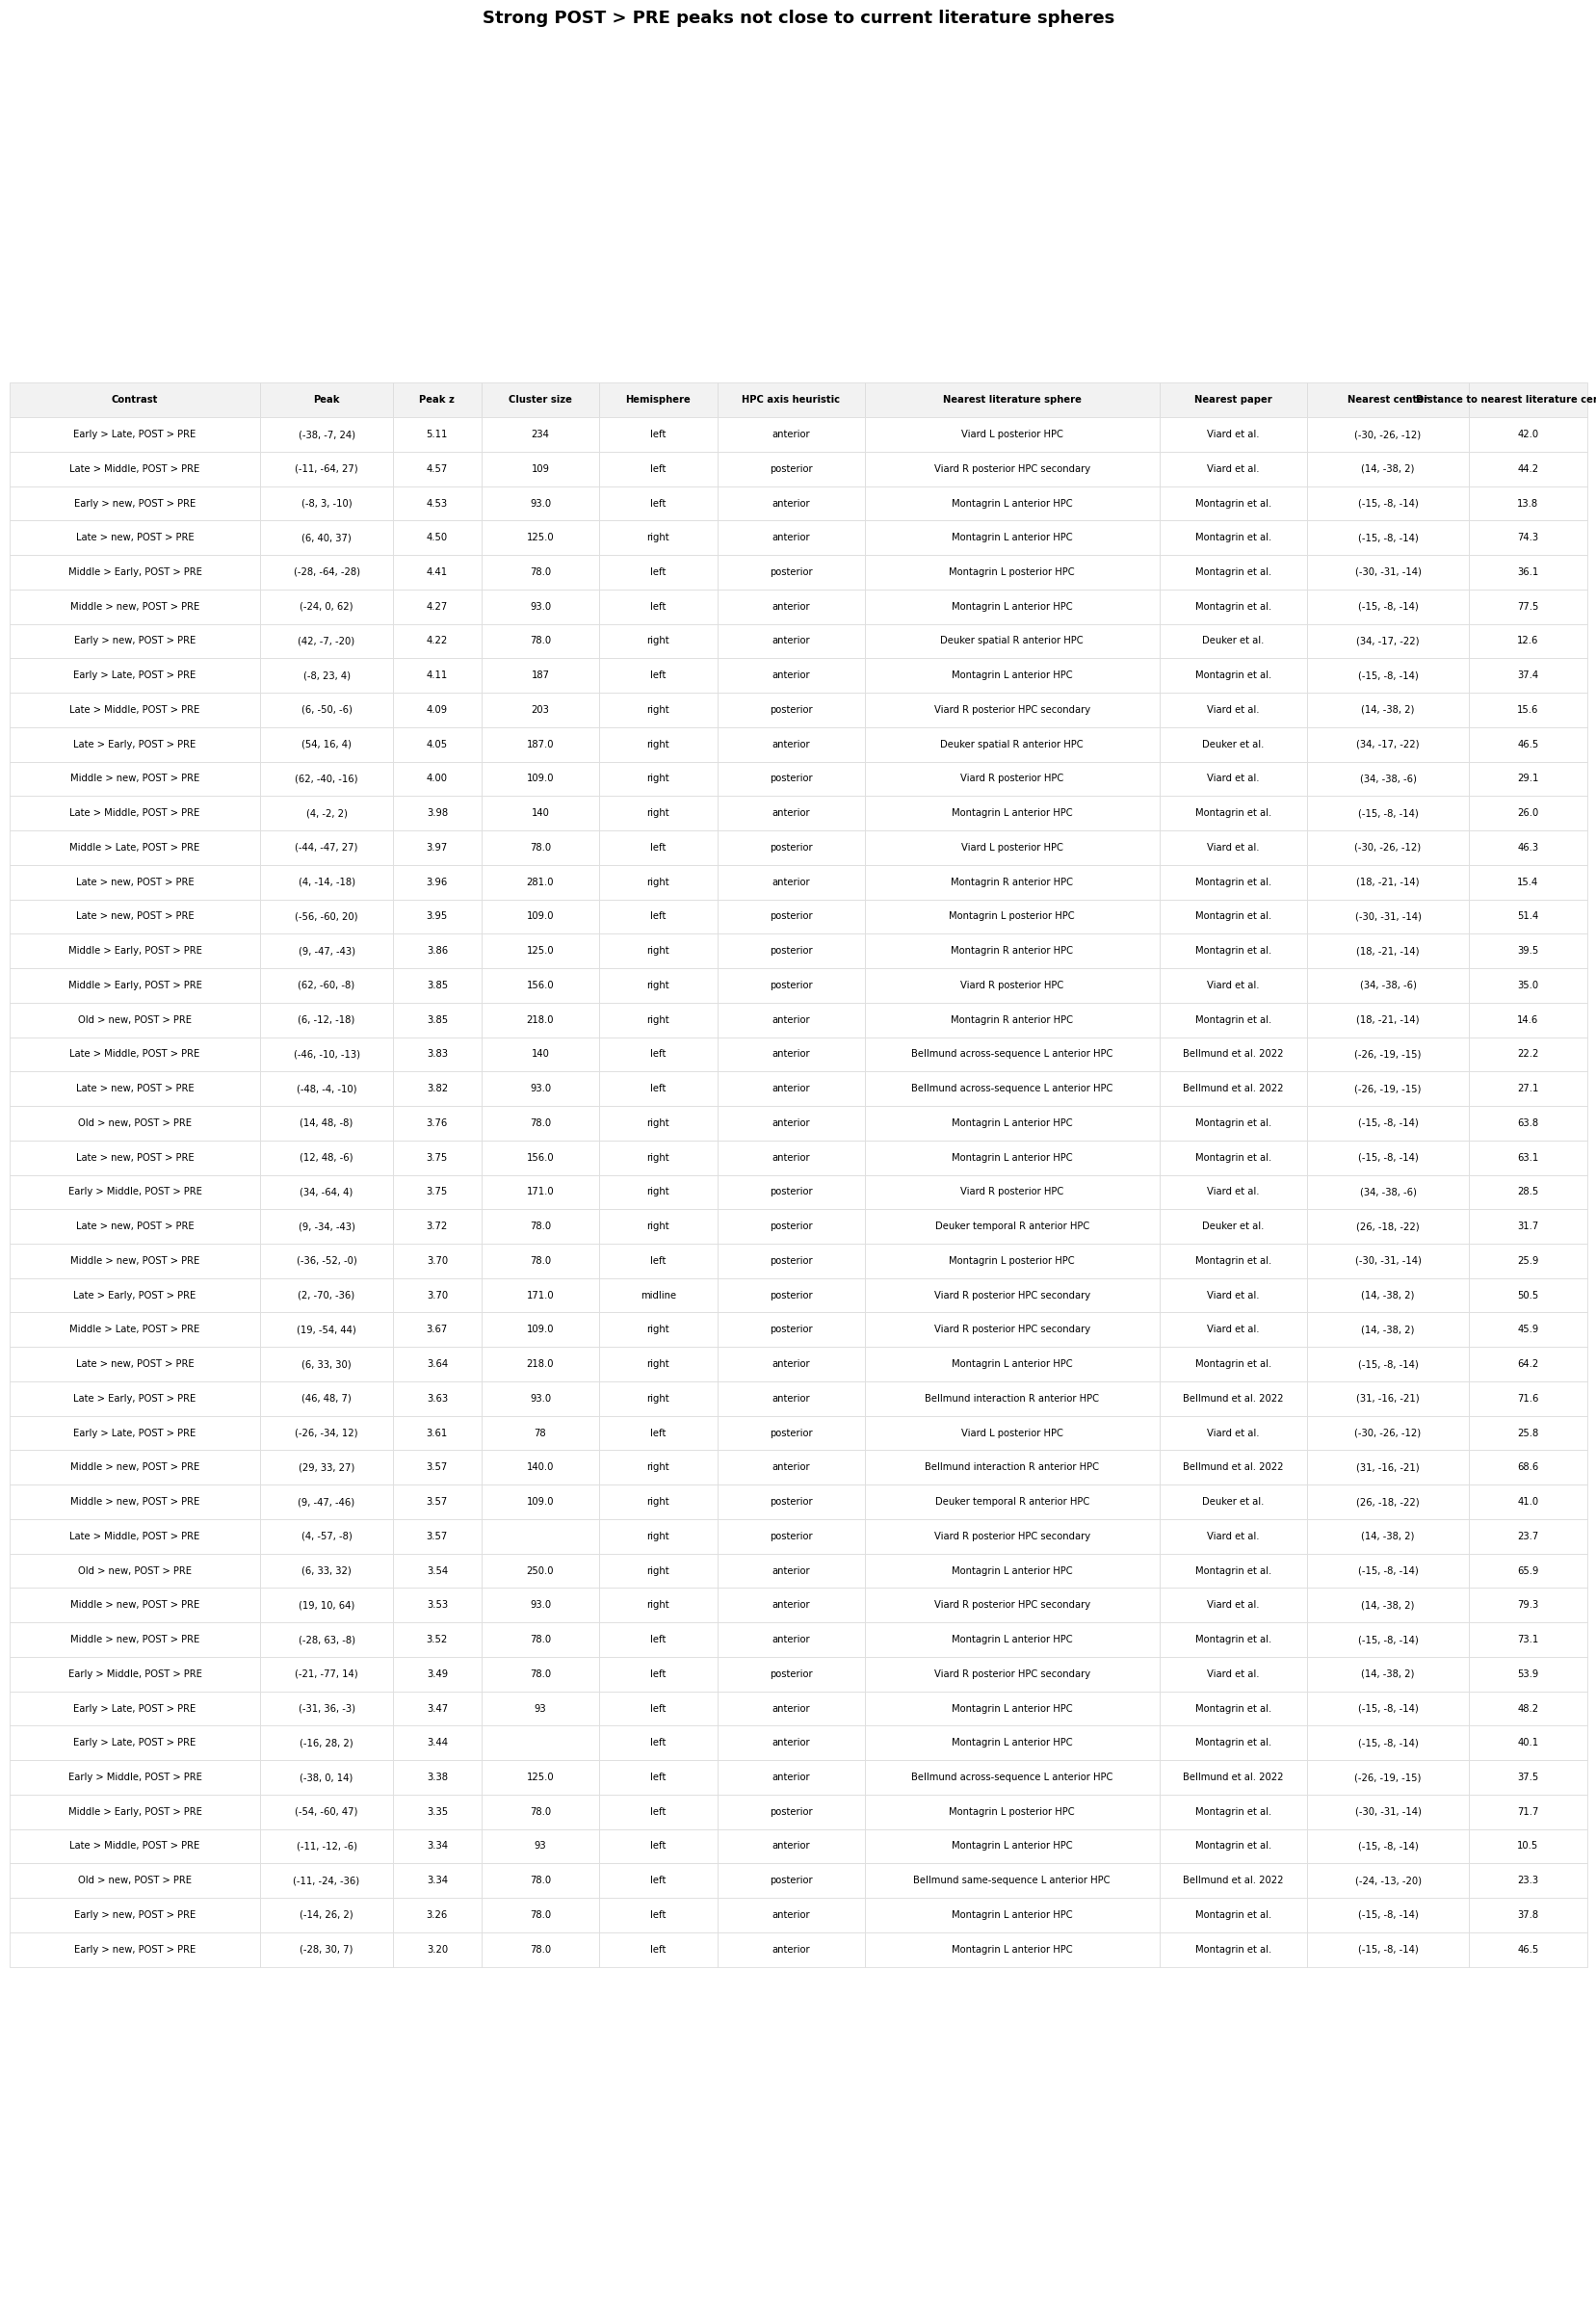

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_strong_peaks_NOT_close_to_current_literature.png

Interpretation guide:
- Table 1 keeps POST > PRE sphere effects with qFDR < 0.05 or z >= 3.0.
- Table 2 lists whole-brain POST > PRE peaks with z >= 3.0 and cluster size >= 5 voxels.
- A peak is considered unmatched if it is > 8.0 mm from every current literature sphere center.
- Use Table 2 coordinates to decide where to search for additional papers.

Key objects created:
- post_pre_literature_summary
- wholebrain_peaks
- unmatched_summary


In [22]:
# ============================================================
# Exploratory POST > PRE summary:
# 1) POST > PRE effects close to literature-defined hippocampal peaks
# 2) Strong POST > PRE peaks not explained by current literature spheres
#
# This cell is exploratory:
# - Focuses only on POST > PRE contrasts
# - Uses qFDR within sphere and z-threshold, not Bonferroni as a hard cutoff
# - Produces two clean tables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img
from nilearn.reporting import get_clusters_table
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

explore_dir = (
    dirs["tables"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_exploration"
)

explore_fig_dir = (
    dirs["figures"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_exploration"
)

explore_dir.mkdir(parents=True, exist_ok=True)
explore_fig_dir.mkdir(parents=True, exist_ok=True)

print("Saving POST > PRE exploration tables to:", explore_dir)
print("Saving POST > PRE exploration figures to:", explore_fig_dir)

# ------------------------------------------------------------
# Exploration settings
# ------------------------------------------------------------

# Table 1:
# Keep literature-sphere effects if they are FDR-significant inside the sphere
# OR if the local peak is at least z >= 3.0.
QFDR_THRESHOLD = 0.05
EXPLORATORY_Z_THRESHOLD_INSIDE_SPHERE = 3.00

# Table 2:
# Whole-brain peaks used to discover strong coordinates not already covered
# by the current literature spheres.
WHOLE_BRAIN_Z_THRESHOLD = 3.00
MIN_CLUSTER_SIZE_VOXELS = 5

# Distance to current literature centers.
# <= 8 mm = reasonably close to an existing literature coordinate.
LITERATURE_MATCH_DISTANCE_MM = 8.0

# Merge literature-sphere rows that are essentially the same observed effect.
PEAK_MERGE_DISTANCE_MM = 6.0

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert "encoding_literature_svc_table" in globals(), "Run the literature SVC search cell first."
assert "literature_centers_df" in globals(), "literature_centers_df not found."
assert "second_level_table" in globals(), "second_level_table not found."
assert "ANALYSIS_NAME" in globals(), "ANALYSIS_NAME not found."

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_p_explore(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord_explore(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def classify_hemisphere_explore(x):
    if x < -2:
        return "left"
    if x > 2:
        return "right"
    return "midline"


def classify_hpc_axis_explore(y):
    # Readability heuristic only.
    return "posterior" if y < -21 else "anterior"


def euclidean_distance_explore(a, b):
    return float(np.linalg.norm(np.array(a, dtype=float) - np.array(b, dtype=float)))


def make_contrast_label_explore(contrast_name):
    """
    Robust contrast label function.
    Named safely to avoid conflict with any notebook variable called contrast_label.
    """
    label = str(contrast_name)

    replacements = {
        "early_gt_new_post_gt_pre": "Early > new, POST > PRE",
        "middle_gt_new_post_gt_pre": "Middle > new, POST > PRE",
        "late_gt_new_post_gt_pre": "Late > new, POST > PRE",
        "encoding_time_old_gt_new_post_gt_pre": "Old > new, POST > PRE",
        "early_gt_middle_post_gt_pre": "Early > Middle, POST > PRE",
        "middle_gt_early_post_gt_pre": "Middle > Early, POST > PRE",
        "early_gt_late_post_gt_pre": "Early > Late, POST > PRE",
        "late_gt_early_post_gt_pre": "Late > Early, POST > PRE",
        "middle_gt_late_post_gt_pre": "Middle > Late, POST > PRE",
        "late_gt_middle_post_gt_pre": "Late > Middle, POST > PRE",
    }

    if label in replacements:
        return replacements[label]

    label = label.replace("_post_gt_pre", ", POST > PRE")
    label = label.replace("_gt_", " > ")
    label = label.replace("_", " ")

    label = label.replace("early", "Early")
    label = label.replace("middle", "Middle")
    label = label.replace("late", "Late")
    label = label.replace("new", "new")
    label = label.replace("encoding time old", "Old")

    return label


def nearest_literature_center_explore(coord, literature_df):
    distances = []

    for _, row in literature_df.iterrows():
        center = (row["x"], row["y"], row["z"])
        distances.append(euclidean_distance_explore(coord, center))

    nearest_idx = int(np.argmin(distances))
    nearest = literature_df.iloc[nearest_idx]

    return {
        "nearest_paper": nearest["paper"],
        "nearest_literature_sphere": nearest["roi_name"],
        "nearest_concept": nearest["concept"],
        "nearest_center": (nearest["x"], nearest["y"], nearest["z"]),
        "nearest_distance_mm": float(distances[nearest_idx]),
    }


def short_sphere_name_explore(roi):
    roi = str(roi)

    replacements = {
        "Deuker_temporal_right_medial_anterior_HPC": "Deuker temporal R anterior HPC",
        "Deuker_spatial_right_medial_anterior_HPC": "Deuker spatial R anterior HPC",
        "Deuker_combined_space_time_right_medial_anterior_HPC": "Deuker space-time R anterior HPC",
        "Bellmund_same_sequence_left_anterior_HPC": "Bellmund same-sequence L anterior HPC",
        "Bellmund_interaction_right_anterior_HPC": "Bellmund interaction R anterior HPC",
        "Bellmund_across_sequence_left_anterior_HPC_exploratory": "Bellmund across-sequence L anterior HPC",
        "Montagrin_current_gt_remote_left_posterior_HPC": "Montagrin L posterior HPC",
        "Montagrin_remote_gt_current_left_anterior_HPC": "Montagrin L anterior HPC",
        "Montagrin_remote_gt_current_right_anterior_HPC": "Montagrin R anterior HPC",
        "Viard_left_posterior_HPC_autobiographical_period": "Viard L posterior HPC",
        "Viard_right_posterior_HPC_autobiographical_period": "Viard R posterior HPC",
        "Viard_right_posterior_HPC_autobiographical_period_secondary": "Viard R posterior HPC secondary",
    }

    return replacements.get(roi, roi)


def save_clean_table_png_explore(
    df,
    out_path,
    title=None,
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)

# ------------------------------------------------------------
# Identify POST > PRE contrasts
# ------------------------------------------------------------

post_pre_contrasts = (
    second_level_table["contrast"]
    .dropna()
    .astype(str)
    .loc[lambda s: s.str.contains("post_gt_pre", case=False, regex=False)]
    .unique()
    .tolist()
)

print("\nPOST > PRE contrasts found:")
for c in post_pre_contrasts:
    print(" -", c)

# ============================================================
# TABLE 1:
# POST > PRE effects close to current literature peaks
# ============================================================

post_pre_svc = encoding_literature_svc_table[
    encoding_literature_svc_table["contrast"].isin(post_pre_contrasts)
].copy()

post_pre_svc["passes_fdr_sphere"] = (
    post_pre_svc["peak_q_fdr_within_sphere"] < QFDR_THRESHOLD
)

post_pre_svc["passes_exploratory_z"] = (
    post_pre_svc["peak_z_stat"] >= EXPLORATORY_Z_THRESHOLD_INSIDE_SPHERE
)

post_pre_svc["passes_exploratory_rule"] = (
    post_pre_svc["passes_fdr_sphere"]
    | post_pre_svc["passes_exploratory_z"]
)

post_pre_svc_hits = post_pre_svc[
    post_pre_svc["passes_exploratory_rule"]
].copy()

post_pre_svc_hits = post_pre_svc_hits.sort_values(
    ["contrast", "peak_q_fdr_within_sphere", "peak_z_stat"],
    ascending=[True, True, False],
).reset_index(drop=True)

# ------------------------------------------------------------
# Merge rows that are same contrast and similar observed peak
# ------------------------------------------------------------

merged_rows = []

for contrast_name, group in post_pre_svc_hits.groupby("contrast", sort=False):

    group = group.sort_values(
        ["peak_q_fdr_within_sphere", "peak_z_stat"],
        ascending=[True, False],
    ).reset_index(drop=True)

    used = np.zeros(len(group), dtype=bool)

    for i, row in group.iterrows():

        if used[i]:
            continue

        peak_i = np.array([
            row["peak_x"],
            row["peak_y"],
            row["peak_z_coord"],
        ], dtype=float)

        same_peak_indices = []

        for j, row_j in group.iterrows():

            if used[j]:
                continue

            peak_j = np.array([
                row_j["peak_x"],
                row_j["peak_y"],
                row_j["peak_z_coord"],
            ], dtype=float)

            if np.linalg.norm(peak_i - peak_j) <= PEAK_MERGE_DISTANCE_MM:
                same_peak_indices.append(j)

        peak_group = group.loc[same_peak_indices].copy()
        used[same_peak_indices] = True

        best = peak_group.sort_values(
            ["peak_q_fdr_within_sphere", "peak_z_stat"],
            ascending=[True, False],
        ).iloc[0]

        papers = " + ".join(sorted(peak_group["paper"].unique()))
        spheres = "; ".join(
            short_sphere_name_explore(x)
            for x in peak_group["literature_roi"].unique()
        )
        concepts = "; ".join(
            sorted(set(str(x) for x in peak_group["concept"].unique()))
        )

        p_min = peak_group["peak_p_bonferroni_within_sphere"].min()
        p_max = peak_group["peak_p_bonferroni_within_sphere"].max()
        q_min = peak_group["peak_q_fdr_within_sphere"].min()
        q_max = peak_group["peak_q_fdr_within_sphere"].max()

        p_range = (
            fmt_p_explore(p_min)
            if np.isclose(p_min, p_max)
            else f"{fmt_p_explore(p_min)}–{fmt_p_explore(p_max)}"
        )

        q_range = (
            fmt_p_explore(q_min)
            if np.isclose(q_min, q_max)
            else f"{fmt_p_explore(q_min)}–{fmt_p_explore(q_max)}"
        )

        use_label = (
            "FDR-supported"
            if best["peak_q_fdr_within_sphere"] < QFDR_THRESHOLD
            else "Exploratory z≥3"
        )

        merged_rows.append({
            "Contrast": make_contrast_label_explore(best["contrast"]),
            "Peak": fmt_coord_explore(
                best["peak_x"],
                best["peak_y"],
                best["peak_z_coord"],
            ),
            "Region": (
                f"{classify_hemisphere_explore(best['peak_x'])} "
                f"{classify_hpc_axis_explore(best['peak_y'])} hippocampus"
            ),
            "z": f"{best['peak_z_stat']:.2f}",
            "qFDR sphere": q_range,
            "pBonf sphere": p_range,
            "Literature match": spheres,
            "Papers": papers,
            "Concepts": concepts,
            "Min dist. mm": f"{peak_group['peak_distance_from_literature_center_mm'].min():.1f}",
            "Use": use_label,
        })

post_pre_literature_summary = pd.DataFrame(merged_rows)

if len(post_pre_literature_summary) > 0:
    post_pre_literature_summary["_z_float"] = post_pre_literature_summary["z"].astype(float)
    post_pre_literature_summary["_use_order"] = post_pre_literature_summary["Use"].map({
        "FDR-supported": 0,
        "Exploratory z≥3": 1,
    }).fillna(2)

    post_pre_literature_summary = post_pre_literature_summary.sort_values(
        ["_use_order", "_z_float"],
        ascending=[True, False],
    ).drop(columns=["_z_float", "_use_order"]).reset_index(drop=True)

post_pre_lit_csv = (
    explore_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_literature_close_exploratory_summary.csv"
)

post_pre_literature_summary.to_csv(post_pre_lit_csv, index=False)

print("\nTABLE 1 — POST > PRE effects close to current literature peaks")
display(post_pre_literature_summary)

print("Saved:")
print(post_pre_lit_csv)

if len(post_pre_literature_summary) > 0:
    post_pre_lit_png = (
        explore_fig_dir
        / f"{ANALYSIS_NAME}_POST_GT_PRE_literature_close_exploratory_summary.png"
    )

    save_clean_table_png_explore(
        post_pre_literature_summary,
        post_pre_lit_png,
        title="POST > PRE effects close to literature-defined hippocampal peaks",
        fontsize=7.0,
        header_fontsize=7.0,
        scale_y=1.75,
        col_widths=[0.14, 0.09, 0.12, 0.05, 0.08, 0.08, 0.24, 0.13, 0.28, 0.06, 0.09],
        figsize=(18, max(3.4, 0.55 * len(post_pre_literature_summary) + 1.6)),
    )

# ============================================================
# TABLE 2:
# Strong POST > PRE whole-brain peaks not close to current literature centers
# ============================================================

wholebrain_peak_rows = []

for contrast_name in post_pre_contrasts:

    z_map_path = Path(
        second_level_table.loc[
            second_level_table["contrast"] == contrast_name,
            "z_map_path",
        ].iloc[0]
    )

    z_img = load_img(str(z_map_path))

    print(f"\nExtracting whole-brain peaks for {contrast_name}")
    print("z-map:", z_map_path)

    try:
        clusters = get_clusters_table(
            z_img,
            stat_threshold=WHOLE_BRAIN_Z_THRESHOLD,
            cluster_threshold=MIN_CLUSTER_SIZE_VOXELS,
            two_sided=False,
        )
    except TypeError:
        clusters = get_clusters_table(
            z_img,
            stat_threshold=WHOLE_BRAIN_Z_THRESHOLD,
            cluster_threshold=MIN_CLUSTER_SIZE_VOXELS,
        )

    if clusters is None or len(clusters) == 0:
        print("No clusters found.")
        continue

    clusters = clusters.copy()

    if not {"X", "Y", "Z"}.issubset(clusters.columns):
        raise ValueError(
            "Could not find X/Y/Z columns in get_clusters_table output. "
            f"Columns were: {clusters.columns.tolist()}"
        )

    for _, cluster_row in clusters.iterrows():

        peak_coord = (
            float(cluster_row["X"]),
            float(cluster_row["Y"]),
            float(cluster_row["Z"]),
        )

        if "Peak Stat" in clusters.columns:
            peak_stat = float(cluster_row["Peak Stat"])
        elif "Stat" in clusters.columns:
            peak_stat = float(cluster_row["Stat"])
        else:
            peak_stat = np.nan

        if "Cluster Size (mm3)" in clusters.columns:
            cluster_size = cluster_row["Cluster Size (mm3)"]
        elif "Cluster Size" in clusters.columns:
            cluster_size = cluster_row["Cluster Size"]
        elif "Cluster Size (voxels)" in clusters.columns:
            cluster_size = cluster_row["Cluster Size (voxels)"]
        else:
            cluster_size = np.nan

        nearest = nearest_literature_center_explore(
            coord=peak_coord,
            literature_df=literature_centers_df,
        )

        is_close_to_literature = (
            nearest["nearest_distance_mm"] <= LITERATURE_MATCH_DISTANCE_MM
        )

        wholebrain_peak_rows.append({
            "contrast": contrast_name,
            "Contrast": make_contrast_label_explore(contrast_name),
            "Peak": fmt_coord_explore(*peak_coord),
            "x": peak_coord[0],
            "y": peak_coord[1],
            "z_coord": peak_coord[2],
            "Peak z": peak_stat,
            "Cluster size": cluster_size,
            "Hemisphere": classify_hemisphere_explore(peak_coord[0]),
            "HPC axis heuristic": classify_hpc_axis_explore(peak_coord[1]),
            "Nearest literature sphere": short_sphere_name_explore(nearest["nearest_literature_sphere"]),
            "Nearest paper": nearest["nearest_paper"],
            "Nearest center": fmt_coord_explore(*nearest["nearest_center"]),
            "Distance to nearest literature center mm": nearest["nearest_distance_mm"],
            "Close to current literature?": is_close_to_literature,
        })

wholebrain_peaks = pd.DataFrame(wholebrain_peak_rows)

wholebrain_all_csv = (
    explore_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_wholebrain_peaks_z{WHOLE_BRAIN_Z_THRESHOLD:.2f}_ALL.csv"
)

wholebrain_peaks.to_csv(wholebrain_all_csv, index=False)

print("\nAll POST > PRE whole-brain peaks:")
display(wholebrain_peaks)

print("Saved all whole-brain peaks:")
print(wholebrain_all_csv)

# ------------------------------------------------------------
# Strong peaks NOT close to current literature coordinates
# ------------------------------------------------------------

if len(wholebrain_peaks) > 0:

    unmatched_peaks = wholebrain_peaks[
        ~wholebrain_peaks["Close to current literature?"]
    ].copy()

    unmatched_peaks = unmatched_peaks.sort_values(
        ["Peak z", "Distance to nearest literature center mm"],
        ascending=[False, False],
    ).reset_index(drop=True)

    unmatched_summary = unmatched_peaks[
        [
            "Contrast",
            "Peak",
            "Peak z",
            "Cluster size",
            "Hemisphere",
            "HPC axis heuristic",
            "Nearest literature sphere",
            "Nearest paper",
            "Nearest center",
            "Distance to nearest literature center mm",
        ]
    ].copy()

    unmatched_summary["Peak z"] = unmatched_summary["Peak z"].map(
        lambda x: f"{x:.2f}" if pd.notna(x) else "—"
    )

    unmatched_summary["Distance to nearest literature center mm"] = unmatched_summary[
        "Distance to nearest literature center mm"
    ].map(lambda x: f"{x:.1f}")

else:
    unmatched_summary = pd.DataFrame()

unmatched_csv = (
    explore_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_strong_peaks_NOT_close_to_current_literature.csv"
)

unmatched_summary.to_csv(unmatched_csv, index=False)

print("\nTABLE 2 — Strong POST > PRE peaks NOT close to current literature peaks")
display(unmatched_summary)

print("Saved:")
print(unmatched_csv)

if len(unmatched_summary) > 0:
    unmatched_png = (
        explore_fig_dir
        / f"{ANALYSIS_NAME}_POST_GT_PRE_strong_peaks_NOT_close_to_current_literature.png"
    )

    save_clean_table_png_explore(
        unmatched_summary,
        unmatched_png,
        title="Strong POST > PRE peaks not close to current literature spheres",
        fontsize=7.2,
        header_fontsize=7.2,
        scale_y=1.7,
        col_widths=[0.17, 0.09, 0.06, 0.08, 0.08, 0.10, 0.20, 0.10, 0.11, 0.08],
        figsize=(16.5, max(3.2, 0.5 * len(unmatched_summary) + 1.6)),
    )
else:
    print("No strong unmatched POST > PRE peaks at current threshold.")

# ------------------------------------------------------------
# Quick interpretation guide
# ------------------------------------------------------------

print("\nInterpretation guide:")
print(f"- Table 1 keeps POST > PRE sphere effects with qFDR < {QFDR_THRESHOLD} or z >= {EXPLORATORY_Z_THRESHOLD_INSIDE_SPHERE}.")
print(f"- Table 2 lists whole-brain POST > PRE peaks with z >= {WHOLE_BRAIN_Z_THRESHOLD} and cluster size >= {MIN_CLUSTER_SIZE_VOXELS} voxels.")
print(f"- A peak is considered unmatched if it is > {LITERATURE_MATCH_DISTANCE_MM} mm from every current literature sphere center.")
print("- Use Table 2 coordinates to decide where to search for additional papers.")

print("\nKey objects created:")
print("- post_pre_literature_summary")
print("- wholebrain_peaks")
print("- unmatched_summary")

Saving gradient figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration
Saving gradient tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration

TABLE 1 — Clean POST > PRE effects close to literature peaks


,Contrast,Peak,Region,z,qFDR sphere,Literature match,Papers,Concepts,Min dist. mm,Use
0,"Early > new, POST > PRE","(34, -14, -18)",right anterior hippocampus,3.78,.003–.005,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC,Bellmund et al. 2022 + Deuker et al.,Combined spatial and temporal proximity; Spatial distance / close spatial relationships; Temporal-distance representation differs for same vs different sequences,4.5,FDR-supported
1,"Middle > Late, POST > PRE","(-28, -14, -18)",left anterior hippocampus,3.71,.006–.006,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC,Bellmund et al. 2022,"Across-sequence temporal relation, exploratory; Constructed event-time relations, same sequence",5.1,FDR-supported
2,"Early > Late, POST > PRE","(34, -12, -18)",right anterior hippocampus,3.29,.028,Bellmund interaction R anterior HPC,Bellmund et al. 2022,Temporal-distance representation differs for same vs different sequences,5.8,FDR-supported
3,"Early > Late, POST > PRE","(34, -40, -0)",right posterior hippocampus,2.99,.044,Viard R posterior HPC,Viard et al.,"Autobiographical memory period, right posterior hippocampus",5.7,FDR-supported
4,"Old > new, POST > PRE","(-14, -12, -10)",left anterior hippocampus,3.01,.070,Montagrin L anterior HPC,Montagrin et al.,Remote > current goals,5.5,Exploratory z≥3


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_literature_matched_clean.csv


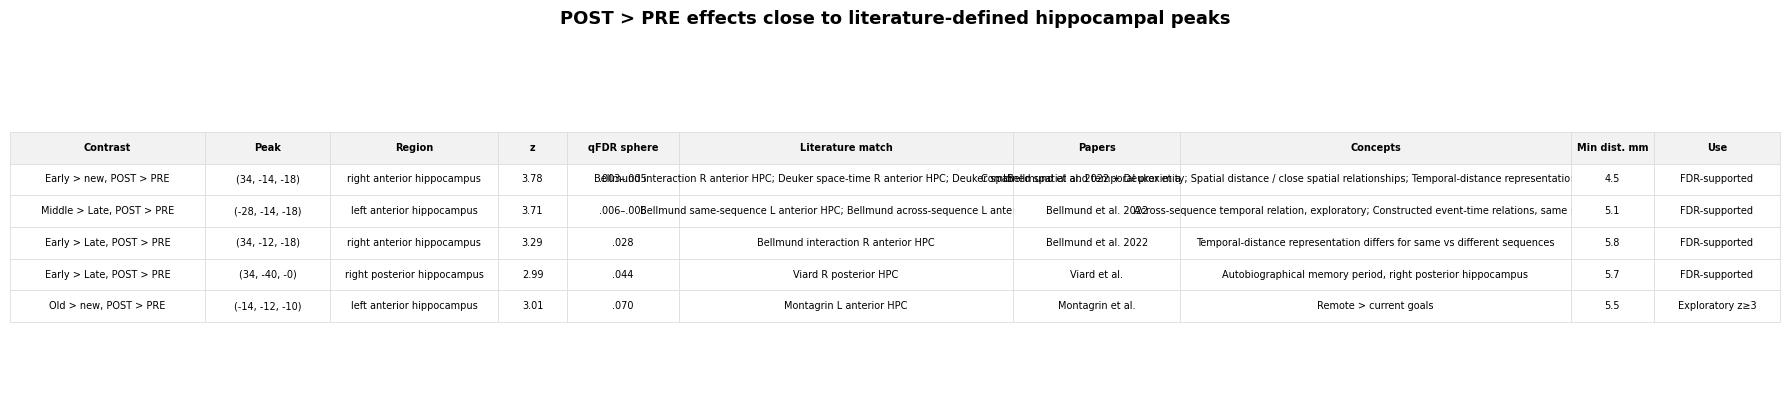

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_literature_matched_clean.png

TABLE 2 — Strong POST > PRE MTL-ish peaks not covered by current literature centers


,Contrast,Peak,Peak z,Cluster size,Hemisphere,HPC axis heuristic,Nearest literature sphere,Nearest paper,Nearest center,Distance to nearest literature center mm
0,"Early > new, POST > PRE","(-8, 3, -10)",4.53,93.0,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",13.8
1,"Early > new, POST > PRE","(42, -7, -20)",4.22,78.0,right,anterior,Deuker spatial R anterior HPC,Deuker et al.,"(34, -17, -22)",12.6
2,"Late > Middle, POST > PRE","(6, -50, -6)",4.09,203,right,posterior,Viard R posterior HPC secondary,Viard et al.,"(14, -38, 2)",15.6
3,"Late > Middle, POST > PRE","(4, -2, 2)",3.98,140,right,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",26.0
4,"Late > new, POST > PRE","(4, -14, -18)",3.96,281.0,right,anterior,Montagrin R anterior HPC,Montagrin et al.,"(18, -21, -14)",15.4
5,"Middle > Early, POST > PRE","(9, -47, -43)",3.86,125.0,right,posterior,Montagrin R anterior HPC,Montagrin et al.,"(18, -21, -14)",39.5
6,"Old > new, POST > PRE","(6, -12, -18)",3.85,218.0,right,anterior,Montagrin R anterior HPC,Montagrin et al.,"(18, -21, -14)",14.6
7,"Late > new, POST > PRE","(9, -34, -43)",3.72,78.0,right,posterior,Deuker temporal R anterior HPC,Deuker et al.,"(26, -18, -22)",31.7
8,"Middle > new, POST > PRE","(-36, -52, -0)",3.70,78.0,left,posterior,Montagrin L posterior HPC,Montagrin et al.,"(-30, -31, -14)",25.9
9,"Late > Middle, POST > PRE","(-11, -12, -6)",3.34,93,left,anterior,Montagrin L anterior HPC,Montagrin et al.,"(-15, -8, -14)",10.5


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_MTL_unmatched_candidate_peaks.csv


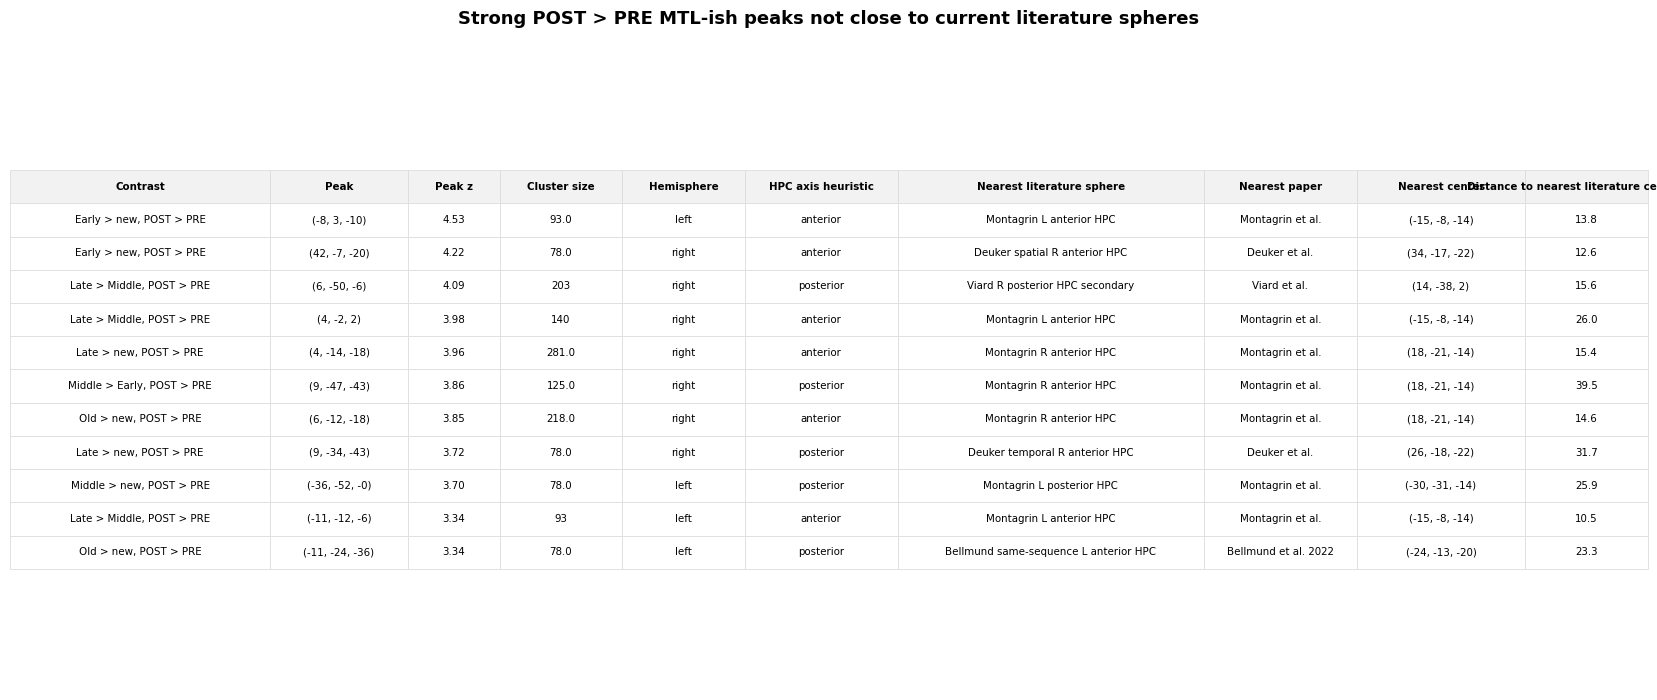

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_MTL_unmatched_candidate_peaks.png

Gradient plot dataset:


,source,contrast,label,x,y,z,z_stat,hemi,axis,notes
0,Observed: literature-matched,"Early > new, POST > PRE",Early > new,34.0,-14.0,-18.0,3.780000,right,anterior,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC
1,Observed: literature-matched,"Middle > Late, POST > PRE",Middle > Late,-28.0,-14.0,-18.0,3.710000,left,anterior,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC
2,Observed: literature-matched,"Early > Late, POST > PRE",Early > Late,34.0,-12.0,-18.0,3.290000,right,anterior,Bellmund interaction R anterior HPC
3,Observed: literature-matched,"Early > Late, POST > PRE",Early > Late,34.0,-40.0,-0.0,2.990000,right,posterior,Viard R posterior HPC
4,Observed: literature-matched,"Old > new, POST > PRE",Old > new,-14.0,-12.0,-10.0,3.010000,left,anterior,Montagrin L anterior HPC
5,Observed: unmatched MTL-ish,"Early > new, POST > PRE",Early > new,-8.5,3.0,-10.5,4.533857,left,anterior,unmatched
6,Observed: unmatched MTL-ish,"Early > new, POST > PRE",Early > new,41.5,-7.0,-20.5,4.215716,right,anterior,unmatched
7,Observed: unmatched MTL-ish,"Late > Middle, POST > PRE",Late > Middle,6.5,-49.5,-5.5,4.086464,right,posterior,unmatched
8,Observed: unmatched MTL-ish,"Late > Middle, POST > PRE",Late > Middle,4.0,-2.0,2.0,3.976380,right,anterior,unmatched
9,Observed: unmatched MTL-ish,"Late > new, POST > PRE",Late > new,4.0,-14.5,-18.0,3.961224,right,anterior,unmatched


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_gradient_plot_points.csv


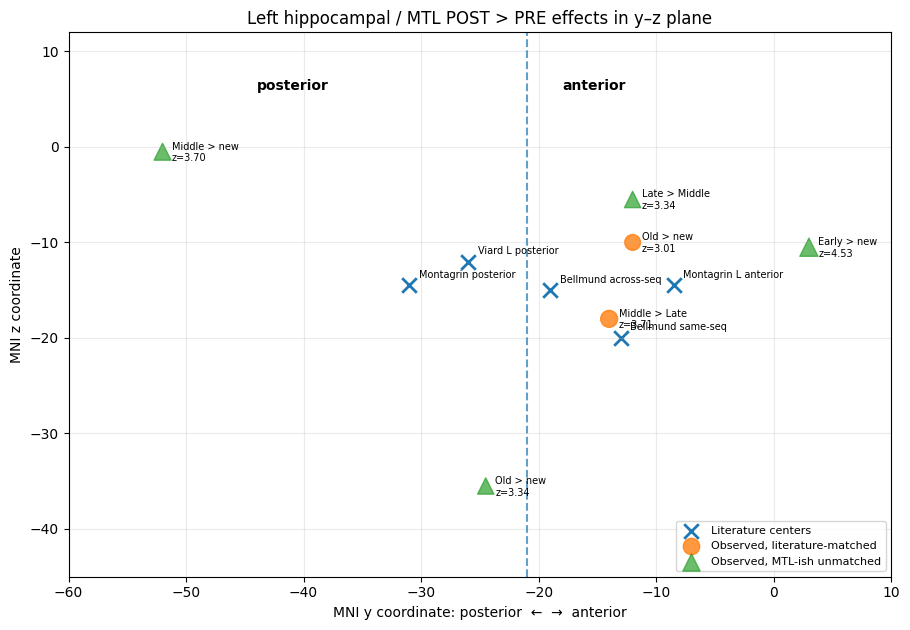

Saved gradient plot:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_LEFT_yz_gradient_plot.png


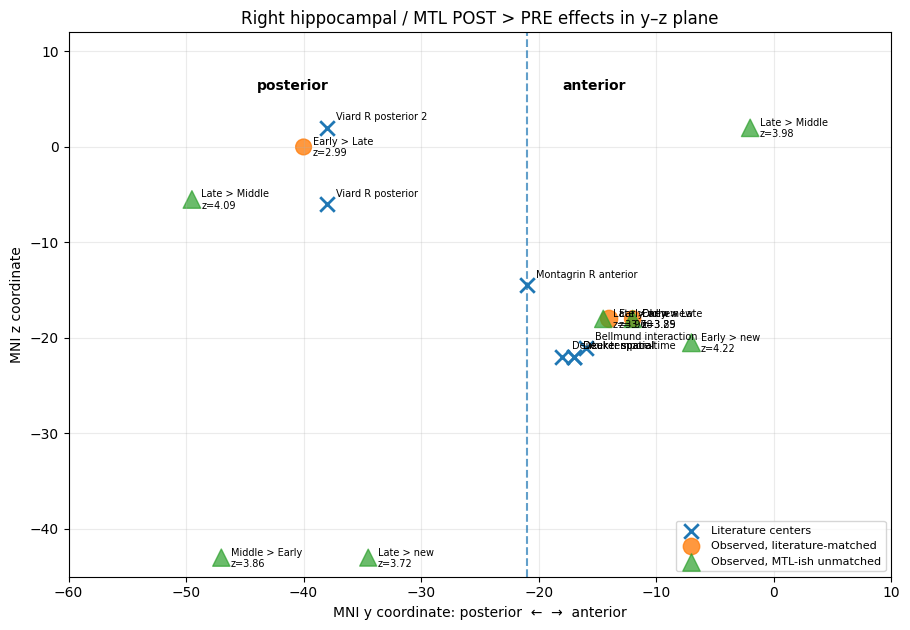

Saved gradient plot:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_RIGHT_yz_gradient_plot.png

Long-axis summary:


,hemi,axis,source,n_peaks,mean_z,max_z,contrasts
0,left,anterior,Observed: literature-matched,2,3.36,3.71,"Middle > Late, POST > PRE; Old > new, POST > PRE"
1,left,anterior,Observed: unmatched MTL-ish,2,3.94,4.53,"Early > new, POST > PRE; Late > Middle, POST > PRE"
2,left,posterior,Observed: unmatched MTL-ish,2,3.52,3.70,"Middle > new, POST > PRE; Old > new, POST > PRE"
3,right,anterior,Observed: literature-matched,2,3.54,3.78,"Early > Late, POST > PRE; Early > new, POST > PRE"
4,right,anterior,Observed: unmatched MTL-ish,4,4.00,4.22,"Early > new, POST > PRE; Late > Middle, POST > PRE; Late > new, POST > PRE; Old > new, POST > PRE"
5,right,posterior,Observed: literature-matched,1,2.99,2.99,"Early > Late, POST > PRE"
6,right,posterior,Observed: unmatched MTL-ish,3,3.89,4.09,"Late > Middle, POST > PRE; Late > new, POST > PRE; Middle > Early, POST > PRE"


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_long_axis_summary.csv


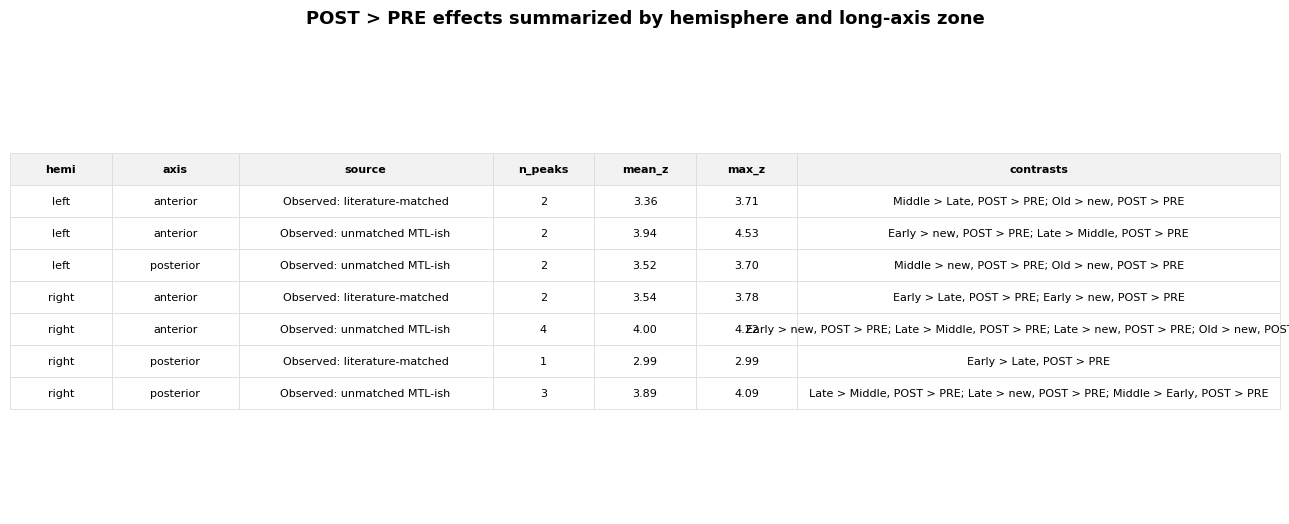

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_long_axis_summary.png

Recommended outputs to inspect:
1. Literature-matched table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_literature_matched_clean.png
2. MTL-ish unmatched table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_gradient_exploration/pre_post_encoding_space_early_middle_late_contro

In [23]:
# ============================================================
# POST > PRE hippocampal / MTL gradient exploration
#
# Inputs expected from previous POST > PRE exploration cell:
# - post_pre_literature_summary
# - wholebrain_peaks
# - unmatched_summary
# - literature_centers_df
#
# Outputs:
# 1) Clean literature-matched POST > PRE summary
# 2) Strong unmatched MTL-ish candidate peaks
# 3) Left y-z long-axis plot
# 4) Right y-z long-axis plot
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

gradient_dir = (
    dirs["figures"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_gradient_exploration"
)

gradient_table_dir = (
    dirs["tables"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_gradient_exploration"
)

gradient_dir.mkdir(parents=True, exist_ok=True)
gradient_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving gradient figures to:", gradient_dir)
print("Saving gradient tables to:", gradient_table_dir)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "post_pre_literature_summary",
    "wholebrain_peaks",
    "literature_centers_df",
]

for obj in required_objects:
    assert obj in globals(), f"{obj} not found. Run the POST > PRE exploration cell first."

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_coord_gradient(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def classify_hemi_gradient(x):
    if x < -2:
        return "left"
    if x > 2:
        return "right"
    return "midline"


def classify_long_axis_gradient(y):
    # Same heuristic as previous cells.
    # y < -21 = posterior hippocampus
    # y >= -21 = anterior hippocampus
    return "posterior" if y < -21 else "anterior"


def parse_coord_string(coord_string):
    """
    Convert '(34, -14, -18)' to np.array([34, -14, -18]).
    """
    coord_string = str(coord_string).replace("(", "").replace(")", "")
    values = [float(x.strip()) for x in coord_string.split(",")]
    return np.array(values, dtype=float)


def short_lit_name_gradient(roi):
    roi = str(roi)

    replacements = {
        "Deuker_temporal_right_medial_anterior_HPC": "Deuker temporal",
        "Deuker_spatial_right_medial_anterior_HPC": "Deuker spatial",
        "Deuker_combined_space_time_right_medial_anterior_HPC": "Deuker space-time",
        "Bellmund_same_sequence_left_anterior_HPC": "Bellmund same-seq",
        "Bellmund_interaction_right_anterior_HPC": "Bellmund interaction",
        "Bellmund_across_sequence_left_anterior_HPC_exploratory": "Bellmund across-seq",
        "Montagrin_current_gt_remote_left_posterior_HPC": "Montagrin posterior",
        "Montagrin_remote_gt_current_left_anterior_HPC": "Montagrin L anterior",
        "Montagrin_remote_gt_current_right_anterior_HPC": "Montagrin R anterior",
        "Viard_left_posterior_HPC_autobiographical_period": "Viard L posterior",
        "Viard_right_posterior_HPC_autobiographical_period": "Viard R posterior",
        "Viard_right_posterior_HPC_autobiographical_period_secondary": "Viard R posterior 2",
    }

    return replacements.get(roi, roi)


def save_clean_table_png_gradient(
    df,
    out_path,
    title=None,
    fontsize=8,
    header_fontsize=8,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)


# ------------------------------------------------------------
# TABLE 1:
# Clean literature-matched POST > PRE effects
# ------------------------------------------------------------

literature_matched_clean = post_pre_literature_summary.copy()

# Keep columns most useful for slides/report
lit_cols = [
    "Contrast",
    "Peak",
    "Region",
    "z",
    "qFDR sphere",
    "Literature match",
    "Papers",
    "Concepts",
    "Min dist. mm",
    "Use",
]

literature_matched_clean = literature_matched_clean[
    [c for c in lit_cols if c in literature_matched_clean.columns]
].copy()

lit_clean_csv = (
    gradient_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_literature_matched_clean.csv"
)

literature_matched_clean.to_csv(lit_clean_csv, index=False)

print("\nTABLE 1 — Clean POST > PRE effects close to literature peaks")
display(literature_matched_clean)

print("Saved:")
print(lit_clean_csv)

lit_clean_png = (
    gradient_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_literature_matched_clean.png"
)

save_clean_table_png_gradient(
    literature_matched_clean,
    lit_clean_png,
    title="POST > PRE effects close to literature-defined hippocampal peaks",
    fontsize=7.0,
    header_fontsize=7.0,
    scale_y=1.75,
    col_widths=[0.14, 0.09, 0.12, 0.05, 0.08, 0.24, 0.12, 0.28, 0.06, 0.09],
    figsize=(18, max(3.2, 0.55 * len(literature_matched_clean) + 1.5)),
)

# ------------------------------------------------------------
# TABLE 2:
# Strong unmatched peaks in an approximate MTL / hippocampal box
# ------------------------------------------------------------
# Important:
# This is not an anatomical ROI.
# It is only a practical filter to avoid mixing in frontal/parietal/occipital peaks
# when looking for possible new hippocampal / MTL literature matches.

mtl_box = (
    (wholebrain_peaks["x"].between(-45, 45))
    & (wholebrain_peaks["y"].between(-55, 8))
    & (wholebrain_peaks["z_coord"].between(-45, 8))
)

not_close = ~wholebrain_peaks["Close to current literature?"]

mtl_unmatched = wholebrain_peaks[
    mtl_box & not_close
].copy()

mtl_unmatched = mtl_unmatched.sort_values(
    ["Peak z", "Distance to nearest literature center mm"],
    ascending=[False, False],
).reset_index(drop=True)

mtl_unmatched_clean = mtl_unmatched[
    [
        "Contrast",
        "Peak",
        "Peak z",
        "Cluster size",
        "Hemisphere",
        "HPC axis heuristic",
        "Nearest literature sphere",
        "Nearest paper",
        "Nearest center",
        "Distance to nearest literature center mm",
    ]
].copy()

mtl_unmatched_clean["Peak z"] = mtl_unmatched_clean["Peak z"].map(
    lambda x: f"{float(x):.2f}" if pd.notna(x) else "—"
)

mtl_unmatched_clean["Distance to nearest literature center mm"] = mtl_unmatched_clean[
    "Distance to nearest literature center mm"
].map(lambda x: f"{float(x):.1f}")

mtl_unmatched_csv = (
    gradient_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_MTL_unmatched_candidate_peaks.csv"
)

mtl_unmatched_clean.to_csv(mtl_unmatched_csv, index=False)

print("\nTABLE 2 — Strong POST > PRE MTL-ish peaks not covered by current literature centers")
display(mtl_unmatched_clean)

print("Saved:")
print(mtl_unmatched_csv)

if len(mtl_unmatched_clean) > 0:
    mtl_unmatched_png = (
        gradient_dir
        / f"{ANALYSIS_NAME}_POST_GT_PRE_MTL_unmatched_candidate_peaks.png"
    )

    save_clean_table_png_gradient(
        mtl_unmatched_clean,
        mtl_unmatched_png,
        title="Strong POST > PRE MTL-ish peaks not close to current literature spheres",
        fontsize=7.4,
        header_fontsize=7.4,
        scale_y=1.7,
        col_widths=[0.17, 0.09, 0.06, 0.08, 0.08, 0.10, 0.20, 0.10, 0.11, 0.08],
        figsize=(16.5, max(3.2, 0.5 * len(mtl_unmatched_clean) + 1.6)),
    )

# ------------------------------------------------------------
# Build dataset for gradient plots
# ------------------------------------------------------------

plot_rows = []

# Literature-matched observed peaks
for _, row in post_pre_literature_summary.iterrows():
    coord = parse_coord_string(row["Peak"])
    x, y, z = coord

    plot_rows.append({
        "source": "Observed: literature-matched",
        "contrast": row["Contrast"],
        "label": row["Contrast"].replace(", POST > PRE", ""),
        "x": x,
        "y": y,
        "z": z,
        "z_stat": float(row["z"]),
        "hemi": classify_hemi_gradient(x),
        "axis": classify_long_axis_gradient(y),
        "notes": row.get("Literature match", ""),
    })

# MTL-ish unmatched peaks
for _, row in mtl_unmatched.iterrows():
    x = float(row["x"])
    y = float(row["y"])
    z = float(row["z_coord"])

    plot_rows.append({
        "source": "Observed: unmatched MTL-ish",
        "contrast": row["Contrast"],
        "label": row["Contrast"].replace(", POST > PRE", ""),
        "x": x,
        "y": y,
        "z": z,
        "z_stat": float(row["Peak z"]),
        "hemi": classify_hemi_gradient(x),
        "axis": classify_long_axis_gradient(y),
        "notes": "unmatched",
    })

# Literature centers
for _, row in literature_centers_df.iterrows():
    x = float(row["x"])
    y = float(row["y"])
    z = float(row["z"])

    plot_rows.append({
        "source": "Literature center",
        "contrast": row["paper"],
        "label": short_lit_name_gradient(row["roi_name"]),
        "x": x,
        "y": y,
        "z": z,
        "z_stat": np.nan,
        "hemi": classify_hemi_gradient(x),
        "axis": classify_long_axis_gradient(y),
        "notes": row["concept"],
    })

gradient_plot_df = pd.DataFrame(plot_rows)

gradient_plot_csv = (
    gradient_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_gradient_plot_points.csv"
)

gradient_plot_df.to_csv(gradient_plot_csv, index=False)

print("\nGradient plot dataset:")
display(gradient_plot_df)

print("Saved:")
print(gradient_plot_csv)

# ------------------------------------------------------------
# Plot function: y-z plane separately for left and right
# ------------------------------------------------------------

def plot_hemisphere_gradient(df, hemi, out_path):
    """
    y-z plane:
    x-axis = MNI y coordinate
      more negative = posterior
      less negative / positive = anterior
    y-axis = MNI z coordinate
    """

    hemi_df = df[df["hemi"] == hemi].copy()

    fig, ax = plt.subplots(figsize=(9.2, 6.4))
    fig.patch.set_facecolor("white")

    # Literature centers
    lit = hemi_df[hemi_df["source"] == "Literature center"].copy()
    if len(lit) > 0:
        ax.scatter(
            lit["y"],
            lit["z"],
            marker="x",
            s=110,
            linewidths=2.0,
            label="Literature centers",
        )

        for _, row in lit.iterrows():
            ax.text(
                row["y"] + 0.8,
                row["z"] + 0.8,
                row["label"],
                fontsize=7,
            )

    # Observed literature-matched
    matched = hemi_df[hemi_df["source"] == "Observed: literature-matched"].copy()
    if len(matched) > 0:
        sizes = 45 + 28 * matched["z_stat"].fillna(3.0)
        ax.scatter(
            matched["y"],
            matched["z"],
            marker="o",
            s=sizes,
            alpha=0.80,
            label="Observed, literature-matched",
        )

        for _, row in matched.iterrows():
            ax.text(
                row["y"] + 0.8,
                row["z"] - 1.0,
                f"{row['label']}\nz={row['z_stat']:.2f}",
                fontsize=7,
            )

    # Observed unmatched MTL-ish
    unmatched = hemi_df[hemi_df["source"] == "Observed: unmatched MTL-ish"].copy()
    if len(unmatched) > 0:
        sizes = 45 + 28 * unmatched["z_stat"].fillna(3.0)
        ax.scatter(
            unmatched["y"],
            unmatched["z"],
            marker="^",
            s=sizes,
            alpha=0.70,
            label="Observed, MTL-ish unmatched",
        )

        for _, row in unmatched.iterrows():
            ax.text(
                row["y"] + 0.8,
                row["z"] - 1.0,
                f"{row['label']}\nz={row['z_stat']:.2f}",
                fontsize=7,
            )

    # Long-axis split y = -21
    ax.axvline(
        -21,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7,
    )

    ax.text(
        -44,
        6,
        "posterior",
        fontsize=10,
        weight="bold",
    )
    ax.text(
        -18,
        6,
        "anterior",
        fontsize=10,
        weight="bold",
    )

    ax.set_xlabel("MNI y coordinate: posterior  ←  →  anterior")
    ax.set_ylabel("MNI z coordinate")
    ax.set_title(
        f"{hemi.capitalize()} hippocampal / MTL POST > PRE effects in y–z plane"
    )

    ax.set_xlim(-60, 10)
    ax.set_ylim(-45, 12)

    ax.grid(True, alpha=0.25)
    ax.legend(loc="lower right", fontsize=8, frameon=True)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved gradient plot:")
    print(out_path)


# ------------------------------------------------------------
# Make left and right gradient plots
# ------------------------------------------------------------

left_gradient_png = (
    gradient_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_LEFT_yz_gradient_plot.png"
)

right_gradient_png = (
    gradient_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_RIGHT_yz_gradient_plot.png"
)

plot_hemisphere_gradient(
    gradient_plot_df,
    hemi="left",
    out_path=left_gradient_png,
)

plot_hemisphere_gradient(
    gradient_plot_df,
    hemi="right",
    out_path=right_gradient_png,
)

# ------------------------------------------------------------
# Optional: simple long-axis summary table
# ------------------------------------------------------------

observed_only = gradient_plot_df[
    gradient_plot_df["source"].str.startswith("Observed")
].copy()

long_axis_summary = (
    observed_only
    .groupby(["hemi", "axis", "source"], dropna=False)
    .agg(
        n_peaks=("contrast", "count"),
        mean_z=("z_stat", "mean"),
        max_z=("z_stat", "max"),
        contrasts=("contrast", lambda x: "; ".join(sorted(set(x)))),
    )
    .reset_index()
)

long_axis_summary["mean_z"] = long_axis_summary["mean_z"].map(lambda x: f"{x:.2f}")
long_axis_summary["max_z"] = long_axis_summary["max_z"].map(lambda x: f"{x:.2f}")

long_axis_summary_csv = (
    gradient_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_long_axis_summary.csv"
)

long_axis_summary.to_csv(long_axis_summary_csv, index=False)

print("\nLong-axis summary:")
display(long_axis_summary)

print("Saved:")
print(long_axis_summary_csv)

long_axis_summary_png = (
    gradient_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_long_axis_summary.png"
)

save_clean_table_png_gradient(
    long_axis_summary,
    long_axis_summary_png,
    title="POST > PRE effects summarized by hemisphere and long-axis zone",
    fontsize=8,
    header_fontsize=8,
    scale_y=1.7,
    col_widths=[0.08, 0.10, 0.20, 0.08, 0.08, 0.08, 0.38],
    figsize=(13, max(3.0, 0.55 * len(long_axis_summary) + 1.5)),
)

print("\nRecommended outputs to inspect:")
print("1. Literature-matched table:", lit_clean_png)
print("2. MTL-ish unmatched table:", mtl_unmatched_csv)
print("3. Left y-z gradient:", left_gradient_png)
print("4. Right y-z gradient:", right_gradient_png)
print("5. Long-axis summary:", long_axis_summary_png)

Saving 3D figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus
Saving 3D tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus
Using left_roi_group_mask_img and right_roi_group_mask_img from memory.
Left ROI cloud points: (4500, 3)
Right ROI cloud points: (4500, 3)

Observed points used for 3D plot:


,source,Contrast,Short label,Peak,x,y,z,Peak z,Hemisphere,Axis,Support,Papers,Use
0,literature-matched,"Early > new, POST > PRE",Early > new,"(34, -14, -18)",34.0,-14.0,-18.0,3.780000,right,anterior,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC,Bellmund et al. 2022 + Deuker et al.,FDR-supported
1,literature-matched,"Middle > Late, POST > PRE",Middle > Late,"(-28, -14, -18)",-28.0,-14.0,-18.0,3.710000,left,anterior,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC,Bellmund et al. 2022,FDR-supported
2,literature-matched,"Early > Late, POST > PRE",Early > Late,"(34, -12, -18)",34.0,-12.0,-18.0,3.290000,right,anterior,Bellmund interaction R anterior HPC,Bellmund et al. 2022,FDR-supported
3,literature-matched,"Early > Late, POST > PRE",Early > Late,"(34, -40, -0)",34.0,-40.0,-0.0,2.990000,right,posterior,Viard R posterior HPC,Viard et al.,FDR-supported
4,literature-matched,"Old > new, POST > PRE",Old > new,"(-14, -12, -10)",-14.0,-12.0,-10.0,3.010000,left,anterior,Montagrin L anterior HPC,Montagrin et al.,Exploratory z≥3
5,exploratory-unmatched,"Early > new, POST > PRE",Early > new,"(-8, 3, -10)",-8.5,3.0,-10.5,4.533857,left,anterior,Nearest current literature center: Montagrin L anterior HPC (13.8 mm),new literature search needed,Exploratory unmatched
6,exploratory-unmatched,"Early > new, POST > PRE",Early > new,"(42, -7, -20)",41.5,-7.0,-20.5,4.215716,right,anterior,Nearest current literature center: Deuker spatial R anterior HPC (12.6 mm),new literature search needed,Exploratory unmatched
7,exploratory-unmatched,"Late > Middle, POST > PRE",Late > Middle,"(6, -50, -6)",6.5,-49.5,-5.5,4.086464,right,posterior,Nearest current literature center: Viard R posterior HPC secondary (15.6 mm),new literature search needed,Exploratory unmatched
8,exploratory-unmatched,"Late > Middle, POST > PRE",Late > Middle,"(4, -2, 2)",4.0,-2.0,2.0,3.976380,right,anterior,Nearest current literature center: Montagrin L anterior HPC (26.0 mm),new literature search needed,Exploratory unmatched
9,exploratory-unmatched,"Late > new, POST > PRE",Late > new,"(4, -14, -18)",4.0,-14.5,-18.0,3.961224,right,anterior,Nearest current literature center: Montagrin R anterior HPC (15.4 mm),new literature search needed,Exploratory unmatched


Saved observed 3D points:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_observed_points_for_3D.csv


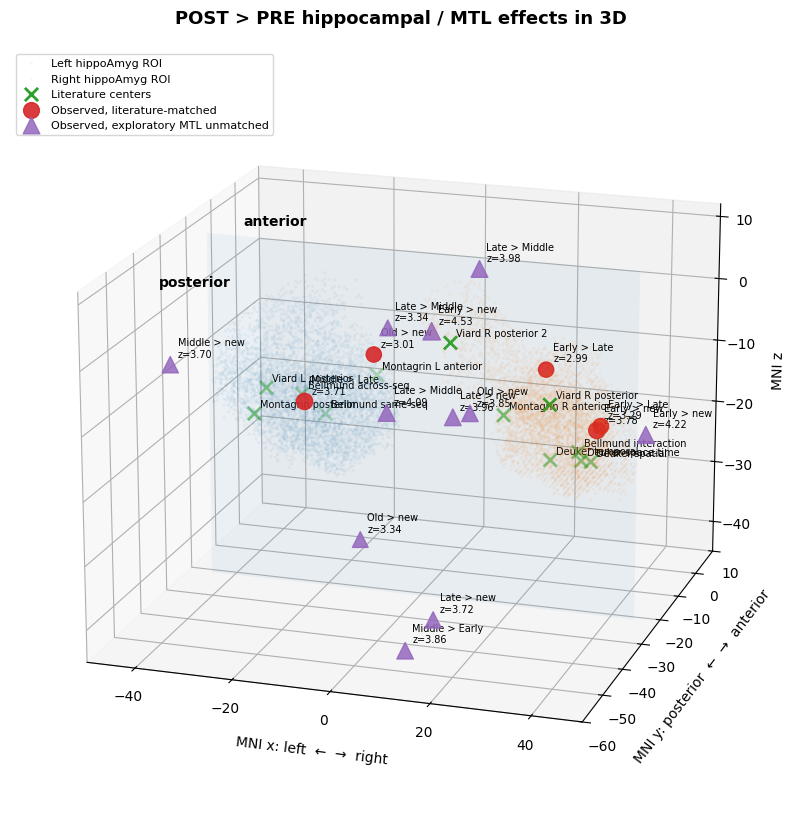

Saved 3D figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_hippoAmyg_main_view.png


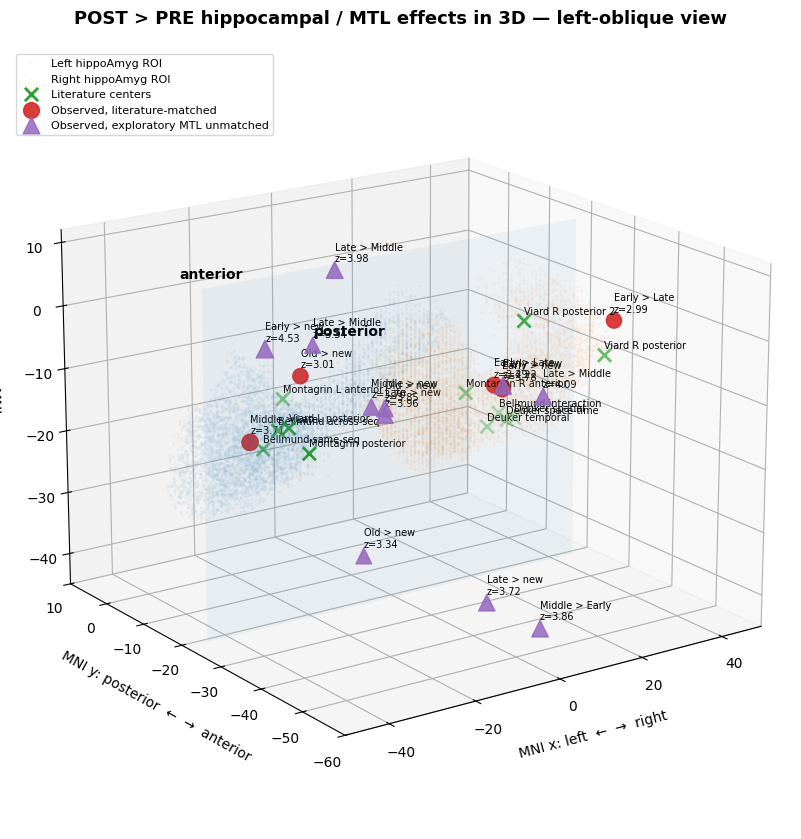

Saved 3D figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_hippoAmyg_left_oblique.png


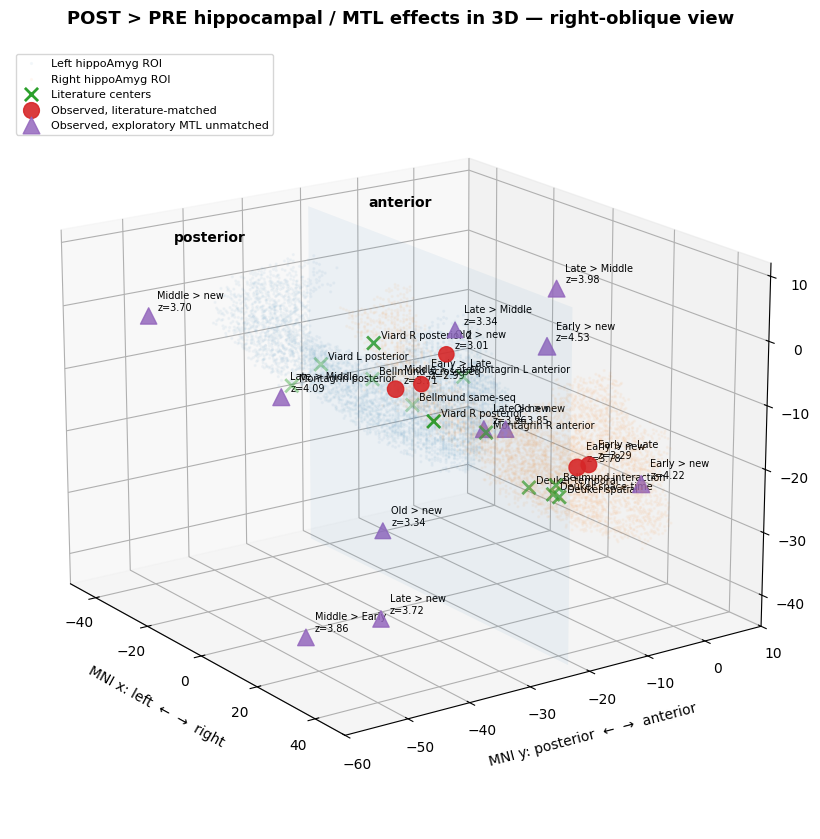

Saved 3D figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_hippoAmyg_right_oblique.png


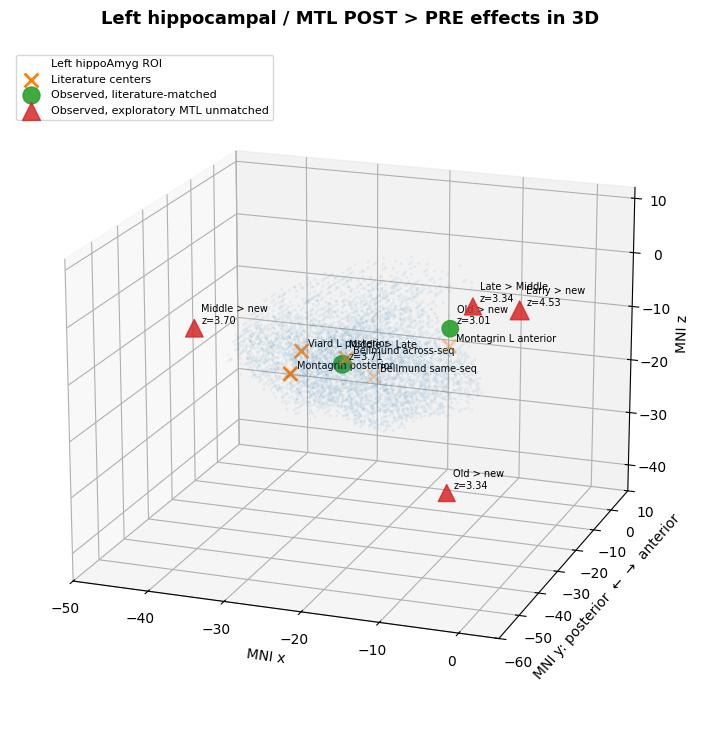

Saved hemi-specific 3D figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_left_hippoAmyg.png


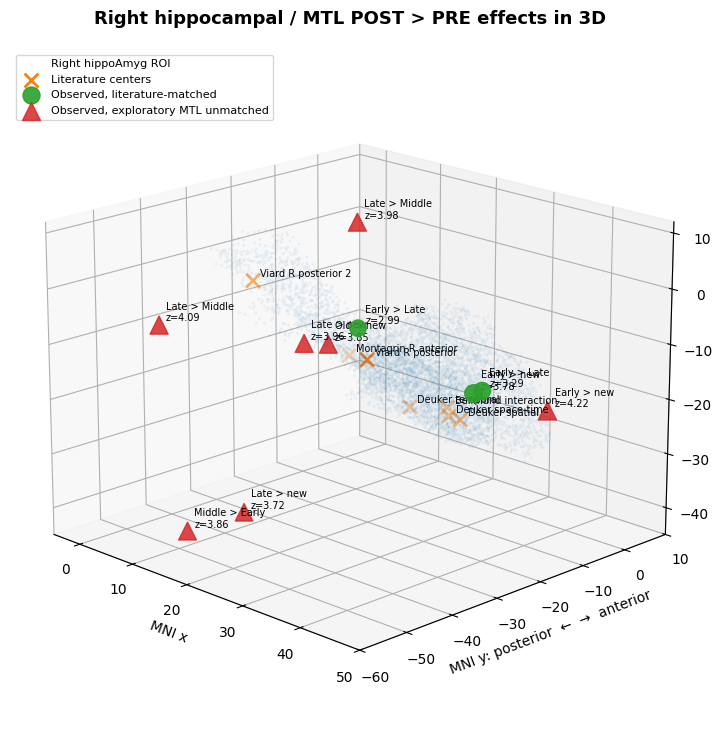

Saved hemi-specific 3D figure:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_right_hippoAmyg.png

3D observed-point summary:


,source,Contrast,Peak,Peak z,Hemisphere,Axis,Support,Papers,Use
0,literature-matched,"Early > new, POST > PRE","(34, -14, -18)",3.780000,right,anterior,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC,Bellmund et al. 2022 + Deuker et al.,FDR-supported
1,literature-matched,"Middle > Late, POST > PRE","(-28, -14, -18)",3.710000,left,anterior,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC,Bellmund et al. 2022,FDR-supported
2,literature-matched,"Early > Late, POST > PRE","(34, -12, -18)",3.290000,right,anterior,Bellmund interaction R anterior HPC,Bellmund et al. 2022,FDR-supported
3,literature-matched,"Early > Late, POST > PRE","(34, -40, -0)",2.990000,right,posterior,Viard R posterior HPC,Viard et al.,FDR-supported
4,literature-matched,"Old > new, POST > PRE","(-14, -12, -10)",3.010000,left,anterior,Montagrin L anterior HPC,Montagrin et al.,Exploratory z≥3
5,exploratory-unmatched,"Early > new, POST > PRE","(-8, 3, -10)",4.533857,left,anterior,Nearest current literature center: Montagrin L anterior HPC (13.8 mm),new literature search needed,Exploratory unmatched
6,exploratory-unmatched,"Early > new, POST > PRE","(42, -7, -20)",4.215716,right,anterior,Nearest current literature center: Deuker spatial R anterior HPC (12.6 mm),new literature search needed,Exploratory unmatched
7,exploratory-unmatched,"Late > Middle, POST > PRE","(6, -50, -6)",4.086464,right,posterior,Nearest current literature center: Viard R posterior HPC secondary (15.6 mm),new literature search needed,Exploratory unmatched
8,exploratory-unmatched,"Late > Middle, POST > PRE","(4, -2, 2)",3.976380,right,anterior,Nearest current literature center: Montagrin L anterior HPC (26.0 mm),new literature search needed,Exploratory unmatched
9,exploratory-unmatched,"Late > new, POST > PRE","(4, -14, -18)",3.961224,right,anterior,Nearest current literature center: Montagrin R anterior HPC (15.4 mm),new literature search needed,Exploratory unmatched


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_observed_3D_summary.csv

Recommended figures to inspect:
Main 3D view: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_hippoAmyg_main_view.png
Left oblique: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/post_gt_pre_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_POST_GT_PRE_3D_hippoAmyg_left_oblique.png
Right obl

In [24]:
# ============================================================
# 3D hippocampus / MTL visualization of POST > PRE effects
#
# Plots:
# - left/right group hippocampus-amygdala ROI mask as transparent grey cloud
# - literature centers as blue crosses
# - literature-matched observed POST > PRE peaks as orange circles
# - exploratory MTL-ish observed peaks as green triangles
#
# This is for exploratory visualization / long-axis interpretation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import nibabel as nib
from nilearn.image import load_img, resample_to_img
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

plot3d_dir = (
    dirs["figures"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_3d_hippocampus"
)

plot3d_table_dir = (
    dirs["tables"]
    / "literature_6mm_spheres_encoding_position"
    / "post_gt_pre_3d_hippocampus"
)

plot3d_dir.mkdir(parents=True, exist_ok=True)
plot3d_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving 3D figures to:", plot3d_dir)
print("Saving 3D tables to:", plot3d_table_dir)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required_objects = [
    "post_pre_literature_summary",
    "wholebrain_peaks",
    "literature_centers_df",
    "second_level_table",
]

for obj in required_objects:
    assert obj in globals(), f"{obj} not found. Run previous exploration cells first."

# If you ran cells 25–31, these should exist.
# If not, the code will try to reload the saved consensus ROI masks.
ROI_THRESHOLD_FOR_3D = 0.50
ROI_NAME_FOR_3D = "hippoAmyg"

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def fmt_coord_3d(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def parse_coord_string_3d(coord_string):
    coord_string = str(coord_string).replace("(", "").replace(")", "")
    values = [float(x.strip()) for x in coord_string.split(",")]
    return np.array(values, dtype=float)


def classify_hemi_3d(x):
    if x < -2:
        return "left"
    if x > 2:
        return "right"
    return "midline"


def classify_axis_3d(y):
    return "posterior" if y < -21 else "anterior"


def short_lit_name_3d(roi):
    roi = str(roi)

    replacements = {
        "Deuker_temporal_right_medial_anterior_HPC": "Deuker temporal",
        "Deuker_spatial_right_medial_anterior_HPC": "Deuker spatial",
        "Deuker_combined_space_time_right_medial_anterior_HPC": "Deuker space-time",
        "Bellmund_same_sequence_left_anterior_HPC": "Bellmund same-seq",
        "Bellmund_interaction_right_anterior_HPC": "Bellmund interaction",
        "Bellmund_across_sequence_left_anterior_HPC_exploratory": "Bellmund across-seq",
        "Montagrin_current_gt_remote_left_posterior_HPC": "Montagrin posterior",
        "Montagrin_remote_gt_current_left_anterior_HPC": "Montagrin L anterior",
        "Montagrin_remote_gt_current_right_anterior_HPC": "Montagrin R anterior",
        "Viard_left_posterior_HPC_autobiographical_period": "Viard L posterior",
        "Viard_right_posterior_HPC_autobiographical_period": "Viard R posterior",
        "Viard_right_posterior_HPC_autobiographical_period_secondary": "Viard R posterior 2",
    }

    return replacements.get(roi, roi)


def make_contrast_short_label_3d(label):
    label = str(label)
    label = label.replace(", POST > PRE", "")
    label = label.replace("encoding time old", "Old")
    return label


def get_mask_xyz(mask_img, max_points=4500, random_state=42):
    """
    Convert a binary mask image to MNI xyz coordinates.
    Downsamples points for readable 3D plotting.
    """
    data = mask_img.get_fdata() > 0
    ijk = np.array(np.where(data)).T

    if len(ijk) == 0:
        return np.empty((0, 3))

    xyz = nib.affines.apply_affine(mask_img.affine, ijk)

    if len(xyz) > max_points:
        rng = np.random.default_rng(random_state)
        keep_idx = rng.choice(len(xyz), size=max_points, replace=False)
        xyz = xyz[keep_idx]

    return xyz


def try_load_roi_masks_for_3d():
    """
    Try to get left/right group consensus ROI masks from memory first,
    then from disk if needed.
    """

    if "left_roi_group_mask_img" in globals() and "right_roi_group_mask_img" in globals():
        print("Using left_roi_group_mask_img and right_roi_group_mask_img from memory.")
        return left_roi_group_mask_img, right_roi_group_mask_img

    candidate_dirs = []

    if "roi_table_dir" in globals():
        candidate_dirs.append(Path(roi_table_dir))

    candidate_dirs.append(
        dirs["tables"] / "roi_spatial_early_middle_late"
    )

    candidate_dirs.append(
        dirs["tables"] / "roi_overlap"
    )

    for d in candidate_dirs:
        left_path = (
            d
            / f"group_consensus_left_{ROI_NAME_FOR_3D}_threshold-{ROI_THRESHOLD_FOR_3D:.2f}_mask.nii.gz"
        )
        right_path = (
            d
            / f"group_consensus_right_{ROI_NAME_FOR_3D}_threshold-{ROI_THRESHOLD_FOR_3D:.2f}_mask.nii.gz"
        )

        if left_path.exists() and right_path.exists():
            print("Loaded ROI masks from:")
            print(left_path)
            print(right_path)
            return load_img(str(left_path)), load_img(str(right_path))

    raise FileNotFoundError(
        "Could not find left/right group ROI masks. "
        "Run cell 27 first, or check roi_table_dir paths."
    )


# ------------------------------------------------------------
# Load hippocampus / MTL ROI masks
# ------------------------------------------------------------

left_mask_img, right_mask_img = try_load_roi_masks_for_3d()

left_xyz = get_mask_xyz(left_mask_img, max_points=4500, random_state=1)
right_xyz = get_mask_xyz(right_mask_img, max_points=4500, random_state=2)

print("Left ROI cloud points:", left_xyz.shape)
print("Right ROI cloud points:", right_xyz.shape)

# ------------------------------------------------------------
# Build observed selected points
# ------------------------------------------------------------

observed_rows = []

# Literature-matched effects: keep all from the table you selected
for _, row in post_pre_literature_summary.iterrows():
    coord = parse_coord_string_3d(row["Peak"])
    x, y, z = coord

    observed_rows.append({
        "source": "literature-matched",
        "Contrast": row["Contrast"],
        "Short label": make_contrast_short_label_3d(row["Contrast"]),
        "Peak": row["Peak"],
        "x": x,
        "y": y,
        "z": z,
        "Peak z": float(row["z"]),
        "Hemisphere": classify_hemi_3d(x),
        "Axis": classify_axis_3d(y),
        "Support": row.get("Literature match", ""),
        "Papers": row.get("Papers", ""),
        "Use": row.get("Use", ""),
    })

# Exploratory unmatched MTL-ish effects:
# keep only points that are in the broad MTL box and not already close to literature
mtl_box = (
    (wholebrain_peaks["x"].between(-45, 45))
    & (wholebrain_peaks["y"].between(-55, 8))
    & (wholebrain_peaks["z_coord"].between(-45, 8))
)

not_close = ~wholebrain_peaks["Close to current literature?"]

mtl_unmatched_for_3d = wholebrain_peaks[
    mtl_box & not_close
].copy()

# Optional stricter filter: remove low-z unmatched points
MTL_UNMATCHED_MIN_Z = 3.30
mtl_unmatched_for_3d = mtl_unmatched_for_3d[
    mtl_unmatched_for_3d["Peak z"] >= MTL_UNMATCHED_MIN_Z
].copy()

mtl_unmatched_for_3d = mtl_unmatched_for_3d.sort_values(
    ["Peak z"],
    ascending=False,
).reset_index(drop=True)

for _, row in mtl_unmatched_for_3d.iterrows():
    observed_rows.append({
        "source": "exploratory-unmatched",
        "Contrast": row["Contrast"],
        "Short label": make_contrast_short_label_3d(row["Contrast"]),
        "Peak": row["Peak"],
        "x": float(row["x"]),
        "y": float(row["y"]),
        "z": float(row["z_coord"]),
        "Peak z": float(row["Peak z"]),
        "Hemisphere": classify_hemi_3d(float(row["x"])),
        "Axis": classify_axis_3d(float(row["y"])),
        "Support": (
            f"Nearest current literature center: {row['Nearest literature sphere']} "
            f"({row['Distance to nearest literature center mm']:.1f} mm)"
        ),
        "Papers": "new literature search needed",
        "Use": "Exploratory unmatched",
    })

observed_3d_points = pd.DataFrame(observed_rows)

observed_3d_csv = (
    plot3d_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_observed_points_for_3D.csv"
)

observed_3d_points.to_csv(observed_3d_csv, index=False)

print("\nObserved points used for 3D plot:")
display(observed_3d_points)

print("Saved observed 3D points:")
print(observed_3d_csv)

# ------------------------------------------------------------
# Literature center points
# ------------------------------------------------------------

literature_3d_points = literature_centers_df.copy()
literature_3d_points["Short label"] = literature_3d_points["roi_name"].apply(short_lit_name_3d)
literature_3d_points["Hemisphere"] = literature_3d_points["x"].apply(classify_hemi_3d)
literature_3d_points["Axis"] = literature_3d_points["y"].apply(classify_axis_3d)

literature_3d_csv = (
    plot3d_table_dir
    / f"{ANALYSIS_NAME}_literature_centers_for_3D.csv"
)

literature_3d_points.to_csv(literature_3d_csv, index=False)

# ------------------------------------------------------------
# Main 3D plotting function
# ------------------------------------------------------------

def plot_hippocampus_3d(
    observed_df,
    literature_df,
    left_xyz,
    right_xyz,
    out_path,
    view_elev=18,
    view_azim=-72,
    title="3D hippocampus / MTL POST > PRE effects",
):
    fig = plt.figure(figsize=(11.5, 8.5))
    fig.patch.set_facecolor("white")

    ax = fig.add_subplot(111, projection="3d")

    # ROI clouds
    if len(left_xyz) > 0:
        ax.scatter(
            left_xyz[:, 0],
            left_xyz[:, 1],
            left_xyz[:, 2],
            s=2,
            alpha=0.035,
            label="Left hippoAmyg ROI",
        )

    if len(right_xyz) > 0:
        ax.scatter(
            right_xyz[:, 0],
            right_xyz[:, 1],
            right_xyz[:, 2],
            s=2,
            alpha=0.035,
            label="Right hippoAmyg ROI",
        )

    # Literature centers
    lit_plot = literature_df.copy()

    ax.scatter(
        lit_plot["x"],
        lit_plot["y"],
        lit_plot["z"],
        marker="x",
        s=90,
        linewidths=2.0,
        label="Literature centers",
    )

    for _, row in lit_plot.iterrows():
        ax.text(
            row["x"] + 0.8,
            row["y"] + 0.8,
            row["z"] + 0.8,
            row["Short label"],
            fontsize=7,
        )

    # Literature-matched observed peaks
    matched = observed_df[observed_df["source"] == "literature-matched"].copy()

    if len(matched) > 0:
        sizes = 45 + 25 * matched["Peak z"].astype(float)

        ax.scatter(
            matched["x"],
            matched["y"],
            matched["z"],
            marker="o",
            s=sizes,
            alpha=0.90,
            label="Observed, literature-matched",
        )

        for _, row in matched.iterrows():
            ax.text(
                row["x"] + 1.0,
                row["y"] + 1.0,
                row["z"] + 1.0,
                f"{row['Short label']}\nz={row['Peak z']:.2f}",
                fontsize=7,
            )

    # Exploratory unmatched observed peaks
    unmatched = observed_df[observed_df["source"] == "exploratory-unmatched"].copy()

    if len(unmatched) > 0:
        sizes = 45 + 25 * unmatched["Peak z"].astype(float)

        ax.scatter(
            unmatched["x"],
            unmatched["y"],
            unmatched["z"],
            marker="^",
            s=sizes,
            alpha=0.85,
            label="Observed, exploratory MTL unmatched",
        )

        for _, row in unmatched.iterrows():
            ax.text(
                row["x"] + 1.0,
                row["y"] + 1.0,
                row["z"] + 1.0,
                f"{row['Short label']}\nz={row['Peak z']:.2f}",
                fontsize=7,
            )

    # Hippocampal anterior/posterior guide plane
    y_split = -21
    x_plane = np.linspace(-45, 45, 2)
    z_plane = np.linspace(-45, 10, 2)
    Xp, Zp = np.meshgrid(x_plane, z_plane)
    Yp = np.full_like(Xp, y_split)

    ax.plot_surface(
        Xp,
        Yp,
        Zp,
        alpha=0.06,
        linewidth=0,
        shade=False,
    )

    ax.text(
        -42,
        -45,
        9,
        "posterior",
        fontsize=10,
        weight="bold",
    )

    ax.text(
        -42,
        -12,
        9,
        "anterior",
        fontsize=10,
        weight="bold",
    )

    # Axis labels
    ax.set_xlabel("MNI x: left  ←  →  right", labelpad=10)
    ax.set_ylabel("MNI y: posterior  ←  →  anterior", labelpad=10)
    ax.set_zlabel("MNI z", labelpad=10)

    ax.set_title(title, pad=18, fontsize=13, weight="bold")

    # Limits focused on MTL / hippocampus area
    ax.set_xlim(-50, 50)
    ax.set_ylim(-60, 10)
    ax.set_zlim(-45, 12)

    ax.view_init(elev=view_elev, azim=view_azim)

    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8, frameon=True)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved 3D figure:")
    print(out_path)


# ------------------------------------------------------------
# Generate several useful 3D views
# ------------------------------------------------------------

fig_3d_main = (
    plot3d_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_3D_hippoAmyg_main_view.png"
)

plot_hippocampus_3d(
    observed_df=observed_3d_points,
    literature_df=literature_3d_points,
    left_xyz=left_xyz,
    right_xyz=right_xyz,
    out_path=fig_3d_main,
    view_elev=18,
    view_azim=-72,
    title="POST > PRE hippocampal / MTL effects in 3D",
)

fig_3d_left_oblique = (
    plot3d_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_3D_hippoAmyg_left_oblique.png"
)

plot_hippocampus_3d(
    observed_df=observed_3d_points,
    literature_df=literature_3d_points,
    left_xyz=left_xyz,
    right_xyz=right_xyz,
    out_path=fig_3d_left_oblique,
    view_elev=18,
    view_azim=-125,
    title="POST > PRE hippocampal / MTL effects in 3D — left-oblique view",
)

fig_3d_right_oblique = (
    plot3d_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_3D_hippoAmyg_right_oblique.png"
)

plot_hippocampus_3d(
    observed_df=observed_3d_points,
    literature_df=literature_3d_points,
    left_xyz=left_xyz,
    right_xyz=right_xyz,
    out_path=fig_3d_right_oblique,
    view_elev=18,
    view_azim=-35,
    title="POST > PRE hippocampal / MTL effects in 3D — right-oblique view",
)

# ------------------------------------------------------------
# Optional: separate left and right 3D plots
# ------------------------------------------------------------

def plot_one_hemi_3d(hemi):
    if hemi == "left":
        roi_xyz = left_xyz
        xlim = (-50, 5)
    elif hemi == "right":
        roi_xyz = right_xyz
        xlim = (-5, 50)
    else:
        raise ValueError("hemi must be 'left' or 'right'.")

    observed_hemi = observed_3d_points[
        observed_3d_points["Hemisphere"].isin([hemi, "midline"])
    ].copy()

    literature_hemi = literature_3d_points[
        literature_3d_points["Hemisphere"].isin([hemi, "midline"])
    ].copy()

    out_path = (
        plot3d_dir
        / f"{ANALYSIS_NAME}_POST_GT_PRE_3D_{hemi}_hippoAmyg.png"
    )

    fig = plt.figure(figsize=(9.5, 7.5))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection="3d")

    if len(roi_xyz) > 0:
        ax.scatter(
            roi_xyz[:, 0],
            roi_xyz[:, 1],
            roi_xyz[:, 2],
            s=2,
            alpha=0.045,
            label=f"{hemi.capitalize()} hippoAmyg ROI",
        )

    if len(literature_hemi) > 0:
        ax.scatter(
            literature_hemi["x"],
            literature_hemi["y"],
            literature_hemi["z"],
            marker="x",
            s=100,
            linewidths=2.0,
            label="Literature centers",
        )

        for _, row in literature_hemi.iterrows():
            ax.text(
                row["x"] + 0.7,
                row["y"] + 0.7,
                row["z"] + 0.7,
                row["Short label"],
                fontsize=7,
            )

    matched = observed_hemi[observed_hemi["source"] == "literature-matched"].copy()
    if len(matched) > 0:
        ax.scatter(
            matched["x"],
            matched["y"],
            matched["z"],
            marker="o",
            s=55 + 28 * matched["Peak z"].astype(float),
            alpha=0.90,
            label="Observed, literature-matched",
        )

        for _, row in matched.iterrows():
            ax.text(
                row["x"] + 0.7,
                row["y"] + 0.7,
                row["z"] + 0.7,
                f"{row['Short label']}\nz={row['Peak z']:.2f}",
                fontsize=7,
            )

    unmatched = observed_hemi[observed_hemi["source"] == "exploratory-unmatched"].copy()
    if len(unmatched) > 0:
        ax.scatter(
            unmatched["x"],
            unmatched["y"],
            unmatched["z"],
            marker="^",
            s=55 + 28 * unmatched["Peak z"].astype(float),
            alpha=0.85,
            label="Observed, exploratory MTL unmatched",
        )

        for _, row in unmatched.iterrows():
            ax.text(
                row["x"] + 0.7,
                row["y"] + 0.7,
                row["z"] + 0.7,
                f"{row['Short label']}\nz={row['Peak z']:.2f}",
                fontsize=7,
            )

    ax.set_xlabel("MNI x")
    ax.set_ylabel("MNI y: posterior  ←  →  anterior")
    ax.set_zlabel("MNI z")

    ax.set_title(
        f"{hemi.capitalize()} hippocampal / MTL POST > PRE effects in 3D",
        fontsize=13,
        weight="bold",
        pad=18,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(-60, 10)
    ax.set_zlim(-45, 12)

    ax.view_init(elev=18, azim=-70 if hemi == "left" else -45)

    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", fontsize=8, frameon=True)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved hemi-specific 3D figure:")
    print(out_path)

plot_one_hemi_3d("left")
plot_one_hemi_3d("right")

# ------------------------------------------------------------
# Small summary table for interpretation
# ------------------------------------------------------------

observed_3d_summary = observed_3d_points[
    [
        "source",
        "Contrast",
        "Peak",
        "Peak z",
        "Hemisphere",
        "Axis",
        "Support",
        "Papers",
        "Use",
    ]
].copy()

observed_3d_summary_path = (
    plot3d_table_dir
    / f"{ANALYSIS_NAME}_POST_GT_PRE_observed_3D_summary.csv"
)

observed_3d_summary.to_csv(observed_3d_summary_path, index=False)

print("\n3D observed-point summary:")
display(observed_3d_summary)

print("Saved:")
print(observed_3d_summary_path)

print("\nRecommended figures to inspect:")
print("Main 3D view:", fig_3d_main)
print("Left oblique:", fig_3d_left_oblique)
print("Right oblique:", fig_3d_right_oblique)

In [27]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 24.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [30]:
# ============================================================
# Interactive 3D hippocampus / MTL viewer
#
# Shows:
# - transparent left/right hippocampus-MTL ROI mesh/cloud
# - literature centers
# - literature-matched observed POST > PRE peaks
# - exploratory unmatched POST > PRE peaks
#
# Output:
# - interactive Plotly figure displayed in notebook
# - saved standalone HTML file
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img
from IPython.display import display, HTML

import plotly.graph_objects as go

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------

interactive_dir = (
    dirs["figures"]
    / "literature_6mm_spheres_encoding_position"
    / "interactive_3d_hippocampus"
)

interactive_table_dir = (
    dirs["tables"]
    / "literature_6mm_spheres_encoding_position"
    / "interactive_3d_hippocampus"
)

interactive_dir.mkdir(parents=True, exist_ok=True)
interactive_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving interactive 3D outputs to:", interactive_dir)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert "literature_centers_df" in globals(), "literature_centers_df not found."
assert "ANALYSIS_NAME" in globals(), "ANALYSIS_NAME not found."

# This should exist if you ran the previous 3D cell.
# If not, we rebuild it from post_pre_literature_summary and wholebrain_peaks.
if "observed_3d_points" not in globals():
    print("observed_3d_points not found; rebuilding from post_pre_literature_summary and wholebrain_peaks.")

    assert "post_pre_literature_summary" in globals(), "post_pre_literature_summary not found."
    assert "wholebrain_peaks" in globals(), "wholebrain_peaks not found."

    def parse_coord_string_interactive(coord_string):
        coord_string = str(coord_string).replace("(", "").replace(")", "")
        values = [float(x.strip()) for x in coord_string.split(",")]
        return np.array(values, dtype=float)

    def classify_hemi_interactive(x):
        if x < -2:
            return "left"
        if x > 2:
            return "right"
        return "midline"

    def classify_axis_interactive(y):
        return "posterior" if y < -21 else "anterior"

    observed_rows = []

    for _, row in post_pre_literature_summary.iterrows():
        coord = parse_coord_string_interactive(row["Peak"])
        x, y, z = coord

        observed_rows.append({
            "source": "literature-matched",
            "Contrast": row["Contrast"],
            "Peak": row["Peak"],
            "x": x,
            "y": y,
            "z": z,
            "Peak z": float(row["z"]),
            "Hemisphere": classify_hemi_interactive(x),
            "Axis": classify_axis_interactive(y),
            "Support": row.get("Literature match", ""),
            "Papers": row.get("Papers", ""),
            "Use": row.get("Use", ""),
        })

    mtl_box = (
        (wholebrain_peaks["x"].between(-45, 45))
        & (wholebrain_peaks["y"].between(-55, 8))
        & (wholebrain_peaks["z_coord"].between(-45, 8))
    )

    not_close = ~wholebrain_peaks["Close to current literature?"]

    mtl_unmatched_for_3d = wholebrain_peaks[
        mtl_box & not_close
    ].copy()

    MTL_UNMATCHED_MIN_Z = 3.30
    mtl_unmatched_for_3d = mtl_unmatched_for_3d[
        mtl_unmatched_for_3d["Peak z"] >= MTL_UNMATCHED_MIN_Z
    ].copy()

    for _, row in mtl_unmatched_for_3d.iterrows():
        observed_rows.append({
            "source": "exploratory-unmatched",
            "Contrast": row["Contrast"],
            "Peak": row["Peak"],
            "x": float(row["x"]),
            "y": float(row["y"]),
            "z": float(row["z_coord"]),
            "Peak z": float(row["Peak z"]),
            "Hemisphere": classify_hemi_interactive(float(row["x"])),
            "Axis": classify_axis_interactive(float(row["y"])),
            "Support": (
                f"Nearest current literature center: {row['Nearest literature sphere']} "
                f"({row['Distance to nearest literature center mm']:.1f} mm)"
            ),
            "Papers": "new literature search needed",
            "Use": "Exploratory unmatched",
        })

    observed_3d_points = pd.DataFrame(observed_rows)

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def short_lit_name_interactive(roi):
    roi = str(roi)

    replacements = {
        "Deuker_temporal_right_medial_anterior_HPC": "Deuker temporal R ant HPC",
        "Deuker_spatial_right_medial_anterior_HPC": "Deuker spatial R ant HPC",
        "Deuker_combined_space_time_right_medial_anterior_HPC": "Deuker space-time R ant HPC",
        "Bellmund_same_sequence_left_anterior_HPC": "Bellmund same-seq L ant HPC",
        "Bellmund_interaction_right_anterior_HPC": "Bellmund interaction R ant HPC",
        "Bellmund_across_sequence_left_anterior_HPC_exploratory": "Bellmund across-seq L ant HPC",
        "Montagrin_current_gt_remote_left_posterior_HPC": "Montagrin L post HPC",
        "Montagrin_remote_gt_current_left_anterior_HPC": "Montagrin L ant HPC",
        "Montagrin_remote_gt_current_right_anterior_HPC": "Montagrin R ant HPC",
        "Viard_left_posterior_HPC_autobiographical_period": "Viard L post HPC",
        "Viard_right_posterior_HPC_autobiographical_period": "Viard R post HPC",
        "Viard_right_posterior_HPC_autobiographical_period_secondary": "Viard R post HPC 2",
    }

    return replacements.get(roi, roi)


def try_load_roi_masks_interactive():
    """
    Try memory first, then common saved locations.
    """

    if "left_roi_group_mask_img" in globals() and "right_roi_group_mask_img" in globals():
        print("Using left_roi_group_mask_img and right_roi_group_mask_img from memory.")
        return left_roi_group_mask_img, right_roi_group_mask_img

    candidate_dirs = []

    if "roi_table_dir" in globals():
        candidate_dirs.append(Path(roi_table_dir))

    candidate_dirs.extend([
        dirs["tables"] / "roi_spatial_early_middle_late",
        dirs["tables"] / "roi_overlap",
        dirs["tables"] / "svc",
    ])

    possible_names = [
        (
            "group_consensus_left_hippoAmyg_threshold-0.50_mask.nii.gz",
            "group_consensus_right_hippoAmyg_threshold-0.50_mask.nii.gz",
        ),
        (
            "left_roi_group_mask.nii.gz",
            "right_roi_group_mask.nii.gz",
        ),
        (
            "group_left_hippoAmyg_mask.nii.gz",
            "group_right_hippoAmyg_mask.nii.gz",
        ),
    ]

    for d in candidate_dirs:
        for left_name, right_name in possible_names:
            left_path = d / left_name
            right_path = d / right_name

            if left_path.exists() and right_path.exists():
                print("Loaded ROI masks from disk:")
                print(left_path)
                print(right_path)
                return load_img(str(left_path)), load_img(str(right_path))

    raise FileNotFoundError(
        "Could not find left/right ROI masks. "
        "Run cells 25–31 first, or check where the group consensus ROI masks are saved."
    )


def mask_to_mesh(mask_img, level=0.5, step_size=1):
    """
    Convert binary mask to mesh vertices/faces using skimage marching cubes.
    Falls back to None if skimage is not available.
    """
    try:
        from skimage import measure
    except ImportError:
        print("skimage not available; will use point-cloud hippocampus instead of mesh.")
        return None, None

    data = mask_img.get_fdata()
    binary = (data > 0).astype(float)

    if binary.sum() == 0:
        return None, None

    verts_vox, faces, normals, values = measure.marching_cubes(
        binary,
        level=level,
        step_size=step_size,
    )

    verts_mni = nib.affines.apply_affine(mask_img.affine, verts_vox)

    return verts_mni, faces


def mask_to_point_cloud(mask_img, max_points=7000, random_state=42):
    data = mask_img.get_fdata() > 0
    ijk = np.array(np.where(data)).T

    if len(ijk) == 0:
        return np.empty((0, 3))

    xyz = nib.affines.apply_affine(mask_img.affine, ijk)

    if len(xyz) > max_points:
        rng = np.random.default_rng(random_state)
        keep = rng.choice(len(xyz), size=max_points, replace=False)
        xyz = xyz[keep]

    return xyz


def make_hover_text_observed(df):
    hover = []
    for _, row in df.iterrows():
        hover.append(
            "<br>".join([
                f"<b>{row['Contrast']}</b>",
                f"Peak: ({row['x']:.0f}, {row['y']:.0f}, {row['z']:.0f})",
                f"z = {row['Peak z']:.2f}",
                f"Hemisphere: {row['Hemisphere']}",
                f"Axis: {row['Axis']}",
                f"Source: {row['source']}",
                f"Use: {row['Use']}",
                f"Support: {row['Support']}",
                f"Papers: {row['Papers']}",
            ])
        )
    return hover


def make_hover_text_literature(df):
    hover = []
    for _, row in df.iterrows():
        hover.append(
            "<br>".join([
                f"<b>{row['Short label']}</b>",
                f"Paper: {row['paper']}",
                f"Center: ({row['x']:.0f}, {row['y']:.0f}, {row['z']:.0f})",
                f"Concept: {row['concept']}",
            ])
        )
    return hover

# ------------------------------------------------------------
# Load ROI masks
# ------------------------------------------------------------

left_mask_img, right_mask_img = try_load_roi_masks_interactive()

# Meshes
left_verts, left_faces = mask_to_mesh(left_mask_img)
right_verts, right_faces = mask_to_mesh(right_mask_img)

# Fallback point clouds
left_cloud = mask_to_point_cloud(left_mask_img, max_points=7000, random_state=1)
right_cloud = mask_to_point_cloud(right_mask_img, max_points=7000, random_state=2)

print("Left hippocampus/MTL cloud:", left_cloud.shape)
print("Right hippocampus/MTL cloud:", right_cloud.shape)

# ------------------------------------------------------------
# Prepare literature centers
# ------------------------------------------------------------

literature_interactive = literature_centers_df.copy()
literature_interactive["Short label"] = literature_interactive["roi_name"].apply(short_lit_name_interactive)

# ------------------------------------------------------------
# Prepare observed points
# ------------------------------------------------------------

observed_interactive = observed_3d_points.copy()

# Keep a clean order
source_order = {
    "literature-matched": 0,
    "exploratory-unmatched": 1,
}
observed_interactive["_source_order"] = observed_interactive["source"].map(source_order).fillna(9)
observed_interactive = observed_interactive.sort_values(
    ["_source_order", "Peak z"],
    ascending=[True, False],
).drop(columns=["_source_order"]).reset_index(drop=True)

observed_interactive_csv = (
    interactive_table_dir
    / f"{ANALYSIS_NAME}_interactive_3D_observed_points.csv"
)

observed_interactive.to_csv(observed_interactive_csv, index=False)

display(observed_interactive)

print("Saved observed point table:")
print(observed_interactive_csv)

# ------------------------------------------------------------
# Build Plotly figure
# ------------------------------------------------------------

fig = go.Figure()

# ------------------------------------------------------------
# Hippocampus / MTL masks
# ------------------------------------------------------------

if left_verts is not None and left_faces is not None:
    fig.add_trace(
        go.Mesh3d(
            x=left_verts[:, 0],
            y=left_verts[:, 1],
            z=left_verts[:, 2],
            i=left_faces[:, 0],
            j=left_faces[:, 1],
            k=left_faces[:, 2],
            name="Left hippocampus/MTL ROI",
            color="lightgrey",
            opacity=0.24,
            hoverinfo="skip",
            showscale=False,
        )
    )
else:
    fig.add_trace(
        go.Scatter3d(
            x=left_cloud[:, 0],
            y=left_cloud[:, 1],
            z=left_cloud[:, 2],
            mode="markers",
            marker=dict(size=2, color="lightskyblue", opacity=0.45),
            name="Left hippocampus/MTL ROI cloud",
            hoverinfo="skip",
        )
    )

if right_verts is not None and right_faces is not None:
    fig.add_trace(
        go.Mesh3d(
            x=right_verts[:, 0],
            y=right_verts[:, 1],
            z=right_verts[:, 2],
            i=right_faces[:, 0],
            j=right_faces[:, 1],
            k=right_faces[:, 2],
            name="Right hippocampus/MTL ROI",
            color="lightskyblue",
            opacity=0.38,
            hoverinfo="skip",
            showscale=False,
        )
    )
else:
    fig.add_trace(
        go.Scatter3d(
            x=right_cloud[:, 0],
            y=right_cloud[:, 1],
            z=right_cloud[:, 2],
            mode="markers",
            marker=dict(size=2, color="lightskyblue", opacity=0.38),
            name="Right hippocampus/MTL ROI cloud",
            hoverinfo="skip",
        )
    )

# ------------------------------------------------------------
# Literature centers
# ------------------------------------------------------------

fig.add_trace(
    go.Scatter3d(
        x=literature_interactive["x"],
        y=literature_interactive["y"],
        z=literature_interactive["z"],
        mode="markers+text",
        marker=dict(
            size=6,
            symbol="x",
            color="royalblue",
            opacity=0.95,
        ),
        text=literature_interactive["Short label"],
        textposition="top center",
        textfont=dict(size=9, color="royalblue"),
        hovertext=make_hover_text_literature(literature_interactive),
        hoverinfo="text",
        name="Literature centers",
    )
)

# ------------------------------------------------------------
# Literature-matched observed peaks
# ------------------------------------------------------------

matched = observed_interactive[
    observed_interactive["source"] == "literature-matched"
].copy()

if len(matched) > 0:
    fig.add_trace(
        go.Scatter3d(
            x=matched["x"],
            y=matched["y"],
            z=matched["z"],
            mode="markers+text",
            marker=dict(
                size=7 + matched["Peak z"].astype(float) * 2.2,
                color="orange",
                opacity=0.95,
                line=dict(color="black", width=0.8),
            ),
            text=matched["Contrast"].str.replace(", POST > PRE", "", regex=False),
            textposition="bottom center",
            textfont=dict(size=10, color="darkorange"),
            hovertext=make_hover_text_observed(matched),
            hoverinfo="text",
            name="Observed, literature-matched",
        )
    )

# ------------------------------------------------------------
# Exploratory unmatched observed peaks
# ------------------------------------------------------------

unmatched = observed_interactive[
    observed_interactive["source"] == "exploratory-unmatched"
].copy()

if len(unmatched) > 0:
    fig.add_trace(
        go.Scatter3d(
            x=unmatched["x"],
            y=unmatched["y"],
            z=unmatched["z"],
            mode="markers+text",
            marker=dict(
                size=7 + unmatched["Peak z"].astype(float) * 2.0,
                color="seagreen",
                symbol="diamond",
                opacity=0.90,
                line=dict(color="black", width=0.7),
            ),
            text=unmatched["Contrast"].str.replace(", POST > PRE", "", regex=False),
            textposition="top center",
            textfont=dict(size=9, color="seagreen"),
            hovertext=make_hover_text_observed(unmatched),
            hoverinfo="text",
            name="Observed, exploratory unmatched",
        )
    )

# ------------------------------------------------------------
# Add anterior/posterior guide plane at y = -21
# ------------------------------------------------------------

x_plane = np.array([-50, 50, 50, -50])
y_plane = np.array([-21, -21, -21, -21])
z_plane = np.array([-45, -45, 12, 12])

fig.add_trace(
    go.Mesh3d(
        x=x_plane,
        y=y_plane,
        z=z_plane,
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        color="lightskyblue",
        opacity=0.10,
        name="Anterior/posterior guide y=-21",
        hoverinfo="skip",
        showscale=False,
    )
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

fig.update_layout(
    title=(
        "Interactive 3D hippocampus / MTL viewer — POST > PRE effects<br>"
        "<sup>Orange = literature-matched observed peaks; green = exploratory unmatched peaks; blue x = literature centers</sup>"
    ),
    scene=dict(
        xaxis_title="MNI x: left ← → right",
        yaxis_title="MNI y: posterior ← → anterior",
        zaxis_title="MNI z",
        xaxis=dict(range=[-55, 55]),
        yaxis=dict(range=[-65, 12]),
        zaxis=dict(range=[-48, 15]),
        aspectmode="data",
        camera=dict(
            eye=dict(x=1.6, y=-1.9, z=1.1),
            center=dict(x=0, y=-0.15, z=-0.15),
        ),
    ),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor="rgba(255,255,255,0.75)",
    ),
    width=1100,
    height=850,
    margin=dict(l=0, r=0, b=0, t=80),
)

# Display in notebook
fig.show()

# Save standalone HTML
interactive_html = (
    interactive_dir
    / f"{ANALYSIS_NAME}_interactive_3D_hippocampus_POST_GT_PRE.html"
)

fig.write_html(
    str(interactive_html),
    include_plotlyjs="cdn",
    full_html=True,
)

print("\nSaved interactive 3D viewer:")
print(interactive_html)

display(HTML(f'<a href="{interactive_html}" target="_blank">Open interactive 3D hippocampus viewer</a>'))

Saving interactive 3D outputs to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/interactive_3d_hippocampus
Using left_roi_group_mask_img and right_roi_group_mask_img from memory.
skimage not available; will use point-cloud hippocampus instead of mesh.
skimage not available; will use point-cloud hippocampus instead of mesh.
Left hippocampus/MTL cloud: (7000, 3)
Right hippocampus/MTL cloud: (7000, 3)


,source,Contrast,Short label,Peak,x,y,z,Peak z,Hemisphere,Axis,Support,Papers,Use
0,literature-matched,"Early > new, POST > PRE",Early > new,"(34, -14, -18)",34.0,-14.0,-18.0,3.780000,right,anterior,Bellmund interaction R anterior HPC; Deuker space-time R anterior HPC; Deuker spatial R anterior HPC,Bellmund et al. 2022 + Deuker et al.,FDR-supported
1,literature-matched,"Middle > Late, POST > PRE",Middle > Late,"(-28, -14, -18)",-28.0,-14.0,-18.0,3.710000,left,anterior,Bellmund same-sequence L anterior HPC; Bellmund across-sequence L anterior HPC,Bellmund et al. 2022,FDR-supported
2,literature-matched,"Early > Late, POST > PRE",Early > Late,"(34, -12, -18)",34.0,-12.0,-18.0,3.290000,right,anterior,Bellmund interaction R anterior HPC,Bellmund et al. 2022,FDR-supported
3,literature-matched,"Old > new, POST > PRE",Old > new,"(-14, -12, -10)",-14.0,-12.0,-10.0,3.010000,left,anterior,Montagrin L anterior HPC,Montagrin et al.,Exploratory z≥3
4,literature-matched,"Early > Late, POST > PRE",Early > Late,"(34, -40, -0)",34.0,-40.0,-0.0,2.990000,right,posterior,Viard R posterior HPC,Viard et al.,FDR-supported
5,exploratory-unmatched,"Early > new, POST > PRE",Early > new,"(-8, 3, -10)",-8.5,3.0,-10.5,4.533857,left,anterior,Nearest current literature center: Montagrin L anterior HPC (13.8 mm),new literature search needed,Exploratory unmatched
6,exploratory-unmatched,"Early > new, POST > PRE",Early > new,"(42, -7, -20)",41.5,-7.0,-20.5,4.215716,right,anterior,Nearest current literature center: Deuker spatial R anterior HPC (12.6 mm),new literature search needed,Exploratory unmatched
7,exploratory-unmatched,"Late > Middle, POST > PRE",Late > Middle,"(6, -50, -6)",6.5,-49.5,-5.5,4.086464,right,posterior,Nearest current literature center: Viard R posterior HPC secondary (15.6 mm),new literature search needed,Exploratory unmatched
8,exploratory-unmatched,"Late > Middle, POST > PRE",Late > Middle,"(4, -2, 2)",4.0,-2.0,2.0,3.976380,right,anterior,Nearest current literature center: Montagrin L anterior HPC (26.0 mm),new literature search needed,Exploratory unmatched
9,exploratory-unmatched,"Late > new, POST > PRE",Late > new,"(4, -14, -18)",4.0,-14.5,-18.0,3.961224,right,anterior,Nearest current literature center: Montagrin R anterior HPC (15.4 mm),new literature search needed,Exploratory unmatched


Saved observed point table:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/literature_6mm_spheres_encoding_position/interactive_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_interactive_3D_observed_points.csv



Saved interactive 3D viewer:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/literature_6mm_spheres_encoding_position/interactive_3d_hippocampus/pre_post_encoding_space_early_middle_late_control_glm_interactive_3D_hippocampus_POST_GT_PRE.html


Saving final figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean
Saving final tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean

Processing: Early > new, POST > PRE
Sphere: Deuker spatial R anterior HPC (34.0, -17.0, -22.0)
Peak in sphere: (34.0, -14.5, -18.0)
z: 3.7803285121917725
pBonf sphere: .005
qFDR sphere: .005


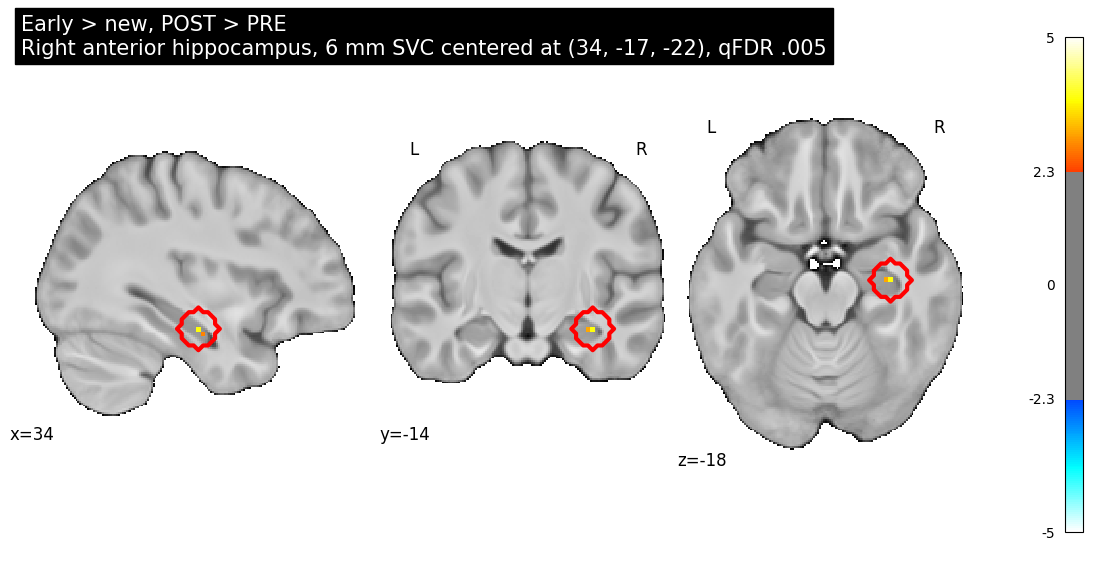

Saved figure with red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_early_new_right_anterior_deuker_spatial_WITH_red_circle.png


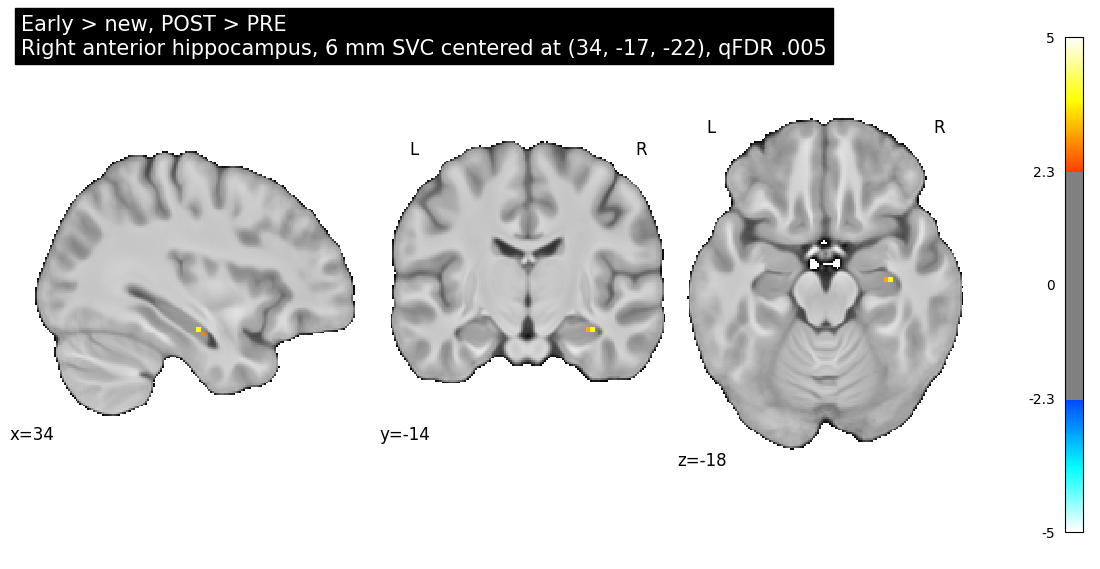

Saved figure without red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_early_new_right_anterior_deuker_spatial_NO_red_circle.png

Processing: Middle > Late, POST > PRE
Sphere: Bellmund same-sequence L anterior HPC (-24.0, -13.0, -20.0)
Peak in sphere: (-28.5, -14.5, -18.0)
z: 3.709643602371216
pBonf sphere: .006
qFDR sphere: .006


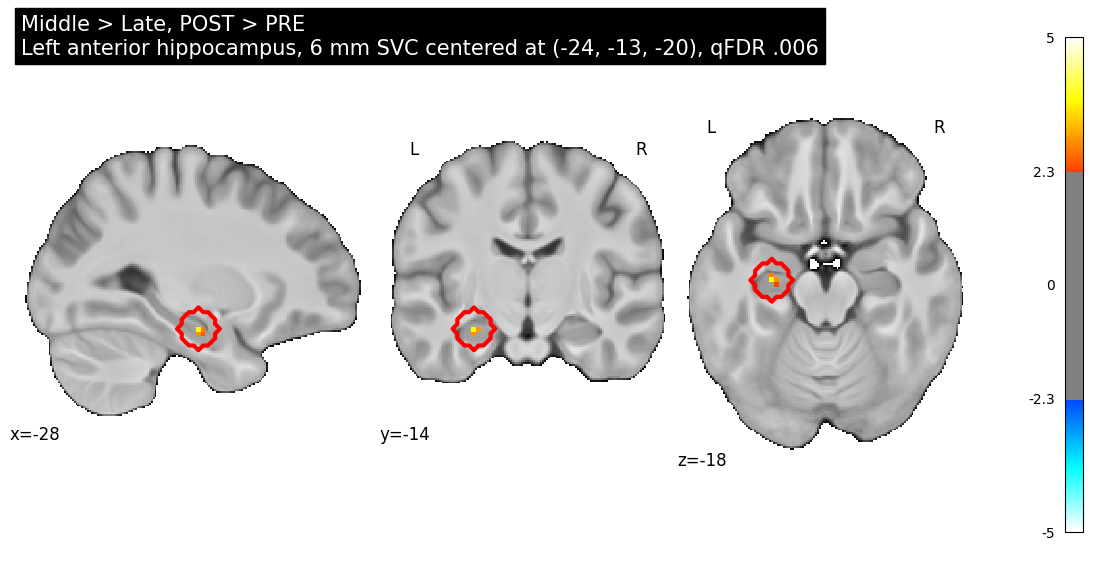

Saved figure with red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_middle_late_left_anterior_bellmund_same_sequence_WITH_red_circle.png


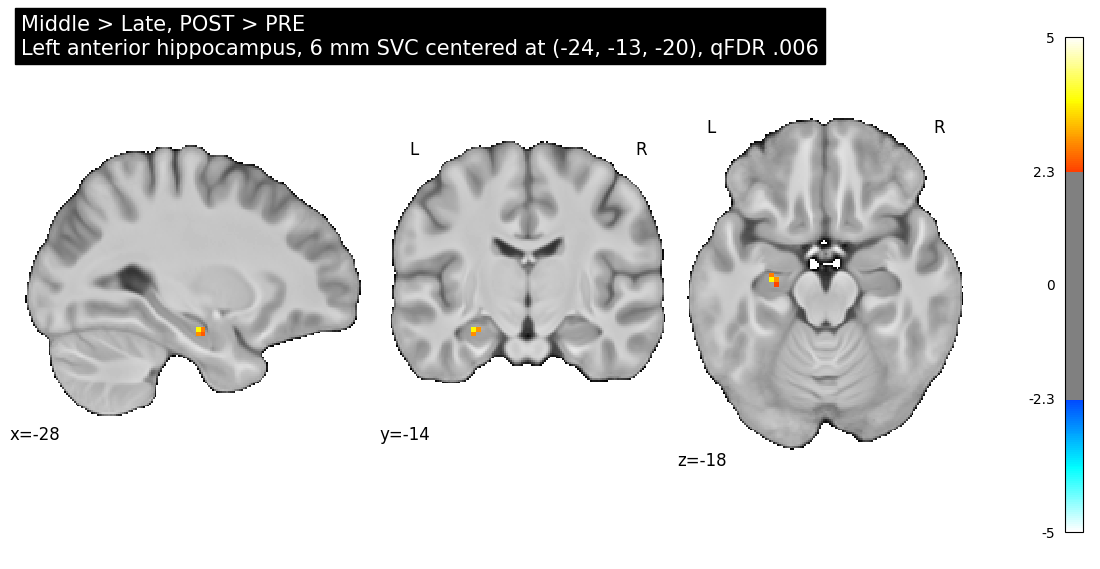

Saved figure without red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_middle_late_left_anterior_bellmund_same_sequence_NO_red_circle.png

Processing: Early > Late, POST > PRE
Sphere: Bellmund interaction R anterior HPC (31.0, -16.0, -21.0)
Peak in sphere: (34.0, -12.0, -18.0)
z: 3.2949905395507812
pBonf sphere: .028
qFDR sphere: .028


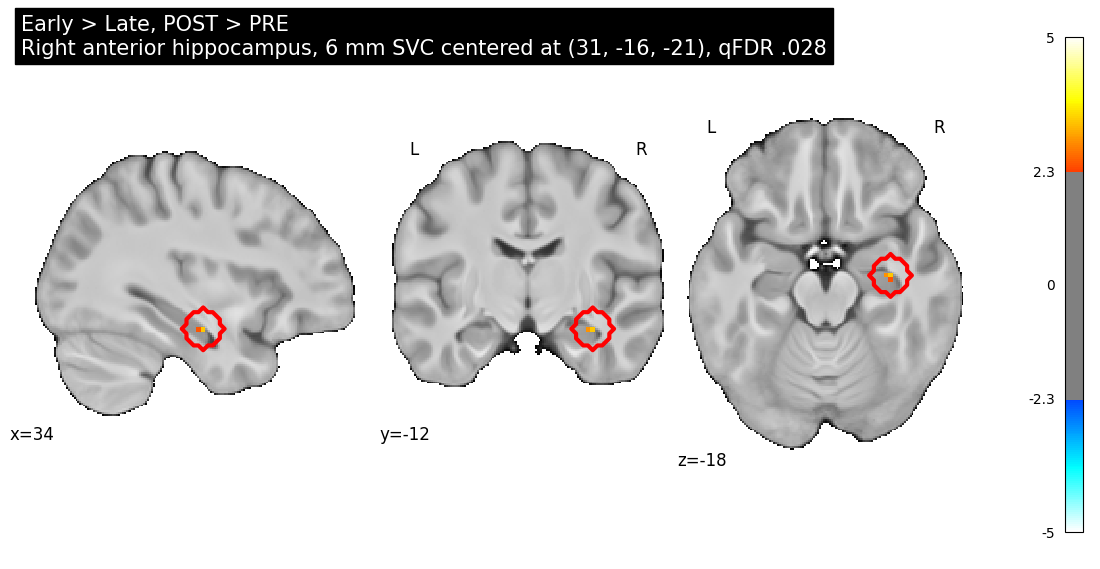

Saved figure with red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_early_late_right_anterior_bellmund_interaction_WITH_red_circle.png


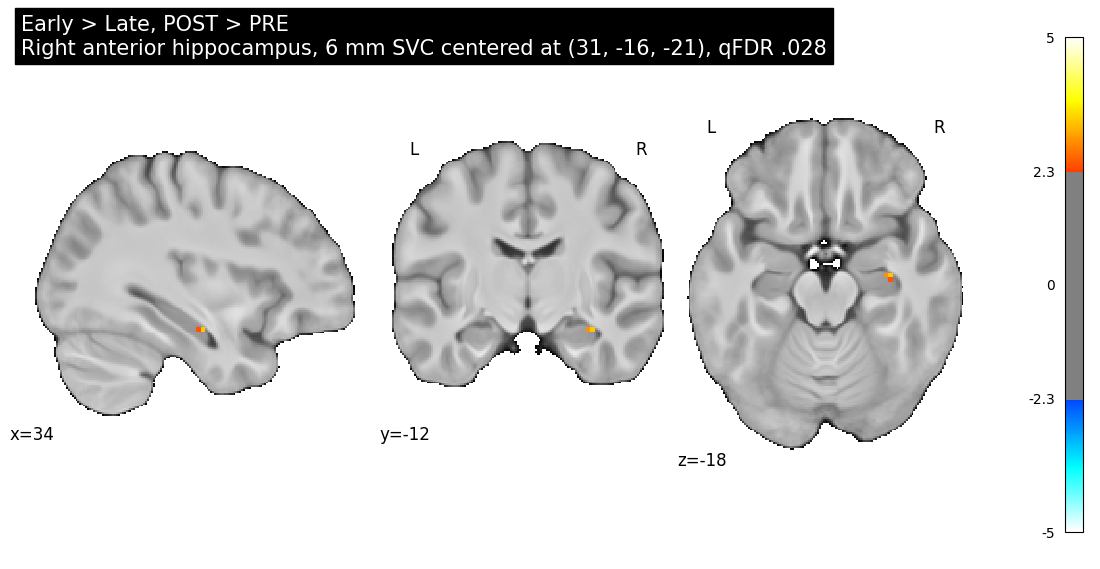

Saved figure without red circle:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_early_late_right_anterior_bellmund_interaction_NO_red_circle.png

Final selected literature SVC results:


,Result,Contrast,Region,Literature sphere,Paper,Sphere center,Peak in sphere,z,p unc.,pBonf sphere,qFDR sphere,n voxels,Concept,Nearby support
0,Main encoding-position effect,"Early > new, POST > PRE",Right anterior hippocampus,Deuker spatial R anterior HPC,Deuker et al.,"(34, -17, -22)","(34, -14, -18)",3.78,< .001,.005,.005,61,Spatial distance / close spatial relationships,Also supported by Deuker space-time R anterior HPC and Bellmund interaction R anterior HPC
1,Secondary encoding-position effect,"Middle > Late, POST > PRE",Left anterior hippocampus,Bellmund same-sequence L anterior HPC,Bellmund et al. 2022,"(-24, -13, -20)","(-28, -14, -18)",3.71,< .001,.006,.006,56,"Constructed event-time relations, same sequence",Also supported by Bellmund across-sequence L anterior HPC
2,Supportive encoded-position effect,"Early > Late, POST > PRE",Right anterior hippocampus,Bellmund interaction R anterior HPC,Bellmund et al. 2022,"(31, -16, -21)","(34, -12, -18)",3.29,< .001,.028,.028,56,Temporal-distance representation differs for same vs different sequences,Same right anterior neighborhood as Early > new


Saved final SVC table CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_results.csv


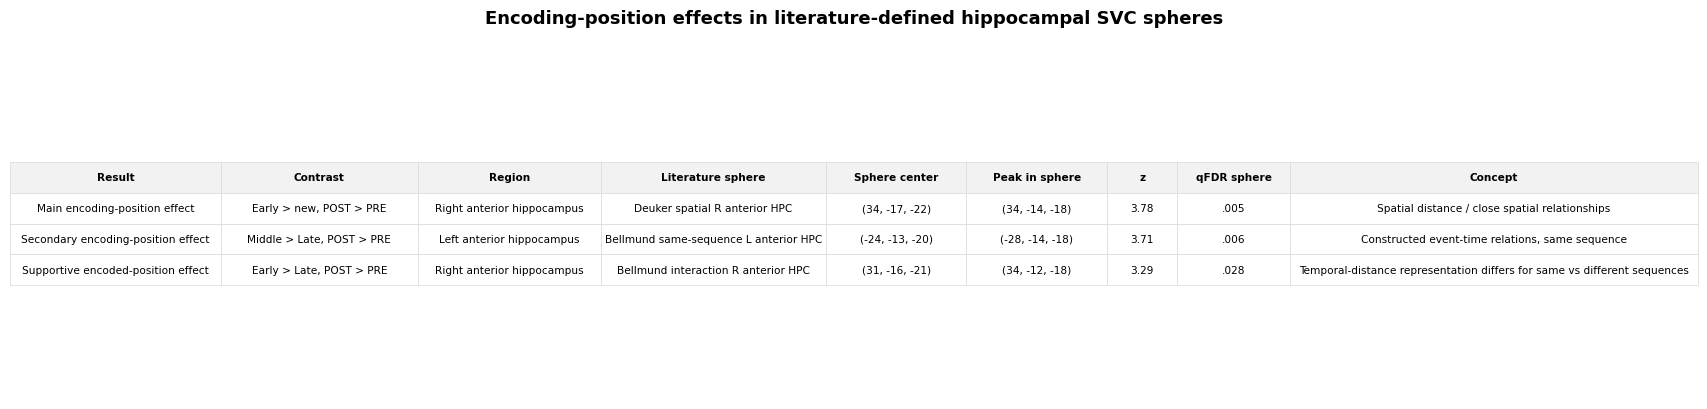

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_results_table.png

Compact slide table:


,Contrast,Region,Sphere,Peak,z,qFDR,Role
0,Early > new,Right anterior hippocampus,Deuker spatial R anterior HPC,"(34, -14, -18)",3.78,.005,Main encoding-position effect
1,Middle > Late,Left anterior hippocampus,Bellmund same-sequence L anterior HPC,"(-28, -14, -18)",3.71,.006,Secondary encoding-position effect
2,Early > Late,Right anterior hippocampus,Bellmund interaction R anterior HPC,"(34, -12, -18)",3.29,.028,Supportive encoded-position effect


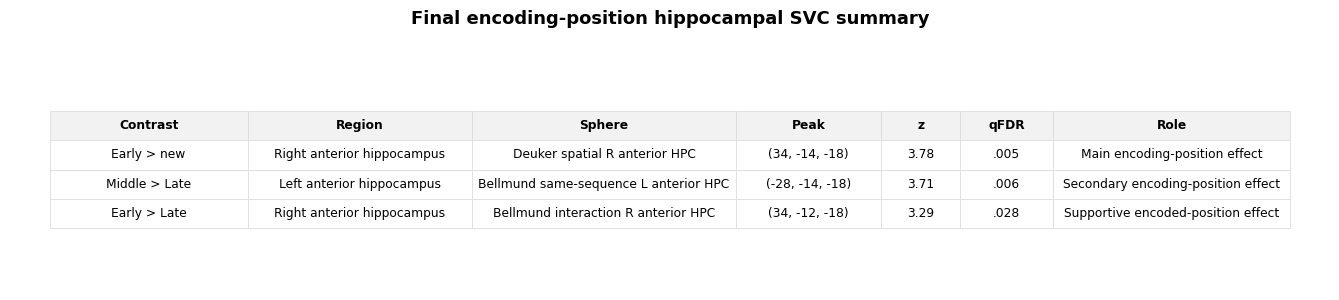

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_compact_slide_table.png

Saved caption:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_caption.txt

Figure paths:


,result,with_red,without_red
0,early_new_right_anterior_deuker_spatial,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...
1,middle_late_left_anterior_bellmund_same_sequence,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...
2,early_late_right_anterior_bellmund_interaction,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_liter...



Recommended outputs:
Final SVC table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_results_table.png
Compact slide table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_compact_slide_table.png
Caption: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean/pre_post_encoding_space_early_middle_late_control_glm_FINAL_selected_literature_SVC_caption.txt
Figure paths CSV: /media/RCPNAS/Data3/Alison_islan

In [31]:
# ============================================================
# FINAL Notebook 11 figures + SVC table
#
# Clean final set:
# 1) Early > new, POST > PRE
#    Right anterior hippocampus, Deuker spatial sphere
#
# 2) Middle > Late, POST > PRE
#    Left anterior hippocampus, Bellmund same-sequence sphere
#
# 3) Early > Late, POST > PRE
#    Right anterior hippocampus, Bellmund interaction sphere
#
# Figures follow the same style as Notebook 10:
# - activation displayed only inside the selected 6 mm literature SVC sphere
# - optional red visual guide around observed peak
# - no black crosshair
# - concise title with SVC center and pSVC/qFDR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

final_encoding_fig_dir = (
    dirs["figures"]
    / "final_encoding_position_literature_svc_clean"
)

final_encoding_table_dir = (
    dirs["tables"]
    / "final_encoding_position_literature_svc_clean"
)

final_encoding_fig_dir.mkdir(parents=True, exist_ok=True)
final_encoding_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving final figures to:", final_encoding_fig_dir)
print("Saving final tables to:", final_encoding_table_dir)

# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

SVC_RADIUS_MM = 6.0
VISUAL_RING_RADIUS_MM = 10.0
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

# ------------------------------------------------------------
# Final selected effects
# ------------------------------------------------------------
# These are the clean effects that stay in the final Notebook 11 story.

FINAL_SELECTED_EFFECTS = [
    {
        "result_name": "early_new_right_anterior_deuker_spatial",
        "contrast": "early_gt_new_post_gt_pre",
        "contrast_label": "Early > new, POST > PRE",
        "observed_peak": (34.0, -14.0, -18.0),
        "paper": "Deuker et al.",
        "sphere_name": "Deuker spatial R anterior HPC",
        "sphere_center": (34.0, -17.0, -22.0),
        "concept": "Spatial distance / close spatial relationships",
        "region_label": "Right anterior hippocampus",
        "role": "Main encoding-position effect",
        "supporting_nearby_spheres": (
            "Also supported by Deuker space-time R anterior HPC "
            "and Bellmund interaction R anterior HPC"
        ),
    },
    {
        "result_name": "middle_late_left_anterior_bellmund_same_sequence",
        "contrast": "middle_gt_late_post_gt_pre",
        "contrast_label": "Middle > Late, POST > PRE",
        "observed_peak": (-28.0, -14.0, -18.0),
        "paper": "Bellmund et al. 2022",
        "sphere_name": "Bellmund same-sequence L anterior HPC",
        "sphere_center": (-24.0, -13.0, -20.0),
        "concept": "Constructed event-time relations, same sequence",
        "region_label": "Left anterior hippocampus",
        "role": "Secondary encoding-position effect",
        "supporting_nearby_spheres": (
            "Also supported by Bellmund across-sequence L anterior HPC"
        ),
    },
    {
        "result_name": "early_late_right_anterior_bellmund_interaction",
        "contrast": "early_gt_late_post_gt_pre",
        "contrast_label": "Early > Late, POST > PRE",
        "observed_peak": (34.0, -12.0, -18.0),
        "paper": "Bellmund et al. 2022",
        "sphere_name": "Bellmund interaction R anterior HPC",
        "sphere_center": (31.0, -16.0, -21.0),
        "concept": (
            "Temporal-distance representation differs for same vs different sequences"
        ),
        "region_label": "Right anterior hippocampus",
        "role": "Supportive encoded-position effect",
        "supporting_nearby_spheres": (
            "Same right anterior neighborhood as Early > new"
        ),
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    """Create a binary MNI sphere mask on the grid of reference_img."""
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_sphere_svc(z_img, sphere_img, direction="positive"):
    """Voxelwise p/q calculation inside fixed 6 mm literature sphere."""
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be 'positive' or 'negative'.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)


# ------------------------------------------------------------
# Main loop:
# compute SVC and create figures for each selected effect
# ------------------------------------------------------------

final_svc_rows = []
figure_paths = []

for effect in FINAL_SELECTED_EFFECTS:

    contrast_name = effect["contrast"]

    print("\n" + "=" * 80)
    print("Processing:", effect["contrast_label"])
    print("Sphere:", effect["sphere_name"], effect["sphere_center"])

    # Load z-map
    z_map_path = Path(
        second_level_table.loc[
            second_level_table["contrast"] == contrast_name,
            "z_map_path",
        ].iloc[0]
    )

    z_img = load_img(str(z_map_path))

    # Create true 6 mm SVC sphere
    svc_sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=effect["sphere_center"],
        radius_mm=SVC_RADIUS_MM,
    )

    svc_sphere_resampled = resample_to_img(
        svc_sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    svc_sphere_path = (
        final_encoding_table_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_6mm_SVC_sphere_mask.nii.gz"
    )

    svc_sphere_resampled.to_filename(str(svc_sphere_path))

    # Run SVC
    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=svc_sphere_resampled,
        direction="positive",
    )

    p_svc_label = fmt_p(svc_result["peak_p_bonferroni_within_sphere"])
    q_svc_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])

    peak = (
        svc_result["peak_x"],
        svc_result["peak_y"],
        svc_result["peak_z_coord"],
    )

    print("Peak in sphere:", peak)
    print("z:", svc_result["peak_z_stat"])
    print("pBonf sphere:", p_svc_label)
    print("qFDR sphere:", q_svc_label)

    # Mask activation to the true 6 mm SVC sphere
    masked_z_img = math_img(
        "zmap * (sphere > 0)",
        zmap=z_img,
        sphere=svc_sphere_resampled,
    )

    masked_z_path = (
        final_encoding_table_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_zmap_masked_to_6mm_SVC_sphere.nii.gz"
    )

    masked_z_img.to_filename(str(masked_z_path))

    # Visual-only red ring around observed peak
    visual_ring_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=peak,
        radius_mm=VISUAL_RING_RADIUS_MM,
    )

    visual_ring_resampled = resample_to_img(
        visual_ring_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    # Title: concise, same style as Notebook 10
    title_text = (
        f"{effect['contrast_label']}\n"
        f"{effect['region_label']}, 6 mm SVC centered at "
        f"{fmt_coord(*effect['sphere_center'])}, qFDR {q_svc_label}"
    )

    # -----------------------
    # Figure WITH red circle
    # -----------------------

    fig_with_red_png = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_WITH_red_circle.png"
    )

    fig_with_red_pdf = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_WITH_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    stat_display.add_contours(
        visual_ring_resampled,
        levels=[0.5],
        colors=["red"],
        linewidths=3.0,
    )

    fig.savefig(fig_with_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_with_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved figure with red circle:")
    print(fig_with_red_png)

    # --------------------------
    # Figure WITHOUT red circle
    # --------------------------

    fig_no_red_png = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_NO_red_circle.png"
    )

    fig_no_red_pdf = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_NO_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_no_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_no_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved figure without red circle:")
    print(fig_no_red_png)

    figure_paths.append({
        "result": effect["result_name"],
        "with_red": str(fig_with_red_png),
        "without_red": str(fig_no_red_png),
    })

    # Add row to final SVC table
    final_svc_rows.append({
        "Result": effect["role"],
        "Contrast": effect["contrast_label"],
        "Region": effect["region_label"],
        "Literature sphere": effect["sphere_name"],
        "Paper": effect["paper"],
        "Sphere center": fmt_coord(*effect["sphere_center"]),
        "Peak in sphere": fmt_coord(
            svc_result["peak_x"],
            svc_result["peak_y"],
            svc_result["peak_z_coord"],
        ),
        "z": f"{svc_result['peak_z_stat']:.2f}",
        "p unc.": fmt_p(svc_result["peak_p_uncorrected"]),
        "pBonf sphere": fmt_p(svc_result["peak_p_bonferroni_within_sphere"]),
        "qFDR sphere": fmt_p(svc_result["peak_q_fdr_within_sphere"]),
        "n voxels": svc_result["n_voxels_in_sphere"],
        "Concept": effect["concept"],
        "Nearby support": effect["supporting_nearby_spheres"],
    })

# ------------------------------------------------------------
# Final SVC table
# ------------------------------------------------------------

final_encoding_svc_table = pd.DataFrame(final_svc_rows)

final_encoding_svc_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_results.csv"
)

final_encoding_svc_table.to_csv(final_encoding_svc_csv, index=False)

print("\nFinal selected literature SVC results:")
display(final_encoding_svc_table)

print("Saved final SVC table CSV:")
print(final_encoding_svc_csv)

final_encoding_svc_png = (
    final_encoding_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_results_table.png"
)

save_clean_table_png(
    final_encoding_svc_table[
        [
            "Result",
            "Contrast",
            "Region",
            "Literature sphere",
            "Sphere center",
            "Peak in sphere",
            "z",
            "qFDR sphere",
            "Concept",
        ]
    ],
    final_encoding_svc_png,
    title="Encoding-position effects in literature-defined hippocampal SVC spheres",
    fontsize=7.6,
    header_fontsize=7.6,
    scale_y=1.7,
    col_widths=[0.15, 0.14, 0.13, 0.16, 0.10, 0.10, 0.05, 0.08, 0.29],
    figsize=(17, 4.2),
)

# ------------------------------------------------------------
# Compact slide table
# ------------------------------------------------------------

compact_rows = []

for row in final_svc_rows:
    compact_rows.append({
        "Contrast": row["Contrast"].replace(", POST > PRE", ""),
        "Region": row["Region"],
        "Sphere": row["Literature sphere"],
        "Peak": row["Peak in sphere"],
        "z": row["z"],
        "qFDR": row["qFDR sphere"],
        "Role": row["Result"],
    })

compact_final_table = pd.DataFrame(compact_rows)

compact_final_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_compact_slide_table.csv"
)

compact_final_table.to_csv(compact_final_csv, index=False)

print("\nCompact slide table:")
display(compact_final_table)

compact_final_png = (
    final_encoding_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_compact_slide_table.png"
)

save_clean_table_png(
    compact_final_table,
    compact_final_png,
    title="Final encoding-position hippocampal SVC summary",
    fontsize=8.8,
    header_fontsize=8.8,
    scale_y=1.75,
    col_widths=[0.15, 0.17, 0.20, 0.11, 0.06, 0.07, 0.18],
    figsize=(13.5, 3.1),
)

# ------------------------------------------------------------
# Caption / interpretation text
# ------------------------------------------------------------

caption_text = """
Figure caption:
Group-level POST > PRE encoding-position contrasts displayed only within independently defined 6 mm literature SVC spheres. For each result, activation is masked to the selected literature sphere; the red contour is a visual guide around the observed peak and does not define the statistical test.

Interpretation:
The final encoding-position analysis focuses on three clean hippocampal effects. Early > new showed a right anterior hippocampal effect within the Deuker spatial-distance sphere, consistent with an Island-related route/context signal for early-route images. Middle > Late showed a left anterior hippocampal effect within the Bellmund same-sequence sphere, suggesting sensitivity to event-position structure. Early > Late provided additional right anterior support in the Bellmund interaction sphere. Together, these results suggest that encoding-position information is expressed mainly in anterior hippocampal event-map regions, contrasting with the posterior hippocampal episode-time effect from Notebook 10.
""".strip()

caption_path = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_caption.txt"
)

caption_path.write_text(caption_text)

print("\nSaved caption:")
print(caption_path)

# ------------------------------------------------------------
# Summary of saved outputs
# ------------------------------------------------------------

figure_paths_df = pd.DataFrame(figure_paths)

figure_paths_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_selected_literature_SVC_figure_paths.csv"
)

figure_paths_df.to_csv(figure_paths_csv, index=False)

print("\nFigure paths:")
display(figure_paths_df)

print("\nRecommended outputs:")
print("Final SVC table:", final_encoding_svc_png)
print("Compact slide table:", compact_final_png)
print("Caption:", caption_path)
print("Figure paths CSV:", figure_paths_csv)

In [32]:
# ============================================================
# Targeted SVC test:
# Early > Late, POST > PRE in right anterior Deuker/Bellmund spheres
#
# Goal:
# Check whether Early > Late also survives in Deuker spatial / space-time spheres,
# not only in the Bellmund interaction sphere.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

import nibabel as nib
from nilearn.image import load_img, new_img_like, resample_to_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

TARGET_CONTRAST = "early_gt_late_post_gt_pre"
TARGET_CONTRAST_LABEL = "Early > Late, POST > PRE"
SVC_RADIUS_MM = 6.0

target_svc_dir = (
    dirs["tables"]
    / "final_encoding_position_literature_svc_clean"
    / "targeted_early_gt_late_deuker_test"
)
target_svc_dir.mkdir(parents=True, exist_ok=True)

print("Saving targeted SVC table to:", target_svc_dir)

# ------------------------------------------------------------
# Spheres to test
# ------------------------------------------------------------

TARGET_SPHERES = [
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker spatial R anterior HPC",
        "center": (34.0, -17.0, -22.0),
        "concept": "Spatial distance / close spatial relationships",
        "priority": "Best spatial-route interpretation",
    },
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker space-time R anterior HPC",
        "center": (32.0, -17.0, -22.0),
        "concept": "Combined spatial and temporal proximity",
        "priority": "Best event-map interpretation",
    },
    {
        "paper": "Deuker et al.",
        "sphere": "Deuker temporal R anterior HPC",
        "center": (26.0, -18.0, -22.0),
        "concept": "Temporal distance / close temporal relationships",
        "priority": "Temporal event-map support",
    },
    {
        "paper": "Bellmund et al. 2022",
        "sphere": "Bellmund interaction R anterior HPC",
        "center": (31.0, -16.0, -21.0),
        "concept": "Temporal-distance representation differs for same vs different sequences",
        "priority": "Previously observed strongest Early > Late SVC",
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_target_sphere_svc(z_img, sphere_img):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere has zero voxels."

    z_inside = z_data[sphere_data]

    peak_index = int(np.nanargmax(z_inside))
    peak_z = float(z_inside[peak_index])

    p_values = norm.sf(z_inside)
    peak_p_unc = float(norm.sf(peak_z))

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))
    peak_q_fdr = float(q_values[peak_index])

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    return {
        "n_voxels": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "p_unc": peak_p_unc,
        "pBonf_sphere": peak_p_bonf,
        "qFDR_sphere": peak_q_fdr,
        "n_voxels_q_lt_05": int(np.sum(q_values < 0.05)),
        "n_voxels_p_unc_lt_001": int(np.sum(p_values < 0.001)),
    }


def fmt_p(x):
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


# ------------------------------------------------------------
# Load Early > Late z-map
# ------------------------------------------------------------

z_map_path = Path(
    second_level_table.loc[
        second_level_table["contrast"] == TARGET_CONTRAST,
        "z_map_path",
    ].iloc[0]
)

z_img = load_img(str(z_map_path))

print("Target contrast:", TARGET_CONTRAST_LABEL)
print("z-map:", z_map_path)

# ------------------------------------------------------------
# Run SVC in each target sphere
# ------------------------------------------------------------

rows = []

for sphere in TARGET_SPHERES:

    center = sphere["center"]

    sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=center,
        radius_mm=SVC_RADIUS_MM,
    )

    sphere_path = (
        target_svc_dir
        / f"{ANALYSIS_NAME}_{TARGET_CONTRAST}_{sphere['sphere'].replace(' ', '_')}_6mm_mask.nii.gz"
    )
    sphere_img.to_filename(str(sphere_path))

    result = run_target_sphere_svc(
        z_img=z_img,
        sphere_img=sphere_img,
    )

    peak = (
        result["peak_x"],
        result["peak_y"],
        result["peak_z_coord"],
    )

    dist_to_center = float(
        np.linalg.norm(np.array(peak) - np.array(center))
    )

    rows.append({
        "Contrast": TARGET_CONTRAST_LABEL,
        "Paper": sphere["paper"],
        "Sphere": sphere["sphere"],
        "Sphere center": fmt_coord(*center),
        "Concept": sphere["concept"],
        "Priority": sphere["priority"],
        "Peak in sphere": fmt_coord(*peak),
        "Distance peak-center mm": f"{dist_to_center:.1f}",
        "z": f"{result['peak_z_stat']:.2f}",
        "p unc.": fmt_p(result["p_unc"]),
        "pBonf sphere": fmt_p(result["pBonf_sphere"]),
        "qFDR sphere": fmt_p(result["qFDR_sphere"]),
        "n voxels": result["n_voxels"],
        "n q<.05 voxels": result["n_voxels_q_lt_05"],
        "SVC interpretation": (
            "FDR-supported"
            if result["qFDR_sphere"] < 0.05
            else "Exploratory only"
        ),
        "sphere_mask_path": str(sphere_path),
    })

early_late_target_svc_table = pd.DataFrame(rows)

# Sort by qFDR, then z
early_late_target_svc_table["_q"] = early_late_target_svc_table["qFDR sphere"].replace("< .001", ".000").str.replace(".", "0.", regex=False)
early_late_target_svc_table = early_late_target_svc_table.drop(columns=["_q"])

target_svc_csv = (
    target_svc_dir
    / f"{ANALYSIS_NAME}_{TARGET_CONTRAST}_targeted_Deuker_Bellmund_SVC.csv"
)

early_late_target_svc_table.to_csv(target_svc_csv, index=False)

print("\nTargeted Early > Late SVC table:")
display(
    early_late_target_svc_table[
        [
            "Contrast",
            "Paper",
            "Sphere",
            "Sphere center",
            "Peak in sphere",
            "z",
            "p unc.",
            "pBonf sphere",
            "qFDR sphere",
            "SVC interpretation",
            "Concept",
        ]
    ]
)

print("Saved:")
print(target_svc_csv)

Saving targeted SVC table to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean/targeted_early_gt_late_deuker_test
Target contrast: Early > Late, POST > PRE
z-map: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/second_level_from_smoothed5mm/maps/group_early_gt_late_post_gt_pre_smoothed5mm_zmap.nii.gz

Targeted Early > Late SVC table:


,Contrast,Paper,Sphere,Sphere center,Peak in sphere,z,p unc.,pBonf sphere,qFDR sphere,SVC interpretation,Concept
0,"Early > Late, POST > PRE",Deuker et al.,Deuker spatial R anterior HPC,"(34, -17, -22)","(36, -14, -18)",2.50,.006,.379,.229,Exploratory only,Spatial distance / close spatial relationships
1,"Early > Late, POST > PRE",Deuker et al.,Deuker space-time R anterior HPC,"(32, -17, -22)","(34, -14, -18)",2.43,.008,.413,.312,Exploratory only,Combined spatial and temporal proximity
2,"Early > Late, POST > PRE",Deuker et al.,Deuker temporal R anterior HPC,"(26, -18, -22)","(29, -20, -23)",1.92,.028,1.000,.402,Exploratory only,Temporal distance / close temporal relationships
3,"Early > Late, POST > PRE",Bellmund et al. 2022,Bellmund interaction R anterior HPC,"(31, -16, -21)","(34, -12, -18)",3.29,< .001,.028,.028,FDR-supported,Temporal-distance representation differs for same vs different sequences


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_literature_svc_clean/targeted_early_gt_late_deuker_test/pre_post_encoding_space_early_middle_late_control_glm_early_gt_late_post_gt_pre_targeted_Deuker_Bellmund_SVC.csv


Saving final figures to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event_position_svc
Saving final tables to: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_event_position_svc

Processing: Early > Late, POST > PRE
Sphere: Bellmund interaction R anterior HPC (31.0, -16.0, -21.0)
Plot figure: True
Peak in sphere: (34.0, -12.0, -18.0)
z: 3.2949905395507812
p unc: < .001
pBonf sphere: .028
qFDR sphere: .028


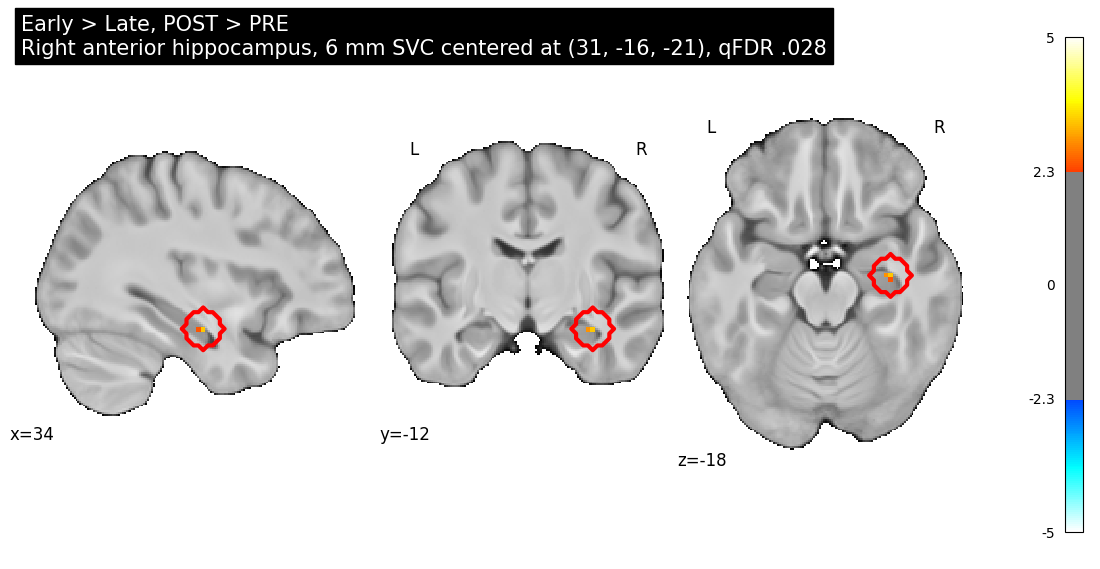

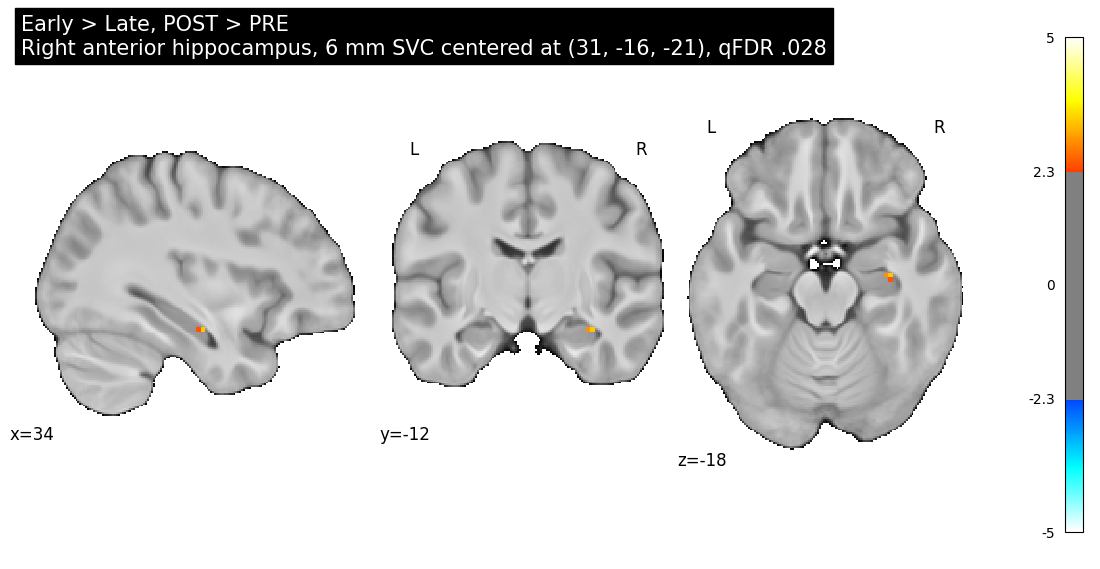


Processing: Middle > Late, POST > PRE
Sphere: Bellmund same-sequence L anterior HPC (-24.0, -13.0, -20.0)
Plot figure: True
Peak in sphere: (-28.5, -14.5, -18.0)
z: 3.709643602371216
p unc: < .001
pBonf sphere: .006
qFDR sphere: .006


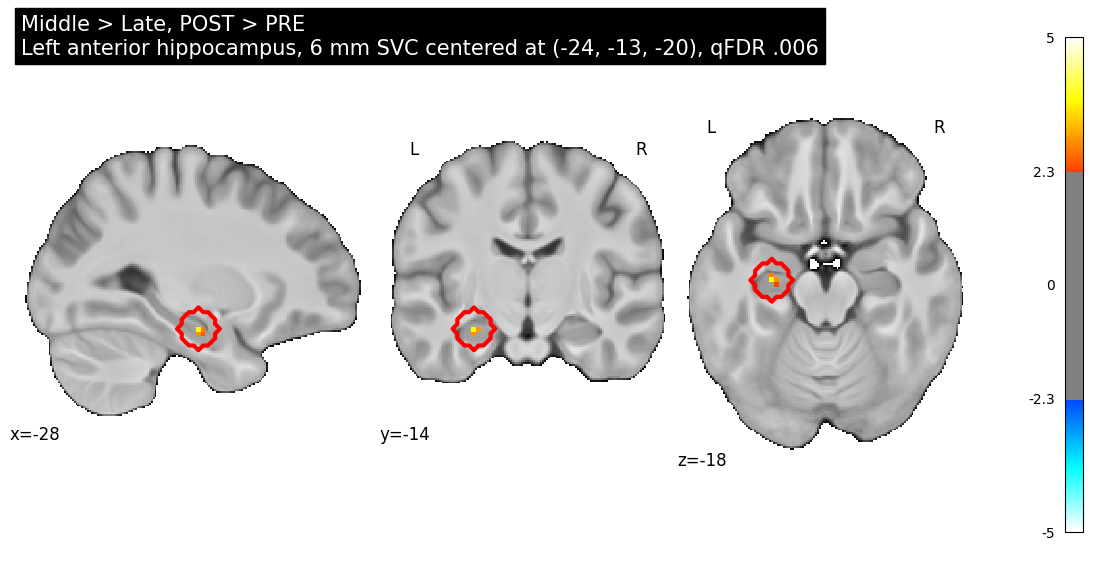

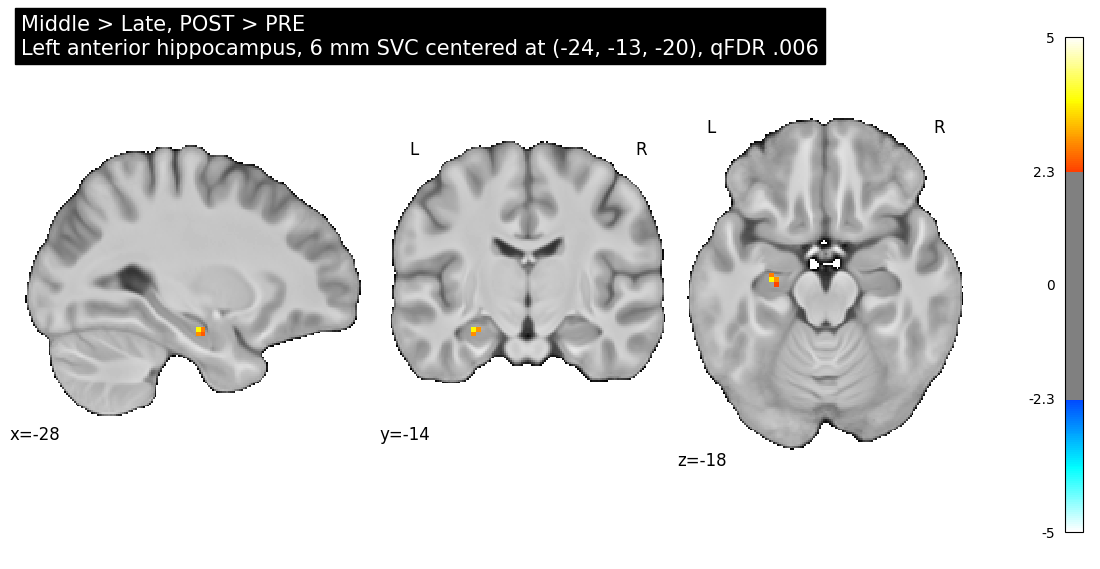


Processing: Early > new, POST > PRE
Sphere: Bellmund interaction R anterior HPC (31.0, -16.0, -21.0)
Plot figure: False
Peak in sphere: (34.0, -14.5, -18.0)
z: 3.7803285121917725
p unc: < .001
pBonf sphere: .004
qFDR sphere: .003

Final event-position literature SVC results:


,Role,Contrast,Region,Literature sphere,Paper,Sphere center,Peak in sphere,z,p unc.,pBonf sphere,qFDR sphere,n voxels,Concept,Interpretation,Nearby support
0,Main event-position effect,"Early > Late, POST > PRE",Right anterior hippocampus,Bellmund interaction R anterior HPC,Bellmund et al. 2022,"(31, -16, -21)","(34, -12, -18)",3.29,< .001,.028,.028,56,Temporal-distance / event-position representation,Early-route images show stronger post-encoding signal than late-route images in right anterior hippocampus.,"Same right anterior neighborhood as Deuker spatial/space-time coordinates, but Deuker SVC for this specific contrast is weaker."
1,Secondary event-position effect,"Middle > Late, POST > PRE",Left anterior hippocampus,Bellmund same-sequence L anterior HPC,Bellmund et al. 2022,"(-24, -13, -20)","(-28, -14, -18)",3.71,< .001,.006,.006,56,"Constructed event-time relations, same sequence",Middle-route images show stronger post-encoding signal than late-route images in left anterior hippocampus.,Also supported by Bellmund across-sequence L anterior HPC.
2,Table-only contextual support,"Early > new, POST > PRE",Right anterior hippocampus,Bellmund interaction R anterior HPC,Bellmund et al. 2022,"(31, -16, -21)","(34, -14, -18)",3.78,< .001,.004,.003,56,Temporal-distance / event-structure representation,Early-route images also differ from never-encoded new images in the same right anterior event-map neighborhood.,Also supported by Deuker spatial and Deuker space-time R anterior HPC spheres.


Saved final SVC table CSV:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_literature_SVC_results.csv


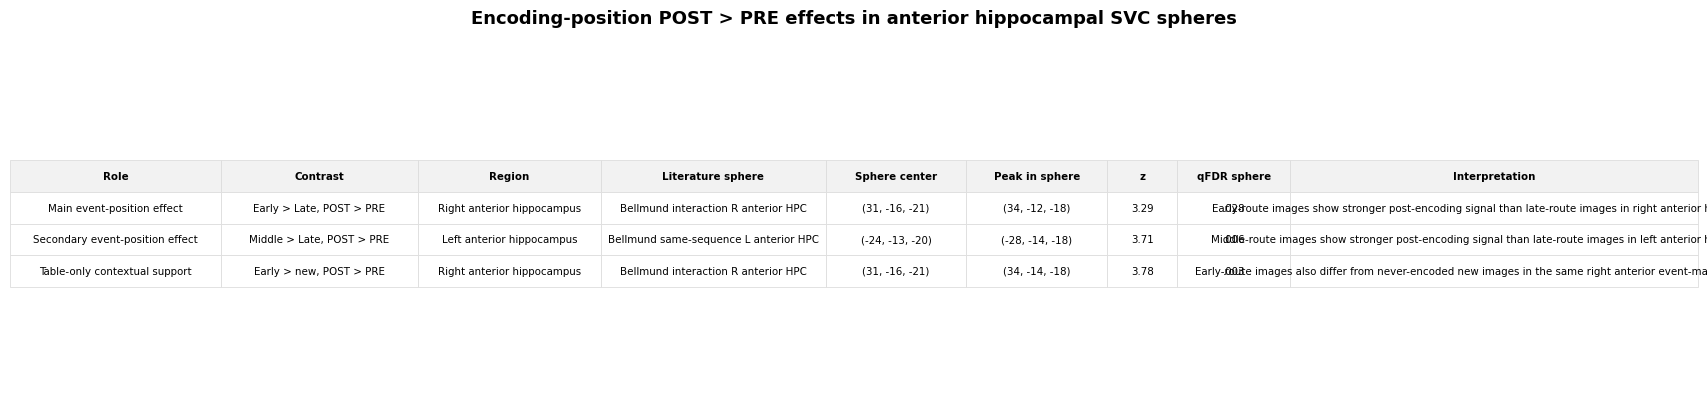

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_literature_SVC_results_table.png

Compact slide table:


,Contrast,Region,Sphere center,Peak,z,qFDR,Role
0,Early > Late,Right anterior hippocampus,"(31, -16, -21)","(34, -12, -18)",3.29,.028,Main event-position effect
1,Middle > Late,Left anterior hippocampus,"(-24, -13, -20)","(-28, -14, -18)",3.71,.006,Secondary event-position effect
2,Early > new,Right anterior hippocampus,"(31, -16, -21)","(34, -14, -18)",3.78,.003,Table-only contextual support


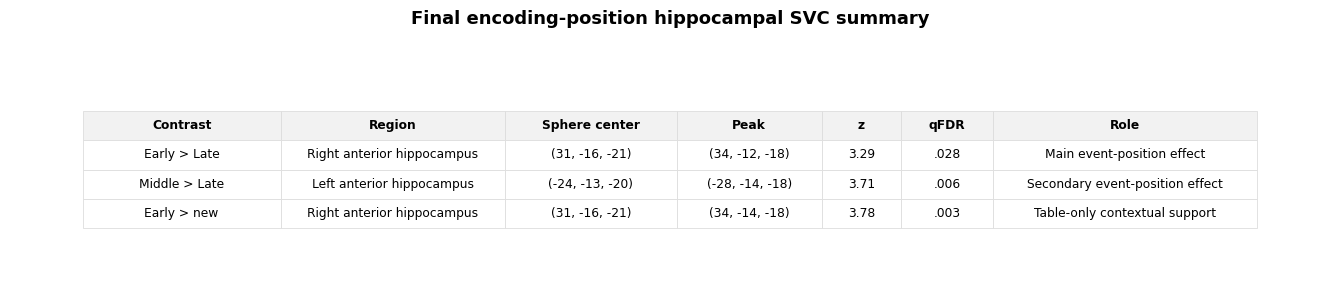

Saved table PNG:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_compact_slide_table.png

Figure paths:


,result,contrast,with_red,without_red
0,early_late_right_anterior_bellmund_interaction,"Early > Late, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event...
1,middle_late_left_anterior_bellmund_same_sequence,"Middle > Late, POST > PRE",/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event...



Saved caption:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/tables/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_caption.txt

Recommended outputs:
Final SVC table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_literature_SVC_results_table.png
Compact slide table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/pre_post_encoding_space_early_middle_late_control_glm/figures/final_encoding_position_event_position_svc/pre_post_encoding_space_early_middle_late_control_glm_FINAL_event_position_compact_slide_table.png
Caption: /media/RCPNAS/Data3/Alison_island/kroczak/island_sem

In [33]:
# ============================================================
# FINAL Notebook 11 figures + SVC table
#
# Final story:
# - Plot Early > Late, POST > PRE
# - Plot Middle > Late, POST > PRE
# - Keep Early > new, POST > PRE in table only
#
# Figures follow Notebook 10 style:
# - activation displayed only inside selected 6 mm literature SVC sphere
# - optional red visual guide around observed peak
# - no black crosshair
# - title includes contrast, region, SVC center, and qFDR
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import nibabel as nib
from nilearn import plotting
from nilearn.image import load_img, new_img_like, resample_to_img, math_img
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from IPython.display import display

# ------------------------------------------------------------
# Output folders
# ------------------------------------------------------------

final_encoding_fig_dir = (
    dirs["figures"]
    / "final_encoding_position_event_position_svc"
)

final_encoding_table_dir = (
    dirs["tables"]
    / "final_encoding_position_event_position_svc"
)

final_encoding_fig_dir.mkdir(parents=True, exist_ok=True)
final_encoding_table_dir.mkdir(parents=True, exist_ok=True)

print("Saving final figures to:", final_encoding_fig_dir)
print("Saving final tables to:", final_encoding_table_dir)

# ------------------------------------------------------------
# Display/settings
# ------------------------------------------------------------

SVC_RADIUS_MM = 6.0
VISUAL_RING_RADIUS_MM = 10.0
DISPLAY_THRESHOLD_Z = 2.33
VMAX = 5.0

# ------------------------------------------------------------
# Final selected effects
# ------------------------------------------------------------
# plot_figure=True means make brain images.
# plot_figure=False means compute SVC and include in the table only.

FINAL_SELECTED_EFFECTS = [
    {
        "result_name": "early_late_right_anterior_bellmund_interaction",
        "plot_figure": True,
        "contrast": "early_gt_late_post_gt_pre",
        "contrast_label": "Early > Late, POST > PRE",
        "paper": "Bellmund et al. 2022",
        "sphere_name": "Bellmund interaction R anterior HPC",
        "sphere_center": (31.0, -16.0, -21.0),
        "concept": "Temporal-distance / event-position representation",
        "region_label": "Right anterior hippocampus",
        "role": "Main event-position effect",
        "interpretation": (
            "Early-route images show stronger post-encoding signal than late-route images "
            "in right anterior hippocampus."
        ),
        "nearby_support": (
            "Same right anterior neighborhood as Deuker spatial/space-time coordinates, "
            "but Deuker SVC for this specific contrast is weaker."
        ),
    },
    {
        "result_name": "middle_late_left_anterior_bellmund_same_sequence",
        "plot_figure": True,
        "contrast": "middle_gt_late_post_gt_pre",
        "contrast_label": "Middle > Late, POST > PRE",
        "paper": "Bellmund et al. 2022",
        "sphere_name": "Bellmund same-sequence L anterior HPC",
        "sphere_center": (-24.0, -13.0, -20.0),
        "concept": "Constructed event-time relations, same sequence",
        "region_label": "Left anterior hippocampus",
        "role": "Secondary event-position effect",
        "interpretation": (
            "Middle-route images show stronger post-encoding signal than late-route images "
            "in left anterior hippocampus."
        ),
        "nearby_support": (
            "Also supported by Bellmund across-sequence L anterior HPC."
        ),
    },
    {
        "result_name": "early_new_right_anterior_bellmund_interaction",
        "plot_figure": False,
        "contrast": "early_gt_new_post_gt_pre",
        "contrast_label": "Early > new, POST > PRE",
        "paper": "Bellmund et al. 2022",
        "sphere_name": "Bellmund interaction R anterior HPC",
        "sphere_center": (31.0, -16.0, -21.0),
        "concept": "Temporal-distance / event-structure representation",
        "region_label": "Right anterior hippocampus",
        "role": "Table-only contextual support",
        "interpretation": (
            "Early-route images also differ from never-encoded new images in the same "
            "right anterior event-map neighborhood."
        ),
        "nearby_support": (
            "Also supported by Deuker spatial and Deuker space-time R anterior HPC spheres."
        ),
    },
]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def make_sphere_mask_img(reference_img, center_mni, radius_mm):
    ref_img = load_img(reference_img) if isinstance(reference_img, (str, Path)) else reference_img

    shape = ref_img.shape[:3]
    affine = ref_img.affine

    ijk = np.array(
        np.meshgrid(
            np.arange(shape[0]),
            np.arange(shape[1]),
            np.arange(shape[2]),
            indexing="ij",
        )
    ).reshape(3, -1).T

    xyz = nib.affines.apply_affine(affine, ijk)
    center = np.array(center_mni, dtype=float)

    distances = np.linalg.norm(xyz - center, axis=1)
    sphere_data = (distances <= radius_mm).reshape(shape).astype(np.uint8)

    return new_img_like(ref_img, sphere_data)


def run_sphere_svc(z_img, sphere_img, direction="positive"):
    sphere_resampled = resample_to_img(
        sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    z_data = z_img.get_fdata()
    sphere_data = sphere_resampled.get_fdata() > 0

    n_voxels = int(sphere_data.sum())
    assert n_voxels > 0, "Sphere mask has zero voxels."

    z_inside = z_data[sphere_data]

    if direction == "positive":
        peak_index = int(np.nanargmax(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(z_inside)
        peak_p_unc = float(norm.sf(peak_z))
    elif direction == "negative":
        peak_index = int(np.nanargmin(z_inside))
        peak_z = float(z_inside[peak_index])
        p_values = norm.sf(-z_inside)
        peak_p_unc = float(norm.sf(-peak_z))
    else:
        raise ValueError("direction must be 'positive' or 'negative'.")

    _, q_values, _, _ = multipletests(
        p_values,
        alpha=0.05,
        method="fdr_bh",
    )

    sphere_indices = np.array(np.where(sphere_data)).T
    peak_ijk = sphere_indices[peak_index]
    peak_mni = nib.affines.apply_affine(z_img.affine, peak_ijk)

    peak_q_fdr = float(q_values[peak_index])
    peak_p_bonf = float(min(peak_p_unc * n_voxels, 1.0))

    return {
        "n_voxels_in_sphere": n_voxels,
        "peak_x": float(peak_mni[0]),
        "peak_y": float(peak_mni[1]),
        "peak_z_coord": float(peak_mni[2]),
        "peak_z_stat": peak_z,
        "peak_p_uncorrected": peak_p_unc,
        "peak_p_bonferroni_within_sphere": peak_p_bonf,
        "peak_q_fdr_within_sphere": peak_q_fdr,
        "n_voxels_p_unc_lt_0_001": int(np.sum(p_values < 0.001)),
        "n_voxels_fdr_q_lt_0_05": int(np.sum(q_values < 0.05)),
    }


def fmt_p(x):
    if pd.isna(x):
        return "—"
    x = float(x)
    if x < 0.001:
        return "< .001"
    return f"{x:.3f}".replace("0.", ".")


def fmt_coord(x, y, z):
    return f"({x:.0f}, {y:.0f}, {z:.0f})"


def save_clean_table_png(
    df,
    out_path,
    title=None,
    fontsize=8.5,
    header_fontsize=8.5,
    scale_y=1.65,
    col_widths=None,
    figsize=None,
):
    n_rows, n_cols = df.shape

    if figsize is None:
        figsize = (max(10, n_cols * 1.5), max(2.8, n_rows * 0.55 + 1.2))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.axis("off")

    if col_widths is None:
        col_widths = [1 / n_cols] * n_cols

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=col_widths,
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, scale_y)

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#DDDDDD")
        cell.set_linewidth(0.6)

        if row == 0:
            cell.set_text_props(weight="bold", fontsize=header_fontsize)
            cell.set_facecolor("#F2F2F2")
        else:
            cell.set_facecolor("white")

    if title:
        ax.set_title(title, fontsize=13, weight="bold", pad=18)

    plt.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print("Saved table PNG:")
    print(out_path)

# ------------------------------------------------------------
# Main loop:
# compute SVC for all selected effects, plot only requested ones
# ------------------------------------------------------------

final_svc_rows = []
figure_paths = []

for effect in FINAL_SELECTED_EFFECTS:

    contrast_name = effect["contrast"]

    print("\n" + "=" * 80)
    print("Processing:", effect["contrast_label"])
    print("Sphere:", effect["sphere_name"], effect["sphere_center"])
    print("Plot figure:", effect["plot_figure"])

    # Load z-map
    z_map_path = Path(
        second_level_table.loc[
            second_level_table["contrast"] == contrast_name,
            "z_map_path",
        ].iloc[0]
    )

    z_img = load_img(str(z_map_path))

    # Create true 6 mm SVC sphere
    svc_sphere_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=effect["sphere_center"],
        radius_mm=SVC_RADIUS_MM,
    )

    svc_sphere_resampled = resample_to_img(
        svc_sphere_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    svc_sphere_path = (
        final_encoding_table_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_6mm_SVC_sphere_mask.nii.gz"
    )

    svc_sphere_resampled.to_filename(str(svc_sphere_path))

    # Run SVC
    svc_result = run_sphere_svc(
        z_img=z_img,
        sphere_img=svc_sphere_resampled,
        direction="positive",
    )

    q_svc_label = fmt_p(svc_result["peak_q_fdr_within_sphere"])
    p_unc_label = fmt_p(svc_result["peak_p_uncorrected"])
    p_bonf_label = fmt_p(svc_result["peak_p_bonferroni_within_sphere"])

    peak = (
        svc_result["peak_x"],
        svc_result["peak_y"],
        svc_result["peak_z_coord"],
    )

    print("Peak in sphere:", peak)
    print("z:", svc_result["peak_z_stat"])
    print("p unc:", p_unc_label)
    print("pBonf sphere:", p_bonf_label)
    print("qFDR sphere:", q_svc_label)

    # Mask activation to the true 6 mm SVC sphere
    masked_z_img = math_img(
        "zmap * (sphere > 0)",
        zmap=z_img,
        sphere=svc_sphere_resampled,
    )

    masked_z_path = (
        final_encoding_table_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_zmap_masked_to_6mm_SVC_sphere.nii.gz"
    )

    masked_z_img.to_filename(str(masked_z_path))

    # Visual-only red ring around peak
    visual_ring_img = make_sphere_mask_img(
        reference_img=z_img,
        center_mni=peak,
        radius_mm=VISUAL_RING_RADIUS_MM,
    )

    visual_ring_resampled = resample_to_img(
        visual_ring_img,
        z_img,
        interpolation="nearest",
        force_resample=True,
        copy_header=True,
    )

    # Save row for table
    final_svc_rows.append({
        "Role": effect["role"],
        "Contrast": effect["contrast_label"],
        "Region": effect["region_label"],
        "Literature sphere": effect["sphere_name"],
        "Paper": effect["paper"],
        "Sphere center": fmt_coord(*effect["sphere_center"]),
        "Peak in sphere": fmt_coord(*peak),
        "z": f"{svc_result['peak_z_stat']:.2f}",
        "p unc.": p_unc_label,
        "pBonf sphere": p_bonf_label,
        "qFDR sphere": q_svc_label,
        "n voxels": svc_result["n_voxels_in_sphere"],
        "Concept": effect["concept"],
        "Interpretation": effect["interpretation"],
        "Nearby support": effect["nearby_support"],
    })

    # Plot only selected figures
    if not effect["plot_figure"]:
        continue

    title_text = (
        f"{effect['contrast_label']}\n"
        f"{effect['region_label']}, 6 mm SVC centered at "
        f"{fmt_coord(*effect['sphere_center'])}, qFDR {q_svc_label}"
    )

    # -----------------------
    # Figure WITH red circle
    # -----------------------

    fig_with_red_png = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_WITH_red_circle.png"
    )

    fig_with_red_pdf = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_WITH_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    stat_display.add_contours(
        visual_ring_resampled,
        levels=[0.5],
        colors=["red"],
        linewidths=3.0,
    )

    fig.savefig(fig_with_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_with_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    # --------------------------
    # Figure WITHOUT red circle
    # --------------------------

    fig_no_red_png = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_NO_red_circle.png"
    )

    fig_no_red_pdf = (
        final_encoding_fig_dir
        / f"{ANALYSIS_NAME}_{effect['result_name']}_NO_red_circle.pdf"
    )

    fig = plt.figure(figsize=(10.8, 5.5), facecolor="white")

    stat_display = plotting.plot_stat_map(
        masked_z_img,
        bg_img=mean_t1w_img if globals().get("USE_MEAN_T1W_BACKGROUND", True) else None,
        threshold=DISPLAY_THRESHOLD_Z,
        vmax=VMAX,
        cmap="cold_hot",
        symmetric_cbar=True,
        display_mode="ortho",
        cut_coords=peak,
        black_bg=False,
        colorbar=True,
        annotate=True,
        draw_cross=False,
        dim=-0.2,
        figure=fig,
        title=title_text,
    )

    fig.savefig(fig_no_red_png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(fig_no_red_pdf, bbox_inches="tight", facecolor="white")
    plt.show()

    figure_paths.append({
        "result": effect["result_name"],
        "contrast": effect["contrast_label"],
        "with_red": str(fig_with_red_png),
        "without_red": str(fig_no_red_png),
    })

# ------------------------------------------------------------
# Final SVC table
# ------------------------------------------------------------

final_encoding_svc_table = pd.DataFrame(final_svc_rows)

final_encoding_svc_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_literature_SVC_results.csv"
)

final_encoding_svc_table.to_csv(final_encoding_svc_csv, index=False)

print("\nFinal event-position literature SVC results:")
display(final_encoding_svc_table)

print("Saved final SVC table CSV:")
print(final_encoding_svc_csv)

# Clean report/table PNG
final_encoding_svc_png = (
    final_encoding_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_literature_SVC_results_table.png"
)

save_clean_table_png(
    final_encoding_svc_table[
        [
            "Role",
            "Contrast",
            "Region",
            "Literature sphere",
            "Sphere center",
            "Peak in sphere",
            "z",
            "qFDR sphere",
            "Interpretation",
        ]
    ],
    final_encoding_svc_png,
    title="Encoding-position POST > PRE effects in anterior hippocampal SVC spheres",
    fontsize=7.4,
    header_fontsize=7.4,
    scale_y=1.75,
    col_widths=[0.15, 0.14, 0.13, 0.16, 0.10, 0.10, 0.05, 0.08, 0.29],
    figsize=(17, 4.2),
)

# Compact slide table
compact_rows = []

for row in final_svc_rows:
    compact_rows.append({
        "Contrast": row["Contrast"].replace(", POST > PRE", ""),
        "Region": row["Region"],
        "Sphere center": row["Sphere center"],
        "Peak": row["Peak in sphere"],
        "z": row["z"],
        "qFDR": row["qFDR sphere"],
        "Role": row["Role"],
    })

compact_final_table = pd.DataFrame(compact_rows)

compact_final_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_compact_slide_table.csv"
)

compact_final_table.to_csv(compact_final_csv, index=False)

print("\nCompact slide table:")
display(compact_final_table)

compact_final_png = (
    final_encoding_fig_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_compact_slide_table.png"
)

save_clean_table_png(
    compact_final_table,
    compact_final_png,
    title="Final encoding-position hippocampal SVC summary",
    fontsize=8.8,
    header_fontsize=8.8,
    scale_y=1.75,
    col_widths=[0.15, 0.17, 0.13, 0.11, 0.06, 0.07, 0.20],
    figsize=(13.5, 3.1),
)

# Figure paths
figure_paths_df = pd.DataFrame(figure_paths)

figure_paths_csv = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_figure_paths.csv"
)

figure_paths_df.to_csv(figure_paths_csv, index=False)

print("\nFigure paths:")
display(figure_paths_df)

# Caption
caption_text = """
Figure caption:
Group-level POST > PRE encoding-position contrasts displayed only within independently defined 6 mm literature SVC spheres. Early > Late is shown in a right anterior Bellmund interaction sphere, and Middle > Late is shown in a left anterior Bellmund same-sequence sphere. The red contour is a visual guide around the observed peak and does not define the statistical test.

Interpretation:
The final encoding-position analysis focuses on contrasts against the late route segment. Early > Late and Middle > Late both show anterior hippocampal POST > PRE effects, although on opposite hemispheres. This suggests that encoded route/event position is reflected in anterior hippocampal event-map regions. Early > new is kept as table-only support, indicating that early-route images also differ from never-encoded images in the same right anterior hippocampal neighborhood.
""".strip()

caption_path = (
    final_encoding_table_dir
    / f"{ANALYSIS_NAME}_FINAL_event_position_caption.txt"
)

caption_path.write_text(caption_text)

print("\nSaved caption:")
print(caption_path)

print("\nRecommended outputs:")
print("Final SVC table:", final_encoding_svc_png)
print("Compact slide table:", compact_final_png)
print("Caption:", caption_path)
print("Figure paths CSV:", figure_paths_csv)